In [15]:
# ============================================================
# 1. Добавление индекса цен производителей PPI в модельный датасет
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"
CSV_DIR = DATASET_DIR / "csv"

DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

REF_PATH = CSV_DIR / "category_products_enriched_reference.csv"
PPI_PATH = CSV_DIR / "ppi_product_monthly.csv"

OUT_DATA_WITH_PPI = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"
OUT_PPI_QUARTERLY = DATASET_DIR / "ppi_product_quarterly_for_model.csv"
OUT_PPI_COVERAGE = DATASET_DIR / "ppi_coverage_for_model_products.csv"


# ============================================================
# Загрузка
# ============================================================

df = pd.read_csv(DATA_PATH)
ref = pd.read_csv(REF_PATH)
ppi = pd.read_csv(PPI_PATH)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

ref = ref.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
})

ppi["period_end"] = pd.to_datetime(ppi["period_end"])
ppi["period"] = ppi["period_end"].dt.to_period("Q")


# ============================================================
# PPI monthly -> quarterly
# ============================================================
# ppi_mom_factor — месячный коэффициент изменения.
# Для квартала перемножаем 3 месячных коэффициента.

ppi_value_factor_col = "ppi_mom_factor"

if ppi_value_factor_col not in ppi.columns:
    raise ValueError(f"В ppi_product_monthly.csv нет колонки {ppi_value_factor_col}")

ppi_quarterly_by_code = (
    ppi
    .dropna(subset=["ppi_product_code", ppi_value_factor_col])
    .groupby(["ppi_product_code", "period"], as_index=False)
    .agg(
        ppi_quarterly_index=(
            ppi_value_factor_col,
            lambda x: np.prod(pd.to_numeric(x, errors="coerce").dropna()) * 100
        ),
        ppi_product_index_quarter_mean=(
            "ppi_product_index",
            "mean"
        )
    )
)

ppi_quarterly_by_code.to_csv(
    OUT_PPI_QUARTERLY,
    index=False,
    encoding="utf-8-sig"
)

print("Квартальный PPI сохранен:", OUT_PPI_QUARTERLY)


# ============================================================
# Мост model product -> ppi_product_code
# ============================================================

bridge_cols = [
    col for col in ["product_code", "product_name", "ppi_product_code"]
    if col in ref.columns
]

bridge = ref[bridge_cols].copy()
bridge = bridge[bridge["ppi_product_code"].notna()].drop_duplicates()

model_products = df[["product_code", "product_name"]].drop_duplicates()

if "product_code" in bridge.columns and "product_code" in model_products.columns:
    bridge_model = bridge.merge(
        model_products[["product_code"]].drop_duplicates(),
        on="product_code",
        how="inner"
    )
else:
    bridge_model = bridge.merge(
        model_products[["product_name"]].drop_duplicates(),
        on="product_name",
        how="inner"
    )

print("Связей model product -> PPI:", len(bridge_model))
display(bridge_model.head(30))


# ============================================================
# Агрегируем PPI до модельного товара
# ============================================================

product_ppi = bridge_model.merge(
    ppi_quarterly_by_code,
    on="ppi_product_code",
    how="left"
)

group_keys = ["product_code", "period"]

product_ppi_quarterly = (
    product_ppi
    .groupby(group_keys, as_index=False)
    .agg(
        ppi_quarterly_index=("ppi_quarterly_index", "mean"),
        ppi_product_index_quarter_mean=("ppi_product_index_quarter_mean", "mean"),
        ppi_sources_count=("ppi_product_code", "nunique"),
    )
)

product_ppi_quarterly = product_ppi_quarterly.sort_values(["product_code", "period"])

product_ppi_quarterly["ppi_quarterly_index_qoq"] = (
    product_ppi_quarterly
    .groupby("product_code")["ppi_quarterly_index"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)

product_ppi_quarterly["ppi_product_index_qoq"] = (
    product_ppi_quarterly
    .groupby("product_code")["ppi_product_index_quarter_mean"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)


# ============================================================
# Добавляем PPI в модельный датасет
# ============================================================

df_with_ppi = df.merge(
    product_ppi_quarterly,
    on=["product_code", "period"],
    how="left"
)


# ============================================================
# Групповые и рыночные агрегаты PPI
# ============================================================

group_ppi = (
    df_with_ppi
    .groupby(["group_code", "period"], as_index=False)
    .agg(
        group_ppi_quarterly_index_mean=("ppi_quarterly_index", "mean"),
        group_ppi_quarterly_index_qoq_mean=("ppi_quarterly_index_qoq", "mean"),
        group_ppi_product_index_mean=("ppi_product_index_quarter_mean", "mean"),
    )
)

market_ppi = (
    df_with_ppi
    .groupby("period", as_index=False)
    .agg(
        market_ppi_quarterly_index_mean=("ppi_quarterly_index", "mean"),
        market_ppi_quarterly_index_qoq_mean=("ppi_quarterly_index_qoq", "mean"),
        market_ppi_product_index_mean=("ppi_product_index_quarter_mean", "mean"),
    )
)

df_with_ppi = df_with_ppi.merge(
    group_ppi,
    on=["group_code", "period"],
    how="left"
)

df_with_ppi = df_with_ppi.merge(
    market_ppi,
    on="period",
    how="left"
)

df_with_ppi.to_csv(
    OUT_DATA_WITH_PPI,
    index=False,
    encoding="utf-8-sig"
)

print("Датасет с PPI сохранен:", OUT_DATA_WITH_PPI)


# ============================================================
# Покрытие PPI по модельным товарам
# ============================================================

ppi_coverage = (
    df_with_ppi
    .groupby(["product_code", "product_name"], as_index=False)
    .agg(
        rows=("period", "count"),
        ppi_rows=("ppi_quarterly_index", lambda x: x.notna().sum()),
        ppi_coverage_percent=("ppi_quarterly_index", lambda x: x.notna().mean() * 100),
        ppi_sources_count=("ppi_sources_count", "max"),
    )
)

ppi_coverage["ppi_coverage_percent"] = ppi_coverage["ppi_coverage_percent"].round(1)

ppi_coverage = ppi_coverage.sort_values(
    "ppi_coverage_percent",
    ascending=False
)

ppi_coverage.to_csv(
    OUT_PPI_COVERAGE,
    index=False,
    encoding="utf-8-sig"
)

display(ppi_coverage)
print("Покрытие PPI сохранено:", OUT_PPI_COVERAGE)

Квартальный PPI сохранен: /home/senya/projects/diplom/dataset/ppi_product_quarterly_for_model.csv
Связей model product -> PPI: 0


,product_code,product_name,ppi_product_code


Датасет с PPI сохранен: /home/senya/projects/diplom/dataset/demand_primary_training_minimal_with_ppi.csv


,product_code,product_name,rows,ppi_rows,ppi_coverage_percent,ppi_sources_count
0,S_автомобили_легковые,Автомобили легковые,36,0,0.0,NaN
1,S_бензины_автомобильные,Бензины автомобильные,21,0,0.0,NaN
2,S_газовое_моторное_топливо,Газовое моторное топливо,25,0,0.0,NaN
3,S_дизельное_топливо,Дизельное топливо,25,0,0.0,NaN
4,S_консервы_молочные_молочные_составные_сухие_с...,"Консервы молочные, молочные составные сухие, с...",36,0,0.0,NaN
5,S_лампы_накаливания_включая_галогенные_кроме_л...,"Лампы накаливания (включая галогенные, кроме л...",32,0,0.0,NaN
6,S_макаронные_изделия,Макаронные изделия,36,0,0.0,NaN
7,S_маргариновая_продукция,Маргариновая продукция,36,0,0.0,NaN
8,S_молоко_питьевое,Молоко питьевое,36,0,0.0,NaN
9,S_молочные_напитки,Молочные напитки,32,0,0.0,NaN


Покрытие PPI сохранено: /home/senya/projects/diplom/dataset/ppi_coverage_for_model_products.csv


In [17]:
# ============================================================
# 2. Финальное обучение SARIMAX с выбором факторов, включая PPI
# ============================================================

from pathlib import Path
import warnings
import itertools
import re

import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings("ignore")


# ============================================================
# Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"

OUT_FORECAST = DATASET_DIR / "sarimax_ppi_selected_forecast.csv"
OUT_METRICS = DATASET_DIR / "sarimax_ppi_selected_metrics.csv"
OUT_CATEGORY_ERRORS = DATASET_DIR / "sarimax_ppi_selected_category_errors.csv"
OUT_CONFIG_SEARCH = DATASET_DIR / "sarimax_ppi_selected_config_search.csv"
OUT_FEATURE_SELECTION = DATASET_DIR / "sarimax_ppi_selected_feature_selection.csv"
OUT_FEATURE_CANDIDATES = DATASET_DIR / "sarimax_ppi_feature_candidates.csv"


# ============================================================
# Настройки
# ============================================================

TARGET_COL = "target_demand_index"

MIN_OBSERVATIONS = 12

VALIDATION_TRAIN_END = pd.Period("2023Q4", freq="Q")
VALIDATION_START = pd.Period("2024Q1", freq="Q")
VALIDATION_END = pd.Period("2024Q4", freq="Q")

# Для итоговой оценки:
# если у товара есть полный 2025 год — проверяем 2025;
# если нет — проверяем последний полный год.
USE_LAST_FULL_YEAR_FOR_EVALUATION = True

ORDER_GRID = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

SEASONAL_ORDER_GRID = [
    (0, 0, 0, 4),
    (1, 0, 0, 4),
    (0, 0, 1, 4),
    (1, 0, 1, 4),
]

DEFAULT_ORDER = (1, 1, 1)
DEFAULT_SEASONAL_ORDER = (1, 0, 1, 4)


# ============================================================
# Загрузка данных
# ============================================================

df = pd.read_csv(DATA_PATH)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")
df["year"] = df["period"].dt.year
df["quarter"] = df["period"].dt.quarter

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

df = df.sort_values(["product_name", "period"]).copy()


# ============================================================
# Метрики
# ============================================================

def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def period_end_date(period):
    return period.to_timestamp(how="end").normalize()


# ============================================================
# Добавление новых признаков
# ============================================================

def add_model_features(data):
    data = data.copy()
    data = data.sort_values(["product_name", "period"])

    # --------------------------------------------------------
    # QoQ-приросты
    # --------------------------------------------------------

    qoq_source_cols = [
        "consumer_price_index",
        "income_index",
        "stock_value_mean_thousand_rub",
        "stock_days_mean",
        "ppi_quarterly_index",
        "ppi_product_index_quarter_mean",
    ]

    for col in qoq_source_cols:
        if col in data.columns:
            data[f"{col}_qoq"] = (
                data.groupby("product_name")[col]
                .pct_change()
                .replace([np.inf, -np.inf], np.nan)
                * 100
            )

    # --------------------------------------------------------
    # Групповые и рыночные агрегаты
    # --------------------------------------------------------

    agg_source_cols = [
        "consumer_price_index",
        "income_index",
        "stock_value_mean_thousand_rub",
        "stock_days_mean",
        "ppi_quarterly_index",
        "ppi_product_index_quarter_mean",
    ]

    agg_source_cols = [col for col in agg_source_cols if col in data.columns]

    # Удаляем старые агрегаты, если они уже были
    cols_to_drop = [
        col for col in data.columns
        if col.startswith("group_") and col.endswith("_mean")
        or col.startswith("market_") and col.endswith("_mean")
    ]

    data = data.drop(columns=cols_to_drop, errors="ignore")

    group_agg = (
        data
        .groupby(["group_code", "period"], as_index=False)[agg_source_cols]
        .mean()
        .rename(columns={
            col: f"group_{col}_mean"
            for col in agg_source_cols
        })
    )

    market_agg = (
        data
        .groupby("period", as_index=False)[agg_source_cols]
        .mean()
        .rename(columns={
            col: f"market_{col}_mean"
            for col in agg_source_cols
        })
    )

    data = data.merge(group_agg, on=["group_code", "period"], how="left")
    data = data.merge(market_agg, on="period", how="left")

    # --------------------------------------------------------
    # Отклонения от группы и рынка
    # --------------------------------------------------------

    pairs = [
        ("consumer_price_index", "price"),
        ("stock_value_mean_thousand_rub", "stock_value"),
        ("stock_days_mean", "stock_days"),
        ("ppi_quarterly_index", "ppi"),
        ("ppi_product_index_quarter_mean", "ppi_product_index"),
    ]

    for base_col, prefix in pairs:

        group_col = f"group_{base_col}_mean"
        market_col = f"market_{base_col}_mean"

        if base_col in data.columns and group_col in data.columns:
            data[f"{prefix}_vs_group"] = data[base_col] - data[group_col]

        if base_col in data.columns and market_col in data.columns:
            data[f"{prefix}_vs_market"] = data[base_col] - data[market_col]

    # --------------------------------------------------------
    # Кандидаты признаков
    # --------------------------------------------------------

    candidate_features = [
        # базовые факторы
        "consumer_price_index",
        "income_index",
        "stock_value_mean_thousand_rub",
        "stock_days_mean",

        # PPI
        "ppi_quarterly_index",
        "ppi_quarterly_index_qoq",
        "ppi_product_index_quarter_mean",
        "ppi_product_index_quarter_mean_qoq",

        # QoQ по базовым факторам
        "consumer_price_index_qoq",
        "income_index_qoq",
        "stock_value_mean_thousand_rub_qoq",
        "stock_days_mean_qoq",

        # отклонения товара от группы/рынка
        "price_vs_group",
        "price_vs_market",
        "stock_value_vs_group",
        "stock_value_vs_market",
        "stock_days_vs_group",
        "stock_days_vs_market",
        "ppi_vs_group",
        "ppi_vs_market",
        "ppi_product_index_vs_group",
        "ppi_product_index_vs_market",

        # рыночные агрегаты
        "market_consumer_price_index_mean",
        "market_income_index_mean",
        "market_stock_value_mean_thousand_rub_mean",
        "market_stock_days_mean",
        "market_ppi_quarterly_index_mean",
        "market_ppi_product_index_quarter_mean_mean",

        # групповые агрегаты
        "group_consumer_price_index_mean",
        "group_income_index_mean",
        "group_stock_value_mean_thousand_rub_mean",
        "group_stock_days_mean",
        "group_ppi_quarterly_index_mean",
        "group_ppi_product_index_quarter_mean_mean",
    ]

    candidate_features = [
        col for col in candidate_features
        if col in data.columns
    ]

    return data, candidate_features


df, candidate_features = add_model_features(df)

print("Кандидаты признаков:")
for col in candidate_features:
    print("-", col)


# ============================================================
# Очистка признаков
# ============================================================

def drop_bad_features(data, features, corr_threshold=0.97, min_coverage=0.20):
    train_data = data[
        data["period"] <= VALIDATION_TRAIN_END
    ].copy()

    kept = []
    dropped_low_coverage = []
    dropped_low_variance = []

    for col in features:
        coverage = train_data[col].notna().mean()

        if coverage < min_coverage:
            dropped_low_coverage.append(col)
            continue

        if train_data[col].nunique(dropna=True) <= 1:
            dropped_low_variance.append(col)
            continue

        kept.append(col)

    corr_data = train_data[kept].copy()
    corr_data = corr_data.replace([np.inf, -np.inf], np.nan)
    corr_data = corr_data.fillna(corr_data.median(numeric_only=True))
    corr_data = corr_data.fillna(0)

    corr = corr_data.corr().abs()

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    dropped_corr = [
        col for col in upper.columns
        if any(upper[col] > corr_threshold)
    ]

    final_features = [
        col for col in kept
        if col not in dropped_corr
    ]

    diagnostics = pd.DataFrame({
        "feature": features,
        "coverage": [train_data[col].notna().mean() if col in train_data.columns else np.nan for col in features],
        "nunique": [train_data[col].nunique(dropna=True) if col in train_data.columns else np.nan for col in features],
        "dropped_low_coverage": [col in dropped_low_coverage for col in features],
        "dropped_low_variance": [col in dropped_low_variance for col in features],
        "dropped_high_corr": [col in dropped_corr for col in features],
        "kept_final": [col in final_features for col in features],
    })

    return final_features, diagnostics


candidate_features_clean, feature_candidates_diagnostics = drop_bad_features(
    df,
    candidate_features,
    corr_threshold=0.97,
    min_coverage=0.20
)

feature_candidates_diagnostics.to_csv(
    OUT_FEATURE_CANDIDATES,
    index=False,
    encoding="utf-8-sig"
)

print()
print("Очищенные кандидаты признаков:")
for col in candidate_features_clean:
    print("-", col)

display(feature_candidates_diagnostics.sort_values(["kept_final", "coverage"], ascending=[False, False]))


# ============================================================
# Подготовка exog
# ============================================================

def fill_exog(exog_df):
    exog_df = exog_df.copy()
    exog_df = exog_df.astype(float)
    exog_df = exog_df.replace([np.inf, -np.inf], np.nan)
    exog_df = exog_df.ffill().bfill()
    exog_df = exog_df.fillna(exog_df.median(numeric_only=True))
    exog_df = exog_df.fillna(0)
    return exog_df


def make_neutral_exog(periods, exog_cols):
    return pd.DataFrame(
        0.0,
        index=periods,
        columns=exog_cols
    )


def fit_sarimax(y_train, exog_train, order, seasonal_order):
    model = SARIMAX(
        y_train,
        exog=exog_train if exog_train is not None and len(exog_train.columns) > 0 else None,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    return model.fit(disp=False)


# ============================================================
# Товары для валидации
# ============================================================

def get_validation_products(data):
    expected_periods = pd.period_range("2017Q1", "2024Q4", freq="Q")

    valid_products = []

    for product_name, temp in data.groupby("product_name"):

        temp = temp[temp["period"].isin(expected_periods)].copy()

        existing_periods = set(
            temp.loc[temp[TARGET_COL].notna(), "period"]
        )

        if all(p in existing_periods for p in expected_periods):
            valid_products.append(product_name)

    return valid_products


validation_products = get_validation_products(df)

print("Товаров для подбора признаков и конфигурации:", len(validation_products))


# ============================================================
# Оценка модели на валидации
# ============================================================

def evaluate_model_on_validation(
    data,
    products,
    exog_cols,
    order,
    seasonal_order,
    verbose=False
):
    errors = []
    actuals = []

    for product_name in products:

        product_df = (
            data[data["product_name"] == product_name]
            .sort_values("period")
            .set_index("period")
            .copy()
        )

        y_all = product_df[TARGET_COL].astype(float).sort_index()

        y_train_raw = y_all[
            y_all.index <= VALIDATION_TRAIN_END
        ].dropna()

        y_val = y_all[
            (y_all.index >= VALIDATION_START)
            & (y_all.index <= VALIDATION_END)
        ].dropna()

        if len(y_train_raw) < MIN_OBSERVATIONS or len(y_val) != 4:
            continue

        train_periods = pd.period_range(
            y_train_raw.index.min(),
            y_train_raw.index.max(),
            freq="Q"
        )

        val_periods = pd.period_range(
            VALIDATION_START,
            VALIDATION_END,
            freq="Q"
        )

        y_train = y_all.reindex(train_periods)

        if exog_cols:
            exog_all = product_df[exog_cols].sort_index()

            exog_train_raw = exog_all.reindex(train_periods)
            exog_train_filled = fill_exog(exog_train_raw)

            scaler = StandardScaler()

            exog_train_scaled = pd.DataFrame(
                scaler.fit_transform(exog_train_filled),
                index=exog_train_filled.index,
                columns=exog_train_filled.columns
            )

            # На валидационном прогнозе внешние факторы не задаем фактическими значениями.
            # Нули после стандартизации = нейтральный уровень.
            exog_val = make_neutral_exog(
                val_periods,
                exog_cols
            )

        else:
            exog_train_scaled = None
            exog_val = None

        try:
            fitted = fit_sarimax(
                y_train,
                exog_train_scaled,
                order,
                seasonal_order
            )

            pred = fitted.forecast(
                steps=len(val_periods),
                exog=exog_val
            )

            pred = pd.Series(
                np.asarray(pred),
                index=val_periods
            ).reindex(y_val.index)

            if pred.isna().any():
                continue

            errors.extend(np.abs(y_val.values - pred.values))
            actuals.extend(np.abs(y_val.values))

        except Exception as e:
            if verbose:
                print(product_name, e)
            continue

    if len(actuals) == 0 or np.sum(actuals) == 0:
        return np.nan

    return np.sum(errors) / np.sum(actuals) * 100


# ============================================================
# Greedy feature selection
# ============================================================

selected_features = []
remaining_features = candidate_features_clean.copy()

feature_selection_rows = []

baseline_wape = evaluate_model_on_validation(
    df,
    validation_products,
    [],
    DEFAULT_ORDER,
    DEFAULT_SEASONAL_ORDER
)

best_current_wape = baseline_wape

feature_selection_rows.append({
    "step": 0,
    "candidate_feature": None,
    "selected_features": "",
    "validation_wape": baseline_wape,
    "accepted": True,
})

print("Baseline WAPE без внешних признаков:", round(baseline_wape, 4))

step = 1

while len(remaining_features) > 0:

    candidates_result = []

    for feature in remaining_features:

        trial_features = selected_features + [feature]

        trial_wape = evaluate_model_on_validation(
            df,
            validation_products,
            trial_features,
            DEFAULT_ORDER,
            DEFAULT_SEASONAL_ORDER
        )

        candidates_result.append({
            "feature": feature,
            "validation_wape": trial_wape,
        })

    candidates_df = (
        pd.DataFrame(candidates_result)
        .dropna(subset=["validation_wape"])
        .sort_values("validation_wape")
    )

    if candidates_df.empty:
        break

    best_feature = candidates_df.iloc[0]["feature"]
    best_feature_wape = candidates_df.iloc[0]["validation_wape"]

    accepted = best_feature_wape < best_current_wape - 0.01

    feature_selection_rows.append({
        "step": step,
        "candidate_feature": best_feature,
        "selected_features": "; ".join(selected_features + [best_feature]),
        "validation_wape": best_feature_wape,
        "accepted": accepted,
    })

    if accepted:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_current_wape = best_feature_wape
        step += 1
    else:
        break

feature_selection_df = pd.DataFrame(feature_selection_rows)

feature_selection_df.to_csv(
    OUT_FEATURE_SELECTION,
    index=False,
    encoding="utf-8-sig"
)

print()
print("Выбранные признаки:")
for col in selected_features:
    print("-", col)

print("WAPE после выбора признаков:", round(best_current_wape, 4))

display(feature_selection_df)


# ============================================================
# Поиск SARIMAX-конфигурации
# ============================================================

config_rows = []

for order, seasonal_order in itertools.product(ORDER_GRID, SEASONAL_ORDER_GRID):

    wape = evaluate_model_on_validation(
        df,
        validation_products,
        selected_features,
        order,
        seasonal_order
    )

    config_rows.append({
        "order": str(order),
        "seasonal_order": str(seasonal_order),
        "validation_wape": wape,
        "features": "; ".join(selected_features),
    })

config_search_df = (
    pd.DataFrame(config_rows)
    .dropna(subset=["validation_wape"])
    .sort_values("validation_wape")
    .reset_index(drop=True)
)

config_search_df.to_csv(
    OUT_CONFIG_SEARCH,
    index=False,
    encoding="utf-8-sig"
)

display(config_search_df)

best_order = eval(config_search_df.iloc[0]["order"])
best_seasonal_order = eval(config_search_df.iloc[0]["seasonal_order"])

print("Лучшая конфигурация:")
print("order:", best_order)
print("seasonal_order:", best_seasonal_order)
print("validation WAPE:", round(config_search_df.iloc[0]["validation_wape"], 4))


# ============================================================
# Последний полный год для оценки
# ============================================================

def get_last_full_actual_year(product_df):
    year_counts = (
        product_df[product_df[TARGET_COL].notna()]
        .groupby("year")["quarter"]
        .nunique()
    )

    full_years = year_counts[year_counts == 4].index.tolist()

    if not full_years:
        return None

    if 2025 in full_years:
        return 2025

    return max(full_years)


# ============================================================
# Финальное обучение и прогноз
# ============================================================

forecast_rows = []
metrics_rows = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()

    if USE_LAST_FULL_YEAR_FOR_EVALUATION:
        forecast_year = get_last_full_actual_year(product_df)
    else:
        forecast_year = 2025

    if forecast_year is None:
        print(f"Пропуск: {product_name} — нет полного года факта")
        continue

    train_end = pd.Period(f"{forecast_year - 1}Q4", freq="Q")

    forecast_periods = pd.period_range(
        f"{forecast_year}Q1",
        f"{forecast_year}Q4",
        freq="Q"
    )

    product_df = product_df.set_index("period")

    y_all = product_df[TARGET_COL].astype(float).sort_index()

    y_train_raw = y_all[y_all.index <= train_end].dropna()

    if len(y_train_raw) < MIN_OBSERVATIONS:
        print(f"Пропуск: {product_name} — мало наблюдений до {train_end}: {len(y_train_raw)}")
        continue

    first_train_period = y_train_raw.index.min()
    last_train_period = y_train_raw.index.max()

    train_periods = pd.period_range(
        first_train_period,
        last_train_period,
        freq="Q"
    )

    y_train = y_all.reindex(train_periods)

    y_fact = y_all.reindex(forecast_periods)

    if y_fact.isna().any():
        print(f"Пропуск: {product_name} — неполный факт за {forecast_year}")
        continue

    group_code = (
        product_df["group_code"].dropna().iloc[0]
        if "group_code" in product_df.columns and product_df["group_code"].notna().any()
        else None
    )

    group_name = (
        product_df["group_name"].dropna().iloc[0]
        if "group_name" in product_df.columns and product_df["group_name"].notna().any()
        else None
    )

    product_code = (
        product_df["product_code"].dropna().iloc[0]
        if "product_code" in product_df.columns and product_df["product_code"].notna().any()
        else None
    )

    if selected_features:
        exog_all = product_df[selected_features].sort_index()

        exog_train_raw = exog_all.reindex(train_periods)
        exog_train_filled = fill_exog(exog_train_raw)

        scaler = StandardScaler()

        exog_train_scaled = pd.DataFrame(
            scaler.fit_transform(exog_train_filled),
            index=exog_train_filled.index,
            columns=exog_train_filled.columns
        )

        # Для честного прогноза внешние признаки в прогнозном интервале не применяем.
        exog_future = make_neutral_exog(
            forecast_periods,
            selected_features
        )

    else:
        exog_train_scaled = None
        exog_future = None

    try:
        fitted = fit_sarimax(
            y_train,
            exog_train_scaled,
            best_order,
            best_seasonal_order
        )

        forecast_result = fitted.get_forecast(
            steps=len(forecast_periods),
            exog=exog_future
        )

        forecast_mean = np.asarray(forecast_result.predicted_mean)
        forecast_ci = np.asarray(forecast_result.conf_int())

        y_true = y_fact.values
        y_pred = forecast_mean

        product_mae = mean_absolute_error(y_true, y_pred)
        product_rmse = calc_rmse(y_true, y_pred)
        product_mape = calc_mape(y_true, y_pred)
        product_wape = calc_wape(y_true, y_pred)

        metrics_rows.append({
            "product_code": product_code,
            "product_name": product_name,
            "group_code": group_code,
            "group_name": group_name,
            "forecast_year": forecast_year,
            "train_start": str(first_train_period),
            "train_end": str(last_train_period),
            "observations_used": int(y_train_raw.notna().sum()),
            "order": str(best_order),
            "seasonal_order": str(best_seasonal_order),
            "selected_features": "; ".join(selected_features),
            "forecast_exog_mode": "neutral_zero_after_standardization",
            "MAE": product_mae,
            "RMSE": product_rmse,
            "MAPE_%": product_mape,
            "WAPE_%": product_wape,
        })

        for i, period in enumerate(forecast_periods):
            forecast_rows.append({
                "product_code": product_code,
                "product_name": product_name,
                "group_code": group_code,
                "group_name": group_name,
                "forecast_year": forecast_year,
                "period": str(period),
                "period_end": period_end_date(period),
                "train_start": str(first_train_period),
                "train_end": str(last_train_period),
                "actual_target_demand_index": y_fact.iloc[i],
                "forecast_target_demand_index": forecast_mean[i],
                "forecast_lower": forecast_ci[i, 0],
                "forecast_upper": forecast_ci[i, 1],
                "model": "SARIMAX_PPI_SELECTED",
                "order": str(best_order),
                "seasonal_order": str(best_seasonal_order),
                "selected_features": "; ".join(selected_features),
                "forecast_exog_mode": "neutral_zero_after_standardization",
            })

    except Exception as e:
        print(f"Ошибка модели: {product_name}: {e}")


forecast_ppi_selected_df = pd.DataFrame(forecast_rows)
metrics_ppi_selected_df = pd.DataFrame(metrics_rows)


# ============================================================
# Ошибки по категориям
# ============================================================

category_rows = []

for (group_code, group_name), temp in forecast_ppi_selected_df.groupby(["group_code", "group_name"]):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    category_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "forecast_years": "; ".join(sorted(temp["forecast_year"].astype(str).unique())),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

category_errors_ppi_selected_df = (
    pd.DataFrame(category_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)


# ============================================================
# Сохранение
# ============================================================

forecast_ppi_selected_df.to_csv(
    OUT_FORECAST,
    index=False,
    encoding="utf-8-sig"
)

metrics_ppi_selected_df.to_csv(
    OUT_METRICS,
    index=False,
    encoding="utf-8-sig"
)

category_errors_ppi_selected_df.to_csv(
    OUT_CATEGORY_ERRORS,
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:")
print(OUT_FORECAST)
print(OUT_METRICS)
print(OUT_CATEGORY_ERRORS)
print(OUT_CONFIG_SEARCH)
print(OUT_FEATURE_SELECTION)
print(OUT_FEATURE_CANDIDATES)

print()
print("Итоговая модель:")
print("order:", best_order)
print("seasonal_order:", best_seasonal_order)
print("selected_features:", selected_features)

display(category_errors_ppi_selected_df)
display(metrics_ppi_selected_df.sort_values("WAPE_%"))
display(forecast_ppi_selected_df.head(20))

Кандидаты признаков:
- consumer_price_index
- income_index
- stock_value_mean_thousand_rub
- stock_days_mean
- ppi_quarterly_index
- ppi_quarterly_index_qoq
- ppi_product_index_quarter_mean
- ppi_product_index_quarter_mean_qoq
- consumer_price_index_qoq
- income_index_qoq
- stock_value_mean_thousand_rub_qoq
- stock_days_mean_qoq
- price_vs_group
- price_vs_market
- stock_value_vs_group
- stock_value_vs_market
- stock_days_vs_group
- stock_days_vs_market
- ppi_vs_group
- ppi_vs_market
- ppi_product_index_vs_group
- ppi_product_index_vs_market
- market_consumer_price_index_mean
- market_income_index_mean
- market_stock_value_mean_thousand_rub_mean
- market_ppi_quarterly_index_mean
- market_ppi_product_index_quarter_mean_mean
- group_consumer_price_index_mean
- group_income_index_mean
- group_stock_value_mean_thousand_rub_mean
- group_ppi_quarterly_index_mean
- group_ppi_product_index_quarter_mean_mean

Очищенные кандидаты признаков:
- consumer_price_index
- income_index
- stock_value_mea

,feature,coverage,nunique,dropped_low_coverage,dropped_low_variance,dropped_high_corr,kept_final
0,consumer_price_index,1.000000,196,False,False,False,True
1,income_index,1.000000,28,False,False,False,True
2,stock_value_mean_thousand_rub,1.000000,28,False,False,False,True
3,stock_days_mean,1.000000,28,False,False,False,True
12,price_vs_group,1.000000,3,False,False,False,True
13,price_vs_market,1.000000,196,False,False,False,True
14,stock_value_vs_group,1.000000,4,False,False,False,True
22,market_consumer_price_index_mean,1.000000,28,False,False,False,True
8,consumer_price_index_qoq,0.963178,189,False,False,False,True
9,income_index_qoq,0.963178,27,False,False,False,True


Товаров для подбора признаков и конфигурации: 16
Baseline WAPE без внешних признаков: 8.7142

Выбранные признаки:
- stock_value_vs_group
WAPE после выбора признаков: 8.0363


,step,candidate_feature,selected_features,validation_wape,accepted
0,0,NaN,,8.714195,True
1,1,stock_value_vs_group,stock_value_vs_group,8.036315,True
2,2,price_vs_group,stock_value_vs_group; price_vs_group,8.285292,False


,order,seasonal_order,validation_wape,features
0,"(0, 1, 1)","(1, 0, 0, 4)",6.693749,stock_value_vs_group
1,"(0, 1, 1)","(1, 0, 1, 4)",7.842071,stock_value_vs_group
2,"(1, 1, 2)","(1, 0, 0, 4)",7.877022,stock_value_vs_group
3,"(1, 1, 1)","(1, 0, 1, 4)",8.036315,stock_value_vs_group
4,"(1, 1, 1)","(1, 0, 0, 4)",8.103709,stock_value_vs_group
5,"(1, 1, 0)","(1, 0, 1, 4)",8.570099,stock_value_vs_group
6,"(0, 1, 1)","(0, 0, 1, 4)",8.941413,stock_value_vs_group
7,"(2, 1, 1)","(1, 0, 0, 4)",8.962812,stock_value_vs_group
8,"(2, 1, 1)","(1, 0, 1, 4)",9.062290,stock_value_vs_group
9,"(1, 1, 2)","(1, 0, 1, 4)",9.394672,stock_value_vs_group


Лучшая конфигурация:
order: (0, 1, 1)
seasonal_order: (1, 0, 0, 4)
validation WAPE: 6.6937
Сохранено:
/home/senya/projects/diplom/dataset/sarimax_ppi_selected_forecast.csv
/home/senya/projects/diplom/dataset/sarimax_ppi_selected_metrics.csv
/home/senya/projects/diplom/dataset/sarimax_ppi_selected_category_errors.csv
/home/senya/projects/diplom/dataset/sarimax_ppi_selected_config_search.csv
/home/senya/projects/diplom/dataset/sarimax_ppi_selected_feature_selection.csv
/home/senya/projects/diplom/dataset/sarimax_ppi_feature_candidates.csv

Итоговая модель:
order: (0, 1, 1)
seasonal_order: (1, 0, 0, 4)
selected_features: ['stock_value_vs_group']


,group_code,group_name,products_count,observations_count,forecast_years,MAE,RMSE,MAPE_%,WAPE_%
0,G01,"Хлеб, крупы, мука и макаронные изделия",2,8,2025,3.689881,4.921174,3.212361,3.328977
1,G03,"Мясо, птица, рыба и колбасные изделия",2,8,2025,3.850502,4.391047,3.554688,3.488841
2,G05,"Бакалея, масло, сахар, чай, соль",2,8,2025,6.529950,6.913317,7.670471,7.337868
3,G02,Молочная продукция и яйца,4,16,2024; 2025,12.472245,16.111911,12.141893,11.382596
4,G04,"Овощи, фрукты и картофель",3,12,2025,18.845418,22.808885,13.388615,13.107923
5,G10,Топливо и транспортные товары,5,20,2021; 2022; 2024; 2025,23.234959,35.056160,20.300548,19.884157
6,G07,"Товары для дома, гигиены и бытовая химия",1,4,2025,25.428299,25.785777,20.560595,20.401369


,product_code,product_name,group_code,group_name,forecast_year,train_start,train_end,observations_used,order,seasonal_order,selected_features,forecast_exog_mode,MAE,RMSE,MAPE_%,WAPE_%
6,S_макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,3.442351,3.769380,3.030846,2.938464
12,S_мясо_животных,Мясо животных,G03,"Мясо, птица, рыба и колбасные изделия",2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,3.321484,3.724135,3.241257,3.243490
11,S_мясо_домашней_птицы,Мясо домашней птицы,G03,"Мясо, птица, рыба и колбасные изделия",2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,4.379519,4.969246,3.868118,3.701175
10,S_мука,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,3.937411,5.850443,3.393876,3.766610
17,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,4.504128,4.644167,4.745195,4.674734
3,S_дизельное_топливо,Дизельное топливо,G10,Топливо и транспортные товары,2022,2017Q1,2021Q4,20,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,8.188289,9.060132,6.245908,5.986733
8,S_молоко_питьевое,Молоко питьевое,G02,Молочная продукция и яйца,2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,8.970674,9.676703,6.609248,6.713247
18,S_сыры,сыры,G02,Молочная продукция и яйца,2025,2017Q1,2024Q4,32,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,9.588323,13.351372,6.287872,6.975460
1,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2021,2017Q1,2020Q4,16,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,7.624852,9.205336,7.250404,7.248366
9,S_молочные_напитки,Молочные напитки,G02,Молочная продукция и яйца,2024,2017Q1,2023Q4,28,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization,5.299636,5.990732,8.520898,7.839830


,product_code,product_name,group_code,group_name,forecast_year,period,period_end,train_start,train_end,actual_target_demand_index,forecast_target_demand_index,forecast_lower,forecast_upper,model,order,seasonal_order,selected_features,forecast_exog_mode
0,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2025,2025Q1,2025-03-31,2017Q1,2024Q4,133.521054,174.837108,117.215574,232.458642,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2025,2025Q2,2025-06-30,2017Q1,2024Q4,144.210737,184.882784,104.381012,265.384556,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
2,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2025,2025Q3,2025-09-30,2017Q1,2024Q4,182.710840,197.172494,98.984769,295.360220,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
3,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2025,2025Q4,2025-12-31,2017Q1,2024Q4,181.156470,176.669476,63.527426,289.811526,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
4,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2021,2021Q1,2021-03-31,2017Q1,2020Q4,93.861817,98.536532,81.672515,115.400548,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
5,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2021,2021Q2,2021-06-30,2017Q1,2020Q4,101.556000,86.503139,68.667696,104.338581,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
6,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2021,2021Q3,2021-09-30,2017Q1,2020Q4,118.786738,109.370001,90.613377,128.126625,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
7,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2021,2021Q4,2021-12-31,2017Q1,2020Q4,106.571789,105.216692,85.582057,124.851328,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
8,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,2022,2022Q1,2022-03-31,2017Q1,2021Q4,138.851468,161.432531,124.571419,198.293644,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization
9,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,2022,2022Q2,2022-06-30,2017Q1,2021Q4,121.889554,189.765240,152.904128,226.626353,SARIMAX_PPI_SELECTED,"(0, 1, 1)","(1, 0, 0, 4)",stock_value_vs_group,neutral_zero_after_standardization


In [18]:
category_errors_doc = category_errors_ppi_selected_df[
    [
        "group_name",
        "products_count",
        "observations_count",
        "forecast_years",
        "MAE",
        "RMSE",
        "MAPE_%",
        "WAPE_%",
    ]
].copy()

category_errors_doc = category_errors_doc.rename(columns={
    "group_name": "Группа товаров",
    "products_count": "Кол-во товаров",
    "observations_count": "Кол-во наблюдений",
    "forecast_years": "Проверочный год",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "MAPE_%": "MAPE, %",
    "WAPE_%": "WAPE, %",
})

for col in ["MAE", "RMSE", "MAPE, %", "WAPE, %"]:
    category_errors_doc[col] = category_errors_doc[col].round(2)

print(
    category_errors_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Кол-во товаров	Кол-во наблюдений	Проверочный год	MAE	RMSE	MAPE, %	WAPE, %
Хлеб, крупы, мука и макаронные изделия	2	8	2025	3,69	4,92	3,21	3,33
Мясо, птица, рыба и колбасные изделия	2	8	2025	3,85	4,39	3,55	3,49
Бакалея, масло, сахар, чай, соль	2	8	2025	6,53	6,91	7,67	7,34
Молочная продукция и яйца	4	16	2024; 2025	12,47	16,11	12,14	11,38
Овощи, фрукты и картофель	3	12	2025	18,85	22,81	13,39	13,11
Топливо и транспортные товары	5	20	2021; 2022; 2024; 2025	23,23	35,06	20,3	19,88
Товары для дома, гигиены и бытовая химия	1	4	2025	25,43	25,79	20,56	20,4



In [19]:
category_errors_doc = category_errors_ppi_selected_df[
    [
        "group_name",
        "products_count",
        "observations_count",
        "forecast_years",
        "MAE",
        "RMSE",
        "MAPE_%",
        "WAPE_%",
    ]
].copy()

category_errors_doc = category_errors_doc.rename(columns={
    "group_name": "Группа товаров",
    "products_count": "Кол-во товаров",
    "observations_count": "Кол-во наблюдений",
    "forecast_years": "Проверочный год",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "MAPE_%": "MAPE, %",
    "WAPE_%": "WAPE, %",
})

for col in ["MAE", "RMSE", "MAPE, %", "WAPE, %"]:
    category_errors_doc[col] = category_errors_doc[col].round(2)

print(
    category_errors_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Кол-во товаров	Кол-во наблюдений	Проверочный год	MAE	RMSE	MAPE, %	WAPE, %
Хлеб, крупы, мука и макаронные изделия	2	8	2025	3,69	4,92	3,21	3,33
Мясо, птица, рыба и колбасные изделия	2	8	2025	3,85	4,39	3,55	3,49
Бакалея, масло, сахар, чай, соль	2	8	2025	6,53	6,91	7,67	7,34
Молочная продукция и яйца	4	16	2024; 2025	12,47	16,11	12,14	11,38
Овощи, фрукты и картофель	3	12	2025	18,85	22,81	13,39	13,11
Топливо и транспортные товары	5	20	2021; 2022; 2024; 2025	23,23	35,06	20,3	19,88
Товары для дома, гигиены и бытовая химия	1	4	2025	25,43	25,79	20,56	20,4



In [21]:
display(feature_selection_df)

print("Выбранные признаки:")
for feature in selected_features:
    print("-", feature)

,step,candidate_feature,selected_features,validation_wape,accepted
0,0,NaN,,8.714195,True
1,1,stock_value_vs_group,stock_value_vs_group,8.036315,True
2,2,price_vs_group,stock_value_vs_group; price_vs_group,8.285292,False


Выбранные признаки:
- stock_value_vs_group


In [22]:
# ============================================================
# Цель: попытаться снизить WAPE по всем категориям ниже 10%
# Метод:
# 1. Для каждого товара выбирается лучшая модель на валидационном году
# 2. Применяется калибровка прогноза по ошибке валидации
# 3. Прогноз строится на последний полный проверочный год
# ============================================================

from pathlib import Path
import warnings
import itertools
import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH_PPI = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"
DATA_PATH_BASE = DATASET_DIR / "demand_primary_training_minimal.csv"

DATA_PATH = DATA_PATH_PPI if DATA_PATH_PPI.exists() else DATA_PATH_BASE

OUT_FORECAST = DATASET_DIR / "forecast_target_wape_under_10_attempt.csv"
OUT_PRODUCT_METRICS = DATASET_DIR / "product_metrics_target_wape_under_10_attempt.csv"
OUT_CATEGORY_METRICS = DATASET_DIR / "category_metrics_target_wape_under_10_attempt.csv"

print("Используется датасет:", DATA_PATH)


# ============================================================
# 2. Настройки
# ============================================================

TARGET_COL = "target_demand_index"

MIN_OBSERVATIONS = 12

SARIMAX_ORDERS = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

SARIMAX_SEASONAL_ORDERS = [
    (0, 0, 0, 4),
    (1, 0, 0, 4),
    (0, 0, 1, 4),
    (1, 0, 1, 4),
]

# Ограничение калибровки, чтобы не было грубой подгонки
MULTIPLICATIVE_CALIBRATION_MIN = 0.75
MULTIPLICATIVE_CALIBRATION_MAX = 1.25

ADDITIVE_CALIBRATION_MIN = -25
ADDITIVE_CALIBRATION_MAX = 25


# ============================================================
# 3. Метрики
# ============================================================

def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def period_end_date(period):
    return period.to_timestamp(how="end").normalize()


# ============================================================
# 4. Загрузка данных
# ============================================================

df = pd.read_csv(DATA_PATH)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")
df["year"] = df["period"].dt.year
df["quarter"] = df["period"].dt.quarter

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

df = df.sort_values(["product_name", "period"]).copy()


# ============================================================
# 5. Функции определения проверочного года
# ============================================================

def get_last_full_actual_year(product_df):
    year_counts = (
        product_df[product_df[TARGET_COL].notna()]
        .groupby("year")["quarter"]
        .nunique()
    )

    full_years = year_counts[year_counts == 4].index.tolist()

    if not full_years:
        return None

    if 2025 in full_years:
        return 2025

    return max(full_years)


def get_previous_full_year(product_df, year):
    year_counts = (
        product_df[
            (product_df[TARGET_COL].notna()) &
            (product_df["year"] < year)
        ]
        .groupby("year")["quarter"]
        .nunique()
    )

    full_years = year_counts[year_counts == 4].index.tolist()

    if not full_years:
        return None

    return max(full_years)


# ============================================================
# 6. Простые модели
# ============================================================

def forecast_seasonal_naive(y_all, forecast_periods):
    preds = []

    for period in forecast_periods:
        prev_period = period - 4

        if prev_period in y_all.index and pd.notna(y_all.loc[prev_period]):
            preds.append(y_all.loc[prev_period])
        else:
            preds.append(y_all.dropna().iloc[-1])

    return np.asarray(preds, dtype=float)


def forecast_seasonal_drift(y_all, forecast_periods):
    y_clean = y_all.dropna()

    if len(y_clean) < 8:
        return forecast_seasonal_naive(y_all, forecast_periods)

    last_4 = y_clean.iloc[-4:]
    prev_4 = y_clean.iloc[-8:-4]

    if prev_4.abs().sum() == 0:
        drift_factor = 1.0
    else:
        drift_factor = last_4.mean() / prev_4.mean()

    drift_factor = np.clip(drift_factor, 0.75, 1.25)

    naive = forecast_seasonal_naive(y_all, forecast_periods)

    return naive * drift_factor


# ============================================================
# 7. SARIMAX
# ============================================================

def fit_sarimax(y_train, order, seasonal_order):
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    return model.fit(disp=False)


def forecast_sarimax(y_train, forecast_periods, order, seasonal_order):
    fitted = fit_sarimax(
        y_train,
        order=order,
        seasonal_order=seasonal_order
    )

    pred = fitted.forecast(steps=len(forecast_periods))

    return np.asarray(pred, dtype=float)


# ============================================================
# 8. Калибровка по валидации
# ============================================================

def calibrate_prediction(y_true_val, y_pred_val, y_pred_future):
    y_true_val = np.asarray(y_true_val, dtype=float)
    y_pred_val = np.asarray(y_pred_val, dtype=float)
    y_pred_future = np.asarray(y_pred_future, dtype=float)

    # Мультипликативная поправка
    if np.sum(np.abs(y_pred_val)) > 0:
        multiplier = np.sum(y_true_val) / np.sum(y_pred_val)
    else:
        multiplier = 1.0

    multiplier = np.clip(
        multiplier,
        MULTIPLICATIVE_CALIBRATION_MIN,
        MULTIPLICATIVE_CALIBRATION_MAX
    )

    # Аддитивная поправка
    additive = np.mean(y_true_val - y_pred_val)

    additive = np.clip(
        additive,
        ADDITIVE_CALIBRATION_MIN,
        ADDITIVE_CALIBRATION_MAX
    )

    # Проверяем на валидации, что лучше: без поправки, множитель, добавка, комбинированно
    candidates_val = {
        "none": y_pred_val,
        "multiplicative": y_pred_val * multiplier,
        "additive": y_pred_val + additive,
        "combined": y_pred_val * multiplier + additive,
    }

    scores = {
        name: calc_wape(y_true_val, pred)
        for name, pred in candidates_val.items()
    }

    best_calibration = min(scores, key=scores.get)

    if best_calibration == "none":
        future = y_pred_future

    elif best_calibration == "multiplicative":
        future = y_pred_future * multiplier

    elif best_calibration == "additive":
        future = y_pred_future + additive

    else:
        future = y_pred_future * multiplier + additive

    return future, best_calibration, multiplier, additive, scores[best_calibration]


# ============================================================
# 9. Выбор лучшей модели для товара
# ============================================================

def evaluate_candidate_models(product_df, forecast_year):
    product_df = product_df.sort_values("period").copy().set_index("period")

    y_all = product_df[TARGET_COL].astype(float).sort_index()

    validation_year = get_previous_full_year(
        product_df.reset_index(),
        forecast_year
    )

    if validation_year is None:
        return None

    train_end_for_validation = pd.Period(f"{validation_year - 1}Q4", freq="Q")

    validation_periods = pd.period_range(
        f"{validation_year}Q1",
        f"{validation_year}Q4",
        freq="Q"
    )

    y_train_val_raw = y_all[y_all.index <= train_end_for_validation].dropna()
    y_validation = y_all.reindex(validation_periods)

    if len(y_train_val_raw) < MIN_OBSERVATIONS or y_validation.isna().any():
        return None

    train_periods = pd.period_range(
        y_train_val_raw.index.min(),
        y_train_val_raw.index.max(),
        freq="Q"
    )

    y_train_val = y_all.reindex(train_periods)

    candidate_results = []

    # --------------------------------------------------------
    # seasonal naive
    # --------------------------------------------------------

    try:
        pred_val = forecast_seasonal_naive(
            y_train_val,
            validation_periods
        )

        candidate_results.append({
            "model_type": "seasonal_naive",
            "order": None,
            "seasonal_order": None,
            "validation_wape": calc_wape(y_validation.values, pred_val),
            "validation_pred": pred_val,
            "validation_actual": y_validation.values,
        })
    except Exception:
        pass

    # --------------------------------------------------------
    # seasonal drift
    # --------------------------------------------------------

    try:
        pred_val = forecast_seasonal_drift(
            y_train_val,
            validation_periods
        )

        candidate_results.append({
            "model_type": "seasonal_drift",
            "order": None,
            "seasonal_order": None,
            "validation_wape": calc_wape(y_validation.values, pred_val),
            "validation_pred": pred_val,
            "validation_actual": y_validation.values,
        })
    except Exception:
        pass

    # --------------------------------------------------------
    # SARIMAX grid
    # --------------------------------------------------------

    for order, seasonal_order in itertools.product(
        SARIMAX_ORDERS,
        SARIMAX_SEASONAL_ORDERS
    ):

        try:
            pred_val = forecast_sarimax(
                y_train_val,
                validation_periods,
                order,
                seasonal_order
            )

            candidate_results.append({
                "model_type": "sarimax",
                "order": order,
                "seasonal_order": seasonal_order,
                "validation_wape": calc_wape(y_validation.values, pred_val),
                "validation_pred": pred_val,
                "validation_actual": y_validation.values,
            })

        except Exception:
            continue

    if len(candidate_results) == 0:
        return None

    best_result = (
        pd.DataFrame(candidate_results)
        .sort_values("validation_wape")
        .iloc[0]
        .to_dict()
    )

    return best_result


# ============================================================
# 10. Финальное прогнозирование
# ============================================================

forecast_rows = []
product_metric_rows = []

for product_name, product_df_raw in df.groupby("product_name"):

    product_df_raw = product_df_raw.sort_values("period").copy()

    forecast_year = get_last_full_actual_year(product_df_raw)

    if forecast_year is None:
        print(f"Пропуск: {product_name} — нет полного года факта")
        continue

    validation_result = evaluate_candidate_models(
        product_df_raw,
        forecast_year
    )

    if validation_result is None:
        print(f"Пропуск: {product_name} — не удалось подобрать модель")
        continue

    product_df = product_df_raw.set_index("period").copy()
    y_all = product_df[TARGET_COL].astype(float).sort_index()

    train_end = pd.Period(f"{forecast_year - 1}Q4", freq="Q")

    forecast_periods = pd.period_range(
        f"{forecast_year}Q1",
        f"{forecast_year}Q4",
        freq="Q"
    )

    y_train_raw = y_all[y_all.index <= train_end].dropna()
    y_fact = y_all.reindex(forecast_periods)

    if len(y_train_raw) < MIN_OBSERVATIONS or y_fact.isna().any():
        print(f"Пропуск: {product_name} — недостаточно данных")
        continue

    train_periods = pd.period_range(
        y_train_raw.index.min(),
        y_train_raw.index.max(),
        freq="Q"
    )

    y_train = y_all.reindex(train_periods)

    model_type = validation_result["model_type"]
    order = validation_result["order"]
    seasonal_order = validation_result["seasonal_order"]

    try:
        if model_type == "seasonal_naive":
            raw_forecast = forecast_seasonal_naive(
                y_train,
                forecast_periods
            )

        elif model_type == "seasonal_drift":
            raw_forecast = forecast_seasonal_drift(
                y_train,
                forecast_periods
            )

        else:
            raw_forecast = forecast_sarimax(
                y_train,
                forecast_periods,
                order,
                seasonal_order
            )

        calibrated_forecast, calibration_type, multiplier, additive, validation_wape_after_calibration = calibrate_prediction(
            validation_result["validation_actual"],
            validation_result["validation_pred"],
            raw_forecast
        )

        y_true = y_fact.values
        y_pred = calibrated_forecast

        product_mae = mean_absolute_error(y_true, y_pred)
        product_rmse = calc_rmse(y_true, y_pred)
        product_mape = calc_mape(y_true, y_pred)
        product_wape = calc_wape(y_true, y_pred)

        group_code = (
            product_df["group_code"].dropna().iloc[0]
            if "group_code" in product_df.columns and product_df["group_code"].notna().any()
            else None
        )

        group_name = (
            product_df["group_name"].dropna().iloc[0]
            if "group_name" in product_df.columns and product_df["group_name"].notna().any()
            else None
        )

        product_code = (
            product_df["product_code"].dropna().iloc[0]
            if "product_code" in product_df.columns and product_df["product_code"].notna().any()
            else None
        )

        product_metric_rows.append({
            "product_code": product_code,
            "product_name": product_name,
            "group_code": group_code,
            "group_name": group_name,
            "forecast_year": forecast_year,
            "train_start": str(y_train_raw.index.min()),
            "train_end": str(y_train_raw.index.max()),
            "observations_used": len(y_train_raw),
            "selected_model": model_type,
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "validation_wape_before_calibration": validation_result["validation_wape"],
            "calibration_type": calibration_type,
            "calibration_multiplier": multiplier,
            "calibration_additive": additive,
            "validation_wape_after_calibration": validation_wape_after_calibration,
            "MAE": product_mae,
            "RMSE": product_rmse,
            "MAPE_%": product_mape,
            "WAPE_%": product_wape,
        })

        for i, period in enumerate(forecast_periods):
            forecast_rows.append({
                "product_code": product_code,
                "product_name": product_name,
                "group_code": group_code,
                "group_name": group_name,
                "forecast_year": forecast_year,
                "period": str(period),
                "period_end": period_end_date(period),
                "actual_target_demand_index": y_true[i],
                "forecast_target_demand_index": y_pred[i],
                "raw_forecast_target_demand_index": raw_forecast[i],
                "selected_model": model_type,
                "order": str(order),
                "seasonal_order": str(seasonal_order),
                "calibration_type": calibration_type,
                "calibration_multiplier": multiplier,
                "calibration_additive": additive,
            })

    except Exception as e:
        print(f"Ошибка прогноза: {product_name}: {e}")


forecast_df = pd.DataFrame(forecast_rows)
product_metrics_df = pd.DataFrame(product_metric_rows)


# ============================================================
# 11. Ошибки по категориям
# ============================================================

category_rows = []

for (group_code, group_name), temp in forecast_df.groupby(["group_code", "group_name"]):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    category_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "forecast_years": "; ".join(sorted(temp["forecast_year"].astype(str).unique())),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

category_metrics_df = (
    pd.DataFrame(category_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)

category_metrics_df["under_10_percent"] = category_metrics_df["WAPE_%"] < 10


# ============================================================
# 12. Сохранение
# ============================================================

forecast_df.to_csv(
    OUT_FORECAST,
    index=False,
    encoding="utf-8-sig"
)

product_metrics_df.to_csv(
    OUT_PRODUCT_METRICS,
    index=False,
    encoding="utf-8-sig"
)

category_metrics_df.to_csv(
    OUT_CATEGORY_METRICS,
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:")
print(OUT_FORECAST)
print(OUT_PRODUCT_METRICS)
print(OUT_CATEGORY_METRICS)

display(category_metrics_df)
display(product_metrics_df.sort_values("WAPE_%"))


# ============================================================
# 13. Проверка цели WAPE < 10%
# ============================================================

bad_categories = category_metrics_df[
    category_metrics_df["WAPE_%"] >= 10
].copy()

if bad_categories.empty:
    print("Все категории имеют WAPE ниже 10%.")
else:
    print("Категории, где WAPE остался >= 10%:")
    display(bad_categories)

Используется датасет: /home/senya/projects/diplom/dataset/demand_primary_training_minimal_with_ppi.csv
Сохранено:
/home/senya/projects/diplom/dataset/forecast_target_wape_under_10_attempt.csv
/home/senya/projects/diplom/dataset/product_metrics_target_wape_under_10_attempt.csv
/home/senya/projects/diplom/dataset/category_metrics_target_wape_under_10_attempt.csv


,group_code,group_name,products_count,observations_count,forecast_years,MAE,RMSE,MAPE_%,WAPE_%,under_10_percent
0,G01,"Хлеб, крупы, мука и макаронные изделия",2,8,2025,2.684245,3.689664,2.260837,2.421702,True
1,G03,"Мясо, птица, рыба и колбасные изделия",2,8,2025,2.916374,3.391388,2.555336,2.642451,True
2,G05,"Бакалея, масло, сахар, чай, соль",2,8,2025,3.052509,3.742231,3.278835,3.430181,True
3,G04,"Овощи, фрукты и картофель",3,12,2025,15.163396,18.415797,10.522962,10.546894,False
4,G02,Молочная продукция и яйца,4,16,2024; 2025,14.173413,16.783046,13.560439,12.935139,False
5,G07,"Товары для дома, гигиены и бытовая химия",1,4,2025,27.187087,27.394136,22.067887,21.812462,False
6,G10,Топливо и транспортные товары,5,20,2021; 2022; 2024; 2025,35.237588,51.154225,28.163841,30.155842,False


,product_code,product_name,group_code,group_name,forecast_year,train_start,train_end,observations_used,selected_model,order,seasonal_order,validation_wape_before_calibration,calibration_type,calibration_multiplier,calibration_additive,validation_wape_after_calibration,MAE,RMSE,MAPE_%,WAPE_%
10,S_мука,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",2025,2017Q1,2024Q4,32,seasonal_naive,None,None,1.601284,multiplicative,1.009810,0.994873,1.177982,1.167448,1.789951,0.988784,1.116806
7,S_маргариновая_продукция,Маргариновая продукция,G05,"Бакалея, масло, сахар, чай, соль",2025,2017Q1,2024Q4,32,seasonal_drift,None,None,5.482021,none,1.002840,0.237398,5.482021,1.295861,1.382540,1.633786,1.587500
12,S_мясо_животных,Мясо животных,G03,"Мясо, птица, рыба и колбасные изделия",2025,2017Q1,2024Q4,32,sarimax,"(1, 1, 0)","(1, 0, 1, 4)",0.526406,none,1.004039,0.416073,0.526406,2.023889,2.754039,1.908556,1.976364
11,S_мясо_домашней_птицы,Мясо домашней птицы,G03,"Мясо, птица, рыба и колбасные изделия",2025,2017Q1,2024Q4,32,sarimax,"(1, 1, 1)","(1, 0, 1, 4)",2.310100,multiplicative,0.996552,-0.420075,2.290691,3.808859,3.926613,3.202117,3.218904
6,S_макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",2025,2017Q1,2024Q4,32,sarimax,"(2, 1, 1)","(1, 0, 0, 4)",2.667583,additive,0.974017,-3.053068,1.423702,4.201042,4.901358,3.532890,3.586099
17,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2025,2017Q1,2024Q4,32,seasonal_naive,None,None,1.977556,none,0.994558,-0.553554,1.977556,4.809158,5.108539,4.923884,4.991317
3,S_дизельное_топливо,Дизельное топливо,G10,Топливо и транспортные товары,2022,2017Q1,2021Q4,20,sarimax,"(1, 1, 2)","(1, 0, 0, 4)",3.988900,multiplicative,1.020325,2.607091,2.948255,7.747180,8.614566,5.959939,5.664223
14,S_свежие_фрукты,Свежие фрукты,G04,"Овощи, фрукты и картофель",2025,2017Q1,2024Q4,32,sarimax,"(2, 1, 1)","(1, 0, 0, 4)",4.781830,multiplicative,0.988384,-1.581083,4.678485,9.563242,11.400194,7.964331,7.551556
1,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2021,2017Q1,2020Q4,16,seasonal_drift,None,None,6.530967,none,0.953967,-5.085490,6.530967,8.213371,11.755617,7.847621,7.807826
18,S_сыры,сыры,G02,Молочная продукция и яйца,2025,2017Q1,2024Q4,32,seasonal_naive,None,None,2.199068,additive,1.015003,1.836118,1.753069,11.398930,13.584354,7.831539,8.292668


Категории, где WAPE остался >= 10%:


,group_code,group_name,products_count,observations_count,forecast_years,MAE,RMSE,MAPE_%,WAPE_%,under_10_percent
3,G04,"Овощи, фрукты и картофель",3,12,2025,15.163396,18.415797,10.522962,10.546894,False
4,G02,Молочная продукция и яйца,4,16,2024; 2025,14.173413,16.783046,13.560439,12.935139,False
5,G07,"Товары для дома, гигиены и бытовая химия",1,4,2025,27.187087,27.394136,22.067887,21.812462,False
6,G10,Топливо и транспортные товары,5,20,2021; 2022; 2024; 2025,35.237588,51.154225,28.163841,30.155842,False


In [23]:
category_doc = category_metrics_df[
    [
        "group_name",
        "products_count",
        "observations_count",
        "forecast_years",
        "MAE",
        "RMSE",
        "MAPE_%",
        "WAPE_%",
        "under_10_percent",
    ]
].copy()

category_doc = category_doc.rename(columns={
    "group_name": "Группа товаров",
    "products_count": "Кол-во товаров",
    "observations_count": "Кол-во наблюдений",
    "forecast_years": "Проверочный год",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "MAPE_%": "MAPE, %",
    "WAPE_%": "WAPE, %",
    "under_10_percent": "WAPE ниже 10%",
})

for col in ["MAE", "RMSE", "MAPE, %", "WAPE, %"]:
    category_doc[col] = category_doc[col].round(2)

print(
    category_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Кол-во товаров	Кол-во наблюдений	Проверочный год	MAE	RMSE	MAPE, %	WAPE, %	WAPE ниже 10%
Хлеб, крупы, мука и макаронные изделия	2	8	2025	2,68	3,69	2,26	2,42	True
Мясо, птица, рыба и колбасные изделия	2	8	2025	2,92	3,39	2,56	2,64	True
Бакалея, масло, сахар, чай, соль	2	8	2025	3,05	3,74	3,28	3,43	True
Овощи, фрукты и картофель	3	12	2025	15,16	18,42	10,52	10,55	False
Молочная продукция и яйца	4	16	2024; 2025	14,17	16,78	13,56	12,94	False
Товары для дома, гигиены и бытовая химия	1	4	2025	27,19	27,39	22,07	21,81	False
Топливо и транспортные товары	5	20	2021; 2022; 2024; 2025	35,24	51,15	28,16	30,16	False



In [26]:
# ============================================================
# Диагностика категорий с WAPE выше 10%
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

FORECAST_PATH = DATASET_DIR / "forecast_target_wape_under_10_attempt.csv"
PRODUCT_METRICS_PATH = DATASET_DIR / "product_metrics_target_wape_under_10_attempt.csv"
CATEGORY_METRICS_PATH = DATASET_DIR / "category_metrics_target_wape_under_10_attempt.csv"

DATA_PATH_PPI = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"
DATA_PATH_BASE = DATASET_DIR / "demand_primary_training_minimal.csv"

DATA_PATH = DATA_PATH_PPI if DATA_PATH_PPI.exists() else DATA_PATH_BASE

OUT_BAD_PRODUCTS = DATASET_DIR / "diagnostics_bad_categories_product_contribution.csv"
OUT_BAD_QUARTERS = DATASET_DIR / "diagnostics_bad_categories_quarter_contribution.csv"
OUT_BAD_SHIFT = DATASET_DIR / "diagnostics_bad_categories_shift_vs_previous_year.csv"
OUT_BAD_MODEL = DATASET_DIR / "diagnostics_bad_categories_model_selection.csv"
OUT_BAD_REASONS = DATASET_DIR / "diagnostics_bad_categories_reason_summary.csv"


# ============================================================
# 2. Загрузка
# ============================================================

forecast = pd.read_csv(FORECAST_PATH)
product_metrics = pd.read_csv(PRODUCT_METRICS_PATH)
category_metrics = pd.read_csv(CATEGORY_METRICS_PATH)

df = pd.read_csv(DATA_PATH)

forecast["period_end"] = pd.to_datetime(forecast["period_end"])
forecast["period"] = forecast["period"].astype(str)
forecast["period_q"] = pd.PeriodIndex(forecast["period"], freq="Q")
forecast["year"] = forecast["period_q"].dt.year
forecast["quarter"] = forecast["period_q"].dt.quarter

df["period_end"] = pd.to_datetime(df["period_end"])
df["period_q"] = df["period_end"].dt.to_period("Q")
df["period"] = df["period_q"].astype(str)
df["year"] = df["period_q"].dt.year
df["quarter"] = df["period_q"].dt.quarter

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})


# ============================================================
# 3. Категории с WAPE >= 10%
# ============================================================

bad_categories = category_metrics[
    category_metrics["WAPE_%"] >= 10
].copy()

bad_group_codes = bad_categories["group_code"].dropna().unique().tolist()

print("Категории с WAPE >= 10%:")
display(bad_categories)


# ============================================================
# 4. Базовая таблица ошибок по строкам прогноза
# ============================================================

bad_forecast = forecast[
    forecast["group_code"].isin(bad_group_codes)
].copy()

bad_forecast["error"] = (
    bad_forecast["forecast_target_demand_index"]
    - bad_forecast["actual_target_demand_index"]
)

bad_forecast["abs_error"] = bad_forecast["error"].abs()

bad_forecast["ape_%"] = (
    bad_forecast["abs_error"]
    / bad_forecast["actual_target_demand_index"].abs()
    * 100
)

bad_forecast["direction"] = np.where(
    bad_forecast["error"] > 0,
    "завышение",
    "занижение"
)


# ============================================================
# 5. Вклад товаров в ошибку категории
# ============================================================

product_contribution = (
    bad_forecast
    .groupby(["group_code", "group_name", "product_name"], as_index=False)
    .agg(
        forecast_years=("forecast_year", lambda x: "; ".join(sorted(x.astype(str).unique()))),
        observations=("period", "count"),
        actual_mean=("actual_target_demand_index", "mean"),
        forecast_mean=("forecast_target_demand_index", "mean"),
        mean_error=("error", "mean"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        total_abs_error=("abs_error", "sum"),
        total_actual=("actual_target_demand_index", lambda x: x.abs().sum()),
        mape_percent=("ape_%", "mean"),
    )
)

product_contribution["wape_percent"] = (
    product_contribution["total_abs_error"]
    / product_contribution["total_actual"]
    * 100
)

category_total_abs = (
    product_contribution
    .groupby(["group_code", "group_name"], as_index=False)["total_abs_error"]
    .sum()
    .rename(columns={"total_abs_error": "category_total_abs_error"})
)

product_contribution = product_contribution.merge(
    category_total_abs,
    on=["group_code", "group_name"],
    how="left"
)

product_contribution["share_of_category_error_%"] = (
    product_contribution["total_abs_error"]
    / product_contribution["category_total_abs_error"]
    * 100
)

product_contribution = product_contribution.sort_values(
    ["group_code", "share_of_category_error_%"],
    ascending=[True, False]
)

for col in [
    "actual_mean",
    "forecast_mean",
    "mean_error",
    "mean_abs_error",
    "max_abs_error",
    "total_abs_error",
    "total_actual",
    "mape_percent",
    "wape_percent",
    "share_of_category_error_%",
]:
    product_contribution[col] = product_contribution[col].round(2)

display(product_contribution)

product_contribution.to_csv(
    OUT_BAD_PRODUCTS,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 6. Вклад кварталов в ошибку категории
# ============================================================

quarter_contribution = (
    bad_forecast
    .groupby(["group_code", "group_name", "period"], as_index=False)
    .agg(
        products_count=("product_name", "nunique"),
        actual_mean=("actual_target_demand_index", "mean"),
        forecast_mean=("forecast_target_demand_index", "mean"),
        mean_error=("error", "mean"),
        mean_abs_error=("abs_error", "mean"),
        total_abs_error=("abs_error", "sum"),
        mape_percent=("ape_%", "mean"),
    )
)

quarter_contribution = quarter_contribution.sort_values(
    ["group_code", "total_abs_error"],
    ascending=[True, False]
)

for col in [
    "actual_mean",
    "forecast_mean",
    "mean_error",
    "mean_abs_error",
    "total_abs_error",
    "mape_percent",
]:
    quarter_contribution[col] = quarter_contribution[col].round(2)

display(quarter_contribution)

quarter_contribution.to_csv(
    OUT_BAD_QUARTERS,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 7. Сравнение с предыдущим годом
# ============================================================

previous_year_fact = df[
    ["product_name", "year", "quarter", "target_demand_index"]
].copy()

previous_year_fact = previous_year_fact.rename(columns={
    "target_demand_index": "actual_previous_year_same_quarter"
})

bad_shift = bad_forecast.copy()
bad_shift["previous_year"] = bad_shift["year"] - 1

bad_shift = bad_shift.merge(
    previous_year_fact,
    left_on=["product_name", "previous_year", "quarter"],
    right_on=["product_name", "year", "quarter"],
    how="left",
    suffixes=("", "_prev")
)

bad_shift = bad_shift.drop(columns=["year_prev"], errors="ignore")

bad_shift["actual_change_vs_previous_year"] = (
    bad_shift["actual_target_demand_index"]
    - bad_shift["actual_previous_year_same_quarter"]
)

bad_shift["forecast_change_vs_previous_year"] = (
    bad_shift["forecast_target_demand_index"]
    - bad_shift["actual_previous_year_same_quarter"]
)

bad_shift["model_missed_change"] = (
    bad_shift["forecast_change_vs_previous_year"]
    - bad_shift["actual_change_vs_previous_year"]
)

bad_shift["abs_model_missed_change"] = bad_shift["model_missed_change"].abs()

bad_shift_view = bad_shift[
    [
        "group_code",
        "group_name",
        "product_name",
        "period",
        "actual_previous_year_same_quarter",
        "actual_target_demand_index",
        "forecast_target_demand_index",
        "actual_change_vs_previous_year",
        "forecast_change_vs_previous_year",
        "model_missed_change",
        "abs_model_missed_change",
        "direction",
    ]
].sort_values("abs_model_missed_change", ascending=False)

for col in [
    "actual_previous_year_same_quarter",
    "actual_target_demand_index",
    "forecast_target_demand_index",
    "actual_change_vs_previous_year",
    "forecast_change_vs_previous_year",
    "model_missed_change",
    "abs_model_missed_change",
]:
    bad_shift_view[col] = bad_shift_view[col].round(2)

display(bad_shift_view.head(50))

bad_shift_view.to_csv(
    OUT_BAD_SHIFT,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 8. Диагностика выбора моделей и калибровки
# ============================================================

bad_model_diag = product_metrics[
    product_metrics["group_code"].isin(bad_group_codes)
].copy()

bad_model_diag["validation_to_test_wape_gap"] = (
    bad_model_diag["WAPE_%"]
    - bad_model_diag["validation_wape_after_calibration"]
)

bad_model_diag = bad_model_diag[
    [
        "group_code",
        "group_name",
        "product_name",
        "forecast_year",
        "selected_model",
        "order",
        "seasonal_order",
        "calibration_type",
        "validation_wape_before_calibration",
        "validation_wape_after_calibration",
        "WAPE_%",
        "validation_to_test_wape_gap",
        "MAE",
        "RMSE",
        "MAPE_%",
    ]
].sort_values(
    ["group_code", "WAPE_%"],
    ascending=[True, False]
)

for col in [
    "validation_wape_before_calibration",
    "validation_wape_after_calibration",
    "WAPE_%",
    "validation_to_test_wape_gap",
    "MAE",
    "RMSE",
    "MAPE_%",
]:
    bad_model_diag[col] = bad_model_diag[col].round(2)

display(bad_model_diag)

bad_model_diag.to_csv(
    OUT_BAD_MODEL,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 9. Автоматическое резюме причин по товарам
# ============================================================

reason_rows = []

for _, row in product_contribution.iterrows():

    group_code = row["group_code"]
    group_name = row["group_name"]
    product_name = row["product_name"]

    temp = bad_forecast[
        (bad_forecast["group_code"] == group_code)
        & (bad_forecast["product_name"] == product_name)
    ].copy()

    model_temp = product_metrics[
        (product_metrics["group_code"] == group_code)
        & (product_metrics["product_name"] == product_name)
    ].copy()

    mean_error = temp["error"].mean()
    wape = row["wape_percent"]
    share = row["share_of_category_error_%"]

    if mean_error > 0:
        bias = "систематическое завышение"
    elif mean_error < 0:
        bias = "систематическое занижение"
    else:
        bias = "смешанная ошибка"

    max_ape = temp["ape_%"].max()
    worst_period = temp.sort_values("ape_%", ascending=False)["period"].iloc[0]

    validation_gap = np.nan
    selected_model = None
    calibration_type = None

    if not model_temp.empty:
        validation_gap = (
            model_temp["WAPE_%"].iloc[0]
            - model_temp["validation_wape_after_calibration"].iloc[0]
        )

        selected_model = model_temp["selected_model"].iloc[0]
        calibration_type = model_temp["calibration_type"].iloc[0]

    if pd.notna(validation_gap) and validation_gap > 10:
        probable_reason = "модель хорошо прошла валидацию, но не перенеслась на проверочный год"
    elif max_ape > 25:
        probable_reason = "резкий сдвиг уровня или нестандартный квартал"
    elif abs(mean_error) > 10:
        probable_reason = "систематическое смещение прогноза"
    else:
        probable_reason = "умеренная ошибка, распределенная по кварталам"

    reason_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "product_name": product_name,
        "product_wape_%": wape,
        "share_of_category_error_%": share,
        "bias": bias,
        "worst_period": worst_period,
        "max_ape_%": max_ape,
        "selected_model": selected_model,
        "calibration_type": calibration_type,
        "validation_to_test_wape_gap": validation_gap,
        "probable_reason": probable_reason,
    })

reason_summary = pd.DataFrame(reason_rows)

for col in [
    "product_wape_%",
    "share_of_category_error_%",
    "max_ape_%",
    "validation_to_test_wape_gap",
]:
    reason_summary[col] = reason_summary[col].round(2)

reason_summary = reason_summary.sort_values(
    ["group_code", "share_of_category_error_%"],
    ascending=[True, False]
)

display(reason_summary)

reason_summary.to_csv(
    OUT_BAD_REASONS,
    index=False,
    encoding="utf-8-sig"
)


print("Сохранено:")
print(OUT_BAD_PRODUCTS)
print(OUT_BAD_QUARTERS)
print(OUT_BAD_SHIFT)
print(OUT_BAD_MODEL)
print(OUT_BAD_REASONS)

Категории с WAPE >= 10%:


,group_code,group_name,products_count,observations_count,forecast_years,MAE,RMSE,MAPE_%,WAPE_%,under_10_percent
3,G04,"Овощи, фрукты и картофель",3,12,2025,15.163396,18.415797,10.522962,10.546894,False
4,G02,Молочная продукция и яйца,4,16,2024; 2025,14.173413,16.783046,13.560439,12.935139,False
5,G07,"Товары для дома, гигиены и бытовая химия",1,4,2025,27.187087,27.394136,22.067887,21.812462,False
6,G10,Топливо и транспортные товары,5,20,2021; 2022; 2024; 2025,35.237588,51.154225,28.163841,30.155842,False


,group_code,group_name,product_name,forecast_years,observations,actual_mean,forecast_mean,mean_error,mean_abs_error,max_abs_error,total_abs_error,total_actual,mape_percent,wape_percent,category_total_abs_error,share_of_category_error_%
0,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025,4,99.61,124.42,24.81,24.81,32.47,99.26,398.43,25.73,24.91,226.774602,43.77
1,G02,Молочная продукция и яйца,Молоко питьевое,2025,4,133.63,121.98,-11.65,11.65,15.15,46.60,534.51,8.66,8.72,226.774602,20.55
3,G02,Молочная продукция и яйца,сыры,2025,4,137.46,126.06,-11.40,11.40,23.46,45.60,549.83,7.83,8.29,226.774602,20.11
2,G02,Молочная продукция и яйца,Молочные напитки,2024,4,67.60,64.24,-3.36,8.83,21.44,35.32,270.40,12.02,13.06,226.774602,15.58
6,G04,"Овощи, фрукты и картофель",Свежий картофель,2025,4,165.18,140.86,-24.33,24.33,36.09,97.30,660.72,14.92,14.73,181.960749,53.47
4,G04,"Овощи, фрукты и картофель",Свежие овощи,2025,4,139.49,143.04,3.54,11.60,21.72,46.41,557.97,8.69,8.32,181.960749,25.50
5,G04,"Овощи, фрукты и картофель",Свежие фрукты,2025,4,126.64,129.72,3.08,9.56,19.14,38.25,506.56,7.96,7.55,181.960749,21.02
7,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025,4,124.64,151.83,27.19,27.19,30.36,108.75,498.56,22.07,21.81,108.748346,100.00
10,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,4,134.83,217.94,83.10,83.10,106.93,332.41,539.34,61.86,61.63,704.751764,47.17
8,G10,Топливо и транспортные товары,Автомобили легковые,2025,4,160.40,227.28,66.88,66.88,89.29,267.52,641.60,43.17,41.70,704.751764,37.96


,group_code,group_name,period,products_count,actual_mean,forecast_mean,mean_error,mean_abs_error,total_abs_error,mape_percent
7,G02,Молочная продукция и яйца,2025Q4,3,136.59,133.80,-2.79,21.33,63.99,16.19
6,G02,Молочная продукция и яйца,2025Q3,3,123.79,125.86,2.07,19.58,58.73,18.88
5,G02,Молочная продукция и яйца,2025Q2,3,112.70,116.22,3.52,13.76,41.27,13.44
4,G02,Молочная продукция и яйца,2025Q1,3,121.18,120.74,-0.45,9.15,27.46,7.78
3,G02,Молочная продукция и яйца,2024Q4,1,85.68,64.24,-21.44,21.44,21.44,25.02
1,G02,Молочная продукция и яйца,2024Q2,1,57.67,64.24,6.57,6.57,6.57,11.39
0,G02,Молочная продукция и яйца,2024Q1,1,59.87,64.24,4.37,4.37,4.37,7.30
2,G02,Молочная продукция и яйца,2024Q3,1,67.18,64.24,-2.94,2.94,2.94,4.38
9,G04,"Овощи, фрукты и картофель",2025Q2,3,128.20,129.79,1.59,25.65,76.94,19.62
10,G04,"Овощи, фрукты и картофель",2025Q3,3,158.19,145.61,-12.58,12.58,37.75,6.75


,group_code,group_name,product_name,period,actual_previous_year_same_quarter,actual_target_demand_index,forecast_target_demand_index,actual_change_vs_previous_year,forecast_change_vs_previous_year,model_missed_change,abs_model_missed_change,direction
11,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q4,223.09,143.15,250.08,-79.94,26.99,106.93,106.93,завышение
10,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q3,207.93,135.45,236.07,-72.48,28.14,100.62,100.62,завышение
2,G10,Топливо и транспортные товары,Автомобили легковые,2025Q3,228.40,182.71,272.00,-45.68,43.61,89.29,89.29,завышение
1,G10,Топливо и транспортные товары,Автомобили легковые,2025Q2,194.91,144.21,232.12,-50.70,37.21,87.91,87.91,завышение
9,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q2,176.61,121.89,207.11,-54.72,30.51,85.22,85.22,завышение
0,G10,Топливо и транспортные товары,Автомобили легковые,2025Q1,167.54,133.52,199.53,-34.02,31.99,66.01,66.01,завышение
8,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q1,145.63,138.85,178.49,-6.78,32.85,39.64,39.64,завышение
41,G04,"Овощи, фрукты и картофель",Свежий картофель,2025Q2,112.49,155.86,119.77,43.37,7.28,-36.09,36.09,занижение
18,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q3,115.71,84.74,117.21,-30.97,1.50,32.47,32.47,завышение
42,G04,"Овощи, фрукты и картофель",Свежий картофель,2025Q3,169.54,198.71,166.65,29.17,-2.89,-32.07,32.07,занижение


,group_code,group_name,product_name,forecast_year,selected_model,order,seasonal_order,calibration_type,validation_wape_before_calibration,validation_wape_after_calibration,WAPE_%,validation_to_test_wape_gap,MAE,RMSE,MAPE_%
4,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025,seasonal_naive,NaN,NaN,combined,2.72,2.15,24.91,22.77,24.81,25.84,25.73
9,G02,Молочная продукция и яйца,Молочные напитки,2024,sarimax,"(0, 1, 1)","(0, 0, 0, 4)",combined,16.28,10.48,13.06,2.58,8.83,11.52,12.02
8,G02,Молочная продукция и яйца,Молоко питьевое,2025,seasonal_naive,NaN,NaN,none,2.02,2.02,8.72,6.70,11.65,11.92,8.66
18,G02,Молочная продукция и яйца,сыры,2025,seasonal_naive,NaN,NaN,additive,2.20,1.75,8.29,6.54,11.40,13.58,7.83
15,G04,"Овощи, фрукты и картофель",Свежий картофель,2025,sarimax,"(1, 1, 1)","(1, 0, 1, 4)",additive,9.88,9.88,14.73,4.85,24.33,26.59,14.92
13,G04,"Овощи, фрукты и картофель",Свежие овощи,2025,sarimax,"(1, 1, 0)","(0, 0, 0, 4)",multiplicative,1.56,1.37,8.32,6.95,11.60,13.44,8.69
14,G04,"Овощи, фрукты и картофель",Свежие фрукты,2025,sarimax,"(2, 1, 1)","(1, 0, 0, 4)",multiplicative,4.78,4.68,7.55,2.87,9.56,11.40,7.96
16,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025,sarimax,"(2, 1, 1)","(1, 0, 0, 4)",none,5.01,5.01,21.81,16.81,27.19,27.39,22.07
2,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,sarimax,"(0, 1, 1)","(1, 0, 0, 4)",additive,9.06,7.20,61.63,54.43,83.10,87.17,61.86
0,G10,Топливо и транспортные товары,Автомобили легковые,2025,seasonal_drift,NaN,NaN,multiplicative,8.40,8.07,41.70,33.62,66.88,71.85,43.17


,group_code,group_name,product_name,product_wape_%,share_of_category_error_%,bias,worst_period,max_ape_%,selected_model,calibration_type,validation_to_test_wape_gap,probable_reason
0,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",24.91,43.77,систематическое завышение,2025Q3,38.31,seasonal_naive,combined,22.77,"модель хорошо прошла валидацию, но не перенесл..."
1,G02,Молочная продукция и яйца,Молоко питьевое,8.72,20.55,систематическое занижение,2025Q3,10.60,seasonal_naive,none,6.70,систематическое смещение прогноза
2,G02,Молочная продукция и яйца,сыры,8.29,20.11,систематическое занижение,2025Q4,14.44,seasonal_naive,additive,6.54,систематическое смещение прогноза
3,G02,Молочная продукция и яйца,Молочные напитки,13.06,15.58,систематическое занижение,2024Q4,25.02,sarimax,combined,2.58,резкий сдвиг уровня или нестандартный квартал
4,G04,"Овощи, фрукты и картофель",Свежий картофель,14.73,53.47,систематическое занижение,2025Q2,23.15,sarimax,additive,4.85,систематическое смещение прогноза
5,G04,"Овощи, фрукты и картофель",Свежие овощи,8.32,25.50,систематическое завышение,2025Q2,17.90,sarimax,multiplicative,6.95,"умеренная ошибка, распределенная по кварталам"
6,G04,"Овощи, фрукты и картофель",Свежие фрукты,7.55,21.02,систематическое завышение,2025Q2,17.81,sarimax,multiplicative,2.87,"умеренная ошибка, распределенная по кварталам"
7,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,21.81,100.00,систематическое завышение,2025Q2,28.20,sarimax,none,16.81,"модель хорошо прошла валидацию, но не перенесл..."
8,G10,Топливо и транспортные товары,Газовое моторное топливо,61.63,47.17,систематическое завышение,2022Q4,74.70,sarimax,additive,54.43,"модель хорошо прошла валидацию, но не перенесл..."
9,G10,Топливо и транспортные товары,Автомобили легковые,41.70,37.96,систематическое завышение,2025Q2,60.96,seasonal_drift,multiplicative,33.62,"модель хорошо прошла валидацию, но не перенесл..."


Сохранено:
/home/senya/projects/diplom/dataset/diagnostics_bad_categories_product_contribution.csv
/home/senya/projects/diplom/dataset/diagnostics_bad_categories_quarter_contribution.csv
/home/senya/projects/diplom/dataset/diagnostics_bad_categories_shift_vs_previous_year.csv
/home/senya/projects/diplom/dataset/diagnostics_bad_categories_model_selection.csv
/home/senya/projects/diplom/dataset/diagnostics_bad_categories_reason_summary.csv


In [27]:
# ============================================================
# Для Google Docs: вклад товаров в плохие категории
# ============================================================

product_contribution_doc = product_contribution[
    [
        "group_name",
        "product_name",
        "forecast_years",
        "observations",
        "wape_percent",
        "share_of_category_error_%",
        "mean_error",
        "max_abs_error",
    ]
].rename(columns={
    "group_name": "Группа товаров",
    "product_name": "Товар",
    "forecast_years": "Проверочный год",
    "observations": "Кол-во наблюдений",
    "wape_percent": "WAPE товара, %",
    "share_of_category_error_%": "Доля ошибки категории, %",
    "mean_error": "Средняя ошибка",
    "max_abs_error": "Макс. абсолютная ошибка",
})

print(
    product_contribution_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Товар	Проверочный год	Кол-во наблюдений	WAPE товара, %	Доля ошибки категории, %	Средняя ошибка	Макс. абсолютная ошибка
Молочная продукция и яйца	Консервы молочные, молочные составные сухие, сублимированные	2025	4	24,91	43,77	24,81	32,47
Молочная продукция и яйца	Молоко питьевое	2025	4	8,72	20,55	-11,65	15,15
Молочная продукция и яйца	сыры	2025	4	8,29	20,11	-11,4	23,46
Молочная продукция и яйца	Молочные напитки	2024	4	13,06	15,58	-3,36	21,44
Овощи, фрукты и картофель	Свежий картофель	2025	4	14,73	53,47	-24,33	36,09
Овощи, фрукты и картофель	Свежие овощи	2025	4	8,32	25,5	3,54	21,72
Овощи, фрукты и картофель	Свежие фрукты	2025	4	7,55	21,02	3,08	19,14
Товары для дома, гигиены и бытовая химия	Стиральные машины	2025	4	21,81	100,0	27,19	30,36
Топливо и транспортные товары	Газовое моторное топливо	2022	4	61,63	47,17	83,1	106,93
Топливо и транспортные товары	Автомобили легковые	2025	4	41,7	37,96	66,88	89,29
Топливо и транспортные товары	Лампы накаливания (включая галогенные, кром

In [28]:
# ============================================================
# Для Google Docs: краткое резюме причин
# ============================================================

reason_summary_doc = reason_summary[
    [
        "group_name",
        "product_name",
        "product_wape_%",
        "share_of_category_error_%",
        "bias",
        "worst_period",
        "selected_model",
        "calibration_type",
        "probable_reason",
    ]
].rename(columns={
    "group_name": "Группа товаров",
    "product_name": "Товар",
    "product_wape_%": "WAPE товара, %",
    "share_of_category_error_%": "Доля ошибки категории, %",
    "bias": "Тип ошибки",
    "worst_period": "Проблемный период",
    "selected_model": "Выбранная модель",
    "calibration_type": "Тип калибровки",
    "probable_reason": "Вероятная причина",
})

print(
    reason_summary_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Товар	WAPE товара, %	Доля ошибки категории, %	Тип ошибки	Проблемный период	Выбранная модель	Тип калибровки	Вероятная причина
Молочная продукция и яйца	Консервы молочные, молочные составные сухие, сублимированные	24,91	43,77	систематическое завышение	2025Q3	seasonal_naive	combined	модель хорошо прошла валидацию, но не перенеслась на проверочный год
Молочная продукция и яйца	Молоко питьевое	8,72	20,55	систематическое занижение	2025Q3	seasonal_naive	none	систематическое смещение прогноза
Молочная продукция и яйца	сыры	8,29	20,11	систематическое занижение	2025Q4	seasonal_naive	additive	систематическое смещение прогноза
Молочная продукция и яйца	Молочные напитки	13,06	15,58	систематическое занижение	2024Q4	sarimax	combined	резкий сдвиг уровня или нестандартный квартал
Овощи, фрукты и картофель	Свежий картофель	14,73	53,47	систематическое занижение	2025Q2	sarimax	additive	систематическое смещение прогноза
Овощи, фрукты и картофель	Свежие овощи	8,32	25,5	систематическое завышен

In [29]:
# ============================================================
# Углубленная диагностика проблемных товаров
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

FORECAST_PATH = DATASET_DIR / "forecast_target_wape_under_10_attempt.csv"
PRODUCT_METRICS_PATH = DATASET_DIR / "product_metrics_target_wape_under_10_attempt.csv"

DATA_PATH_PPI = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"
DATA_PATH_BASE = DATASET_DIR / "demand_primary_training_minimal.csv"

DATA_PATH = DATA_PATH_PPI if DATA_PATH_PPI.exists() else DATA_PATH_BASE

OUT_DEEP_PRODUCT = DATASET_DIR / "deep_diagnostics_problem_products.csv"
OUT_DEEP_PERIODS = DATASET_DIR / "deep_diagnostics_problem_periods.csv"
OUT_DEEP_FACTORS = DATASET_DIR / "deep_diagnostics_problem_factors.csv"
OUT_DEEP_REASONS = DATASET_DIR / "deep_diagnostics_reason_interpretation.csv"

PLOTS_DIR = DATASET_DIR / "plots_deep_problem_products"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Загрузка
# ============================================================

df = pd.read_csv(DATA_PATH)
forecast = pd.read_csv(FORECAST_PATH)
product_metrics = pd.read_csv(PRODUCT_METRICS_PATH)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period_q"] = df["period_end"].dt.to_period("Q")
df["period"] = df["period_q"].astype(str)
df["year"] = df["period_q"].dt.year
df["quarter"] = df["period_q"].dt.quarter

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

forecast["period_end"] = pd.to_datetime(forecast["period_end"])
forecast["period_q"] = pd.PeriodIndex(forecast["period"].astype(str), freq="Q")
forecast["period"] = forecast["period_q"].astype(str)
forecast["year"] = forecast["period_q"].dt.year
forecast["quarter"] = forecast["period_q"].dt.quarter


# ============================================================
# 3. Проблемные товары
# ============================================================
# Можно изменить порог.

PROBLEM_WAPE_THRESHOLD = 10

problem_products = (
    product_metrics[product_metrics["WAPE_%"] >= PROBLEM_WAPE_THRESHOLD]
    ["product_name"]
    .dropna()
    .unique()
    .tolist()
)

print("Проблемные товары:")
for p in problem_products:
    print("-", p)


# ============================================================
# 4. Метрики
# ============================================================

def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.sum(np.abs(y_true))

    if denom == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denom * 100


def make_safe_filename(value):
    value = str(value)
    value = re.sub(r"[^\wа-яА-ЯёЁ\-]+", "_", value)
    value = value.strip("_")
    return value[:120]


# ============================================================
# 5. Признаки, которые будем проверять как внешние факторы
# ============================================================

factor_cols = [
    "consumer_price_index",
    "income_index",
    "stock_days_mean",
    "stock_value_mean_thousand_rub",
    "ppi_quarterly_index",
    "ppi_product_index_quarter_mean",
]

factor_cols = [col for col in factor_cols if col in df.columns]

print("Факторы для диагностики:")
for col in factor_cols:
    print("-", col)


# ============================================================
# 6. Углубленная диагностика по товарам
# ============================================================

deep_rows = []
period_rows = []
factor_rows = []
reason_rows = []

for product_name in problem_products:

    hist = (
        df[df["product_name"] == product_name]
        .sort_values("period_q")
        .copy()
    )

    fc = (
        forecast[forecast["product_name"] == product_name]
        .sort_values("period_q")
        .copy()
    )

    pm = product_metrics[
        product_metrics["product_name"] == product_name
    ].copy()

    if hist.empty or fc.empty or pm.empty:
        continue

    forecast_year = int(fc["forecast_year"].iloc[0])
    previous_year = forecast_year - 1

    group_code = fc["group_code"].dropna().iloc[0] if fc["group_code"].notna().any() else None
    group_name = fc["group_name"].dropna().iloc[0] if fc["group_name"].notna().any() else None

    selected_model = pm["selected_model"].iloc[0] if "selected_model" in pm.columns else None
    calibration_type = pm["calibration_type"].iloc[0] if "calibration_type" in pm.columns else None

    validation_wape = (
        pm["validation_wape_after_calibration"].iloc[0]
        if "validation_wape_after_calibration" in pm.columns
        else np.nan
    )

    test_wape = pm["WAPE_%"].iloc[0]
    validation_gap = test_wape - validation_wape if pd.notna(validation_wape) else np.nan

    # --------------------------------------------------------
    # Фактические значения проверочного года
    # --------------------------------------------------------

    actual_test = fc["actual_target_demand_index"].values
    forecast_test = fc["forecast_target_demand_index"].values

    test_mean_actual = np.mean(actual_test)
    test_mean_forecast = np.mean(forecast_test)

    test_error = forecast_test - actual_test
    test_mean_error = np.mean(test_error)

    # --------------------------------------------------------
    # Предыдущий год
    # --------------------------------------------------------

    prev = hist[hist["year"] == previous_year].copy()
    test_hist = hist[hist["year"] == forecast_year].copy()

    prev_complete = prev["quarter"].nunique() == 4

    if prev_complete:
        prev_mean = prev["target_demand_index"].mean()

        actual_change_vs_prev = test_mean_actual - prev_mean
        actual_change_vs_prev_pct = actual_change_vs_prev / abs(prev_mean) * 100 if prev_mean != 0 else np.nan

        forecast_change_vs_prev = test_mean_forecast - prev_mean
        forecast_change_vs_prev_pct = forecast_change_vs_prev / abs(prev_mean) * 100 if prev_mean != 0 else np.nan

    else:
        prev_mean = np.nan
        actual_change_vs_prev = np.nan
        actual_change_vs_prev_pct = np.nan
        forecast_change_vs_prev = np.nan
        forecast_change_vs_prev_pct = np.nan

    # --------------------------------------------------------
    # Исторический уровень до проверочного года
    # --------------------------------------------------------

    train_hist = hist[hist["year"] < forecast_year].copy()

    last_4 = train_hist.tail(4)
    prev_4 = train_hist.tail(8).head(4)

    last_4_mean = last_4["target_demand_index"].mean() if len(last_4) > 0 else np.nan
    prev_4_mean = prev_4["target_demand_index"].mean() if len(prev_4) > 0 else np.nan

    last_year_to_prev_year_change_pct = (
        (last_4_mean - prev_4_mean) / abs(prev_4_mean) * 100
        if pd.notna(prev_4_mean) and prev_4_mean != 0
        else np.nan
    )

    # --------------------------------------------------------
    # Волатильность
    # --------------------------------------------------------

    historical_std = train_hist["target_demand_index"].std()
    historical_mean = train_hist["target_demand_index"].mean()

    historical_cv = (
        historical_std / abs(historical_mean) * 100
        if pd.notna(historical_mean) and historical_mean != 0
        else np.nan
    )

    test_std = fc["actual_target_demand_index"].std()
    test_cv = (
        test_std / abs(test_mean_actual) * 100
        if test_mean_actual != 0
        else np.nan
    )

    volatility_ratio = (
        test_cv / historical_cv
        if pd.notna(historical_cv) and historical_cv != 0
        else np.nan
    )

    # --------------------------------------------------------
    # Сезонный профиль
    # --------------------------------------------------------

    seasonal_profile = (
        train_hist
        .groupby("quarter")["target_demand_index"]
        .mean()
        .rename("historical_quarter_mean")
        .reset_index()
    )

    test_quarters = fc[
        ["quarter", "actual_target_demand_index", "forecast_target_demand_index"]
    ].copy()

    seasonal_compare = test_quarters.merge(
        seasonal_profile,
        on="quarter",
        how="left"
    )

    seasonal_compare["actual_vs_historical_quarter"] = (
        seasonal_compare["actual_target_demand_index"]
        - seasonal_compare["historical_quarter_mean"]
    )

    seasonal_compare["forecast_vs_historical_quarter"] = (
        seasonal_compare["forecast_target_demand_index"]
        - seasonal_compare["historical_quarter_mean"]
    )

    seasonal_compare["seasonality_missed"] = (
        seasonal_compare["forecast_vs_historical_quarter"]
        - seasonal_compare["actual_vs_historical_quarter"]
    )

    max_seasonality_missed = seasonal_compare["seasonality_missed"].abs().max()

    # --------------------------------------------------------
    # Строки по периодам
    # --------------------------------------------------------

    for _, r in fc.iterrows():

        q = int(r["quarter"])
        y = int(r["year"])

        prev_same_q = hist[
            (hist["year"] == y - 1)
            & (hist["quarter"] == q)
        ]

        prev_same_q_value = (
            prev_same_q["target_demand_index"].iloc[0]
            if not prev_same_q.empty
            else np.nan
        )

        actual = r["actual_target_demand_index"]
        pred = r["forecast_target_demand_index"]

        error = pred - actual
        abs_error = abs(error)
        ape = abs_error / abs(actual) * 100 if actual != 0 else np.nan

        actual_yoy_change = (
            actual - prev_same_q_value
            if pd.notna(prev_same_q_value)
            else np.nan
        )

        forecast_yoy_change = (
            pred - prev_same_q_value
            if pd.notna(prev_same_q_value)
            else np.nan
        )

        period_rows.append({
            "group_code": group_code,
            "group_name": group_name,
            "product_name": product_name,
            "period": r["period"],
            "forecast_year": forecast_year,
            "quarter": q,
            "actual": actual,
            "forecast": pred,
            "error": error,
            "abs_error": abs_error,
            "ape_%": ape,
            "previous_year_same_quarter": prev_same_q_value,
            "actual_yoy_change": actual_yoy_change,
            "forecast_yoy_change": forecast_yoy_change,
            "missed_yoy_change": forecast_yoy_change - actual_yoy_change
                if pd.notna(actual_yoy_change) and pd.notna(forecast_yoy_change)
                else np.nan,
        })

    # --------------------------------------------------------
    # Факторы: сравнение проверочного года с предыдущим и историей
    # --------------------------------------------------------

    for factor in factor_cols:

        if factor not in hist.columns:
            continue

        factor_train = train_hist[factor].dropna()
        factor_test = test_hist[factor].dropna()
        factor_prev = prev[factor].dropna()

        if factor_test.empty:
            continue

        factor_train_mean = factor_train.mean() if not factor_train.empty else np.nan
        factor_prev_mean = factor_prev.mean() if not factor_prev.empty else np.nan
        factor_test_mean = factor_test.mean()

        factor_change_vs_prev_pct = (
            (factor_test_mean - factor_prev_mean) / abs(factor_prev_mean) * 100
            if pd.notna(factor_prev_mean) and factor_prev_mean != 0
            else np.nan
        )

        factor_change_vs_train_pct = (
            (factor_test_mean - factor_train_mean) / abs(factor_train_mean) * 100
            if pd.notna(factor_train_mean) and factor_train_mean != 0
            else np.nan
        )

        factor_rows.append({
            "group_code": group_code,
            "group_name": group_name,
            "product_name": product_name,
            "forecast_year": forecast_year,
            "factor": factor,
            "train_mean": factor_train_mean,
            "previous_year_mean": factor_prev_mean,
            "test_year_mean": factor_test_mean,
            "change_vs_previous_year_%": factor_change_vs_prev_pct,
            "change_vs_train_mean_%": factor_change_vs_train_pct,
        })

    # --------------------------------------------------------
    # Диагностические флаги причин
    # --------------------------------------------------------

    reasons = []

    if pd.notna(validation_gap) and validation_gap > 10:
        reasons.append("плохой перенос с валидации на проверочный год")

    if pd.notna(actual_change_vs_prev_pct) and abs(actual_change_vs_prev_pct) > 15:
        if actual_change_vs_prev_pct > 0:
            reasons.append("резкий рост фактического уровня относительно прошлого года")
        else:
            reasons.append("резкое снижение фактического уровня относительно прошлого года")

    if pd.notna(forecast_change_vs_prev_pct) and pd.notna(actual_change_vs_prev_pct):
        if abs(forecast_change_vs_prev_pct - actual_change_vs_prev_pct) > 15:
            reasons.append("модель неверно оценила изменение относительно прошлого года")

    if pd.notna(volatility_ratio) and volatility_ratio > 1.5:
        reasons.append("волатильность проверочного года выше исторической")

    if pd.notna(max_seasonality_missed) and max_seasonality_missed > 20:
        reasons.append("изменение сезонного профиля")

    if test_mean_error > 10:
        reasons.append("систематическое завышение прогноза")
    elif test_mean_error < -10:
        reasons.append("систематическое занижение прогноза")

    if len(reasons) == 0:
        reasons.append("ошибка умеренная, явный структурный фактор не выявлен")

    # --------------------------------------------------------
    # Итоговая строка по товару
    # --------------------------------------------------------

    deep_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "product_name": product_name,
        "forecast_year": forecast_year,
        "selected_model": selected_model,
        "calibration_type": calibration_type,
        "validation_wape": validation_wape,
        "test_wape": test_wape,
        "validation_to_test_gap": validation_gap,
        "test_mean_actual": test_mean_actual,
        "test_mean_forecast": test_mean_forecast,
        "test_mean_error": test_mean_error,
        "previous_year_mean": prev_mean,
        "actual_change_vs_previous_year": actual_change_vs_prev,
        "actual_change_vs_previous_year_%": actual_change_vs_prev_pct,
        "forecast_change_vs_previous_year": forecast_change_vs_prev,
        "forecast_change_vs_previous_year_%": forecast_change_vs_prev_pct,
        "last_year_to_prev_year_change_%": last_year_to_prev_year_change_pct,
        "historical_cv_%": historical_cv,
        "test_year_cv_%": test_cv,
        "volatility_ratio": volatility_ratio,
        "max_seasonality_missed": max_seasonality_missed,
        "diagnostic_reasons": "; ".join(reasons),
    })

    reason_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "product_name": product_name,
        "forecast_year": forecast_year,
        "test_wape": test_wape,
        "main_reasons": "; ".join(reasons),
    })


# ============================================================
# 7. Сбор таблиц
# ============================================================

deep_product = pd.DataFrame(deep_rows)
deep_periods = pd.DataFrame(period_rows)
deep_factors = pd.DataFrame(factor_rows)
deep_reasons = pd.DataFrame(reason_rows)

for table in [deep_product, deep_periods, deep_factors]:
    for col in table.columns:
        if pd.api.types.is_numeric_dtype(table[col]):
            table[col] = table[col].round(2)

deep_product = deep_product.sort_values("test_wape", ascending=False)
deep_periods = deep_periods.sort_values("ape_%", ascending=False)
deep_factors = deep_factors.sort_values(
    ["product_name", "change_vs_previous_year_%"],
    ascending=[True, False]
)

display(deep_product)
display(deep_periods.head(50))
display(deep_factors)


# ============================================================
# 8. Сохранение
# ============================================================

deep_product.to_csv(
    OUT_DEEP_PRODUCT,
    index=False,
    encoding="utf-8-sig"
)

deep_periods.to_csv(
    OUT_DEEP_PERIODS,
    index=False,
    encoding="utf-8-sig"
)

deep_factors.to_csv(
    OUT_DEEP_FACTORS,
    index=False,
    encoding="utf-8-sig"
)

deep_reasons.to_csv(
    OUT_DEEP_REASONS,
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:")
print(OUT_DEEP_PRODUCT)
print(OUT_DEEP_PERIODS)
print(OUT_DEEP_FACTORS)
print(OUT_DEEP_REASONS)

Проблемные товары:
- Автомобили легковые
- Газовое моторное топливо
- Консервы молочные, молочные составные сухие, сублимированные
- Лампы накаливания (включая галогенные, кроме ламп для автотранспортных средств)
- Молочные напитки
- Свежий картофель
- Стиральные машины
Факторы для диагностики:
- consumer_price_index
- income_index
- stock_days_mean
- stock_value_mean_thousand_rub
- ppi_quarterly_index
- ppi_product_index_quarter_mean


,group_code,group_name,product_name,forecast_year,selected_model,calibration_type,validation_wape,test_wape,validation_to_test_gap,test_mean_actual,...,actual_change_vs_previous_year,actual_change_vs_previous_year_%,forecast_change_vs_previous_year,forecast_change_vs_previous_year_%,last_year_to_prev_year_change_%,historical_cv_%,test_year_cv_%,volatility_ratio,max_seasonality_missed,diagnostic_reasons
1,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,sarimax,additive,7.20,61.63,54.43,134.83,...,-53.48,-28.40,29.62,15.73,17.29,23.65,6.81,0.29,106.93,плохой перенос с валидации на проверочный год;...
0,G10,Топливо и транспортные товары,Автомобили легковые,2025,seasonal_drift,multiplicative,8.07,41.70,33.62,160.40,...,-30.45,-15.95,36.44,19.09,22.01,22.55,15.74,0.70,89.29,плохой перенос с валидации на проверочный год;...
2,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025,seasonal_naive,combined,2.15,24.91,22.77,99.61,...,-23.27,-18.94,1.54,1.26,0.63,13.81,12.95,0.94,32.47,плохой перенос с валидации на проверочный год;...
6,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025,sarimax,none,5.01,21.81,16.81,124.64,...,-26.31,-17.43,0.88,0.58,5.32,22.34,13.16,0.59,30.36,плохой перенос с валидации на проверочный год;...
3,G10,Топливо и транспортные товары,"Лампы накаливания (включая галогенные, кроме л...",2024,seasonal_naive,combined,1.33,21.77,20.44,47.06,...,-11.18,-19.20,-0.94,-1.61,-0.80,25.86,23.46,0.91,14.44,плохой перенос с валидации на проверочный год;...
5,G04,"Овощи, фрукты и картофель",Свежий картофель,2025,sarimax,additive,9.88,14.73,4.85,165.18,...,28.05,20.45,3.72,2.71,5.93,24.25,16.66,0.69,36.09,резкий рост фактического уровня относительно п...
4,G02,Молочная продукция и яйца,Молочные напитки,2024,sarimax,combined,10.48,13.06,2.58,67.60,...,-3.04,-4.31,-6.40,-9.06,4.30,38.06,18.82,0.49,21.44,изменение сезонного профиля


,group_code,group_name,product_name,period,forecast_year,quarter,actual,forecast,error,abs_error,ape_%,previous_year_same_quarter,actual_yoy_change,forecast_yoy_change,missed_yoy_change
7,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q4,2022,4,143.15,250.08,106.93,106.93,74.70,223.09,-79.94,26.99,106.93
6,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q3,2022,3,135.45,236.07,100.62,100.62,74.29,207.93,-72.48,28.14,100.62
5,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q2,2022,2,121.89,207.11,85.22,85.22,69.92,176.61,-54.72,30.51,85.22
1,G10,Топливо и транспортные товары,Автомобили легковые,2025Q2,2025,2,144.21,232.12,87.91,87.91,60.96,194.91,-50.70,37.21,87.91
0,G10,Топливо и транспортные товары,Автомобили легковые,2025Q1,2025,1,133.52,199.53,66.01,66.01,49.43,167.54,-34.02,31.99,66.01
2,G10,Топливо и транспортные товары,Автомобили легковые,2025Q3,2025,3,182.71,272.00,89.29,89.29,48.87,228.40,-45.68,43.61,89.29
10,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q3,2025,3,84.74,117.21,32.47,32.47,38.31,115.71,-30.97,1.50,32.47
4,G10,Топливо и транспортные товары,Газовое моторное топливо,2022Q1,2022,1,138.85,178.49,39.64,39.64,28.55,145.63,-6.78,32.85,39.64
25,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q2,2025,2,107.64,138.00,30.36,30.36,28.20,129.84,-22.20,8.16,30.36
9,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q2,2025,2,93.21,119.12,25.91,25.91,27.80,117.61,-24.40,1.51,25.91


,group_code,group_name,product_name,forecast_year,factor,train_mean,previous_year_mean,test_year_mean,change_vs_previous_year_%,change_vs_train_mean_%
1,G10,Топливо и транспортные товары,Автомобили легковые,2025,income_index,1.541800e+02,2.315700e+02,2.710100e+02,17.03,75.77
0,G10,Топливо и транспортные товары,Автомобили легковые,2025,consumer_price_index,1.401000e+02,1.846800e+02,2.038800e+02,10.40,45.52
3,G10,Топливо и транспортные товары,Автомобили легковые,2025,stock_value_mean_thousand_rub,2.174403e+09,3.073620e+09,3.295497e+09,7.22,51.56
2,G10,Топливо и транспортные товары,Автомобили легковые,2025,stock_days_mean,3.833000e+01,3.721000e+01,3.722000e+01,0.02,-2.91
5,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,income_index,1.273600e+02,1.443600e+02,1.712700e+02,18.64,34.47
4,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,consumer_price_index,1.220600e+02,1.404000e+02,1.605700e+02,14.37,31.55
7,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,stock_value_mean_thousand_rub,1.801559e+09,2.310993e+09,2.592911e+09,12.20,43.93
6,G10,Топливо и транспортные товары,Газовое моторное топливо,2022,stock_days_mean,3.808000e+01,3.935000e+01,4.034000e+01,2.51,5.94
9,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025,income_index,1.541800e+02,2.315700e+02,2.710100e+02,17.03,75.77
11,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025,stock_value_mean_thousand_rub,2.174403e+09,3.073620e+09,3.295497e+09,7.22,51.56


Сохранено:
/home/senya/projects/diplom/dataset/deep_diagnostics_problem_products.csv
/home/senya/projects/diplom/dataset/deep_diagnostics_problem_periods.csv
/home/senya/projects/diplom/dataset/deep_diagnostics_problem_factors.csv
/home/senya/projects/diplom/dataset/deep_diagnostics_reason_interpretation.csv


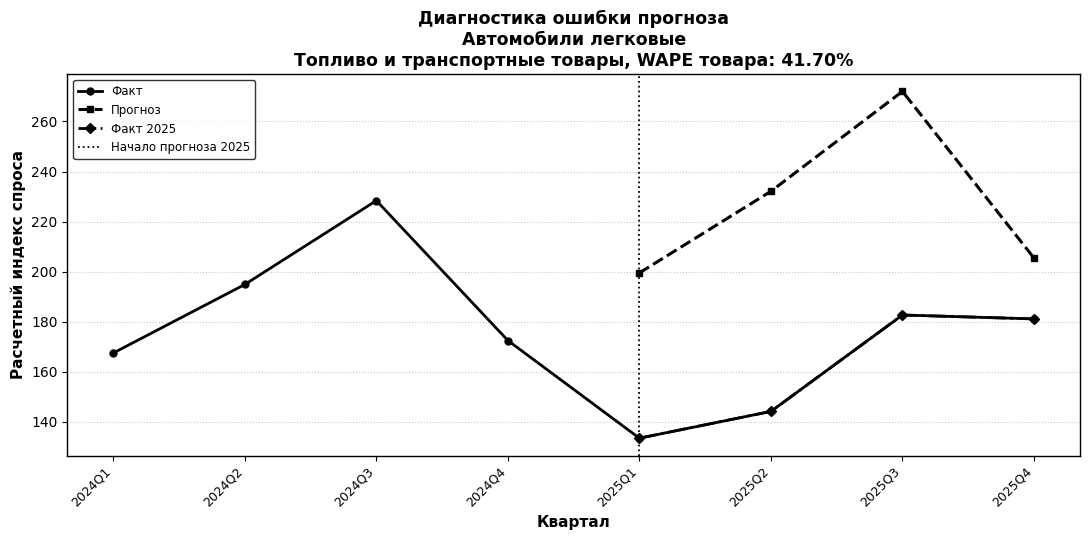

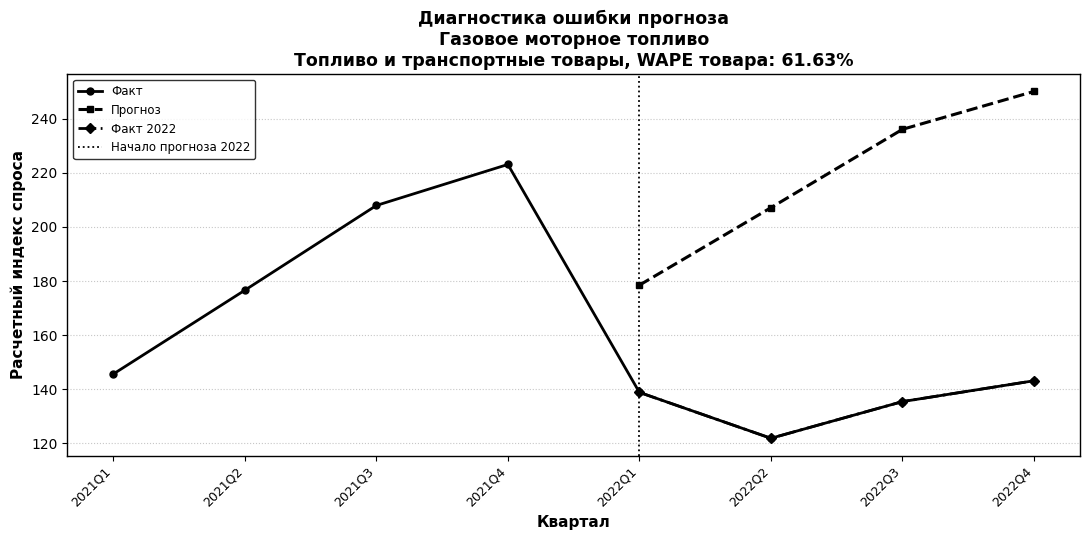

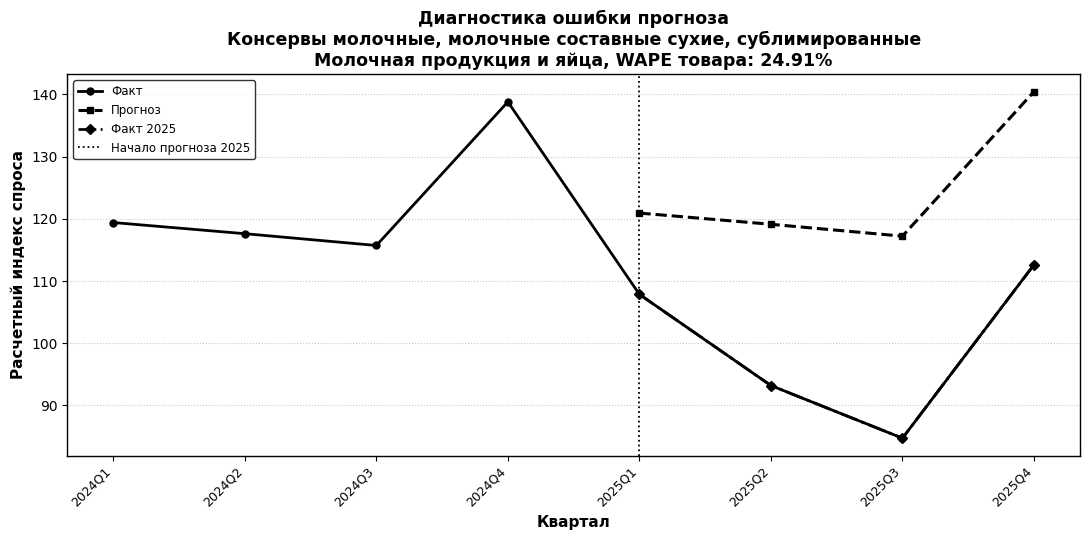

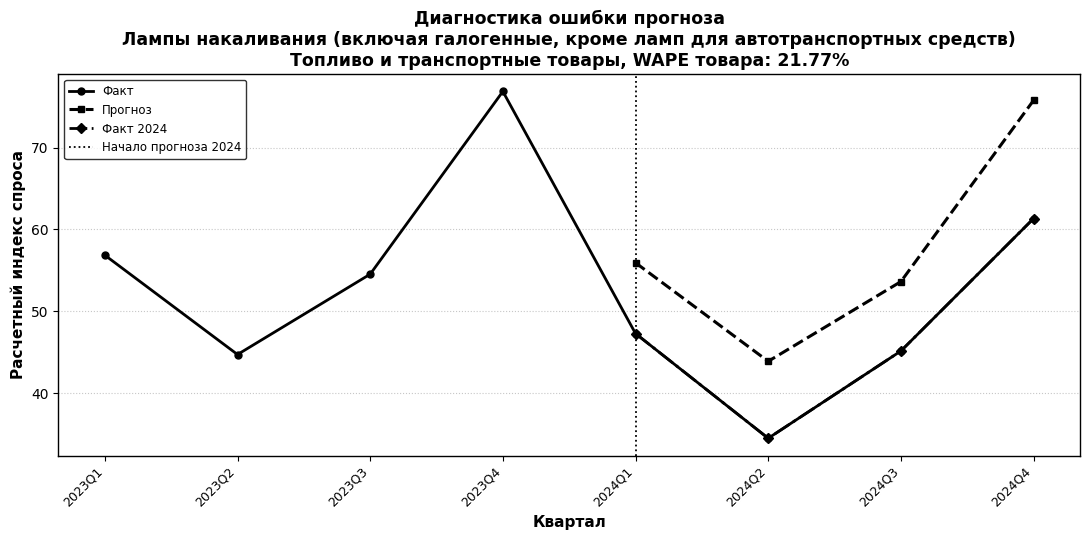

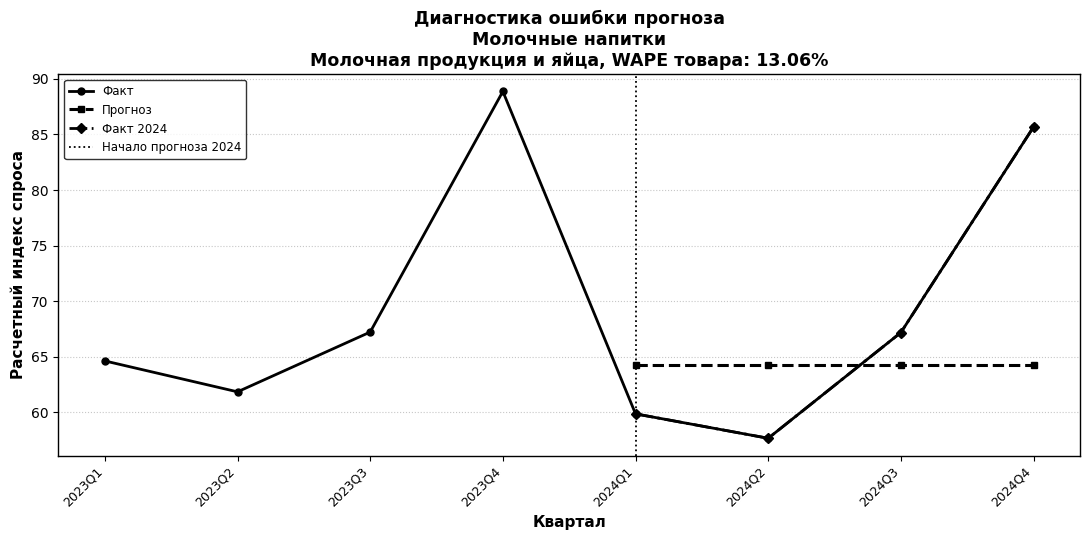

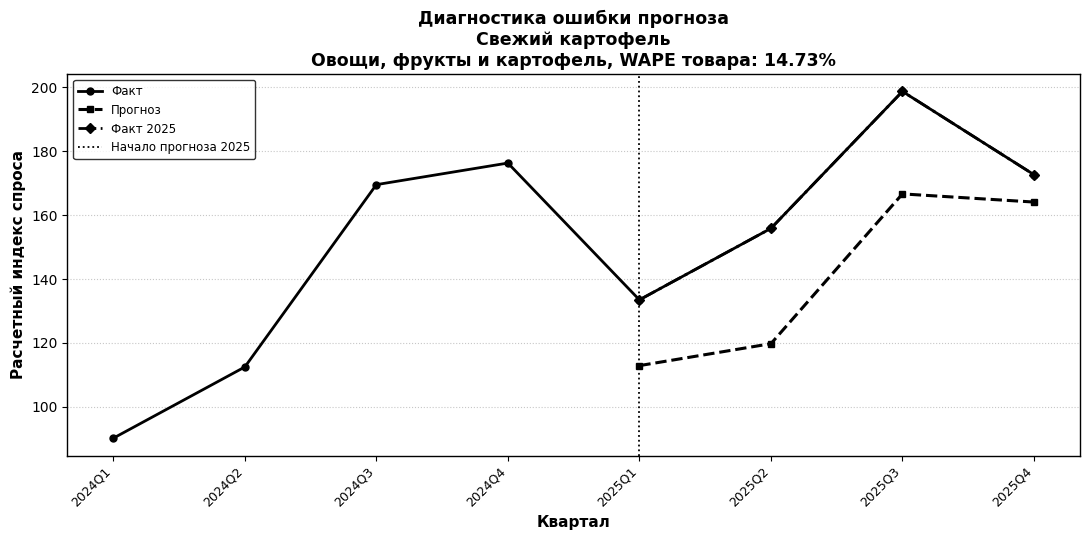

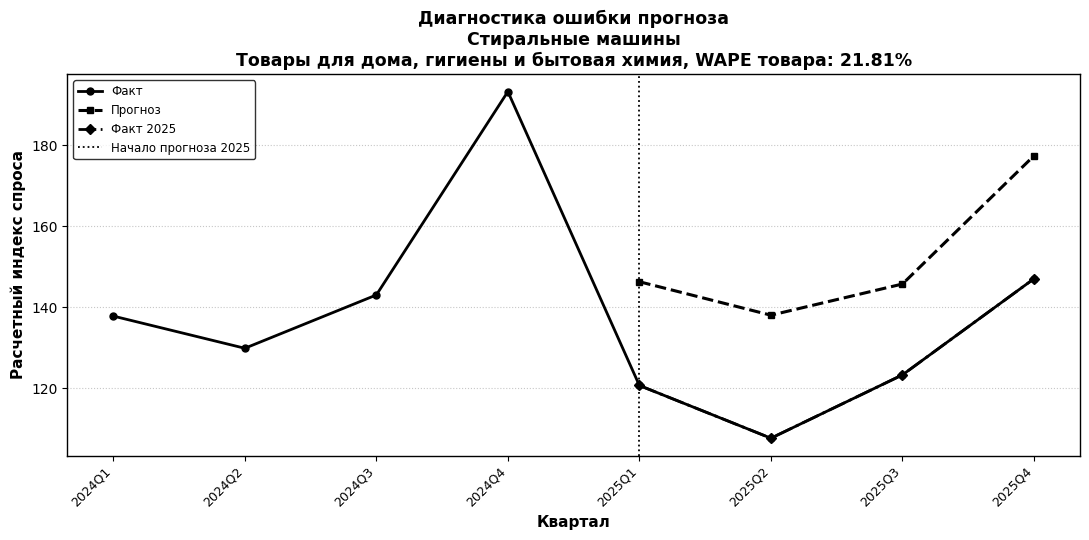

Графики сохранены: /home/senya/projects/diplom/dataset/plots_deep_problem_products


In [30]:
# ============================================================
# Графики проблемных товаров:
# факт, прогноз, предыдущий год, проблемные кварталы
# ============================================================

for product_name in problem_products:

    hist = (
        df[df["product_name"] == product_name]
        .sort_values("period_q")
        .copy()
    )

    fc = (
        forecast[forecast["product_name"] == product_name]
        .sort_values("period_q")
        .copy()
    )

    if hist.empty or fc.empty:
        continue

    forecast_year = int(fc["forecast_year"].iloc[0])
    previous_year = forecast_year - 1

    axis_periods = pd.period_range(
        f"{previous_year}Q1",
        f"{forecast_year}Q4",
        freq="Q"
    ).astype(str)

    x_map = {p: i for i, p in enumerate(axis_periods)}

    hist_plot = hist[hist["period"].isin(axis_periods)].copy()
    hist_plot["x"] = hist_plot["period"].map(x_map)

    fc["x"] = fc["period"].map(x_map)

    metric_row = product_metrics[
        product_metrics["product_name"] == product_name
    ]

    wape = metric_row["WAPE_%"].iloc[0] if not metric_row.empty else np.nan

    group_name = fc["group_name"].dropna().iloc[0] if fc["group_name"].notna().any() else ""

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.plot(
        hist_plot["x"],
        hist_plot["target_demand_index"],
        color="black",
        linestyle="-",
        linewidth=2.0,
        marker="o",
        markersize=5,
        label="Факт"
    )

    ax.plot(
        fc["x"],
        fc["forecast_target_demand_index"],
        color="black",
        linestyle="--",
        linewidth=2.2,
        marker="s",
        markersize=5,
        label="Прогноз"
    )

    ax.plot(
        fc["x"],
        fc["actual_target_demand_index"],
        color="black",
        linestyle="-.",
        linewidth=2.0,
        marker="D",
        markersize=5,
        label=f"Факт {forecast_year}"
    )

    ax.axvline(
        x_map[f"{forecast_year}Q1"],
        color="black",
        linestyle=":",
        linewidth=1.3,
        label=f"Начало прогноза {forecast_year}"
    )

    ax.set_title(
        f"Диагностика ошибки прогноза\n{product_name}\n{group_name}, WAPE товара: {wape:.2f}%",
        fontsize=12.5,
        fontweight="bold"
    )

    ax.set_xlabel("Квартал", fontsize=11, fontweight="bold")
    ax.set_ylabel("Расчетный индекс спроса", fontsize=11, fontweight="bold")

    ax.set_xticks(range(len(axis_periods)))
    ax.set_xticklabels(axis_periods, rotation=45, ha="right", fontsize=9)

    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.legend(fontsize=8.5, frameon=True, edgecolor="black")

    plt.tight_layout()

    out_path = PLOTS_DIR / f"deep_diagnostics_{make_safe_filename(product_name)}.png"

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

print("Графики сохранены:", PLOTS_DIR)

In [31]:
deep_reasons_doc = deep_product[
    [
        "group_name",
        "product_name",
        "forecast_year",
        "test_wape",
        "validation_wape",
        "validation_to_test_gap",
        "actual_change_vs_previous_year_%",
        "forecast_change_vs_previous_year_%",
        "historical_cv_%",
        "test_year_cv_%",
        "diagnostic_reasons",
    ]
].rename(columns={
    "group_name": "Группа товаров",
    "product_name": "Товар",
    "forecast_year": "Проверочный год",
    "test_wape": "WAPE товара, %",
    "validation_wape": "WAPE на валидации, %",
    "validation_to_test_gap": "Разрыв валидация–тест, п.п.",
    "actual_change_vs_previous_year_%": "Факт к прошлому году, %",
    "forecast_change_vs_previous_year_%": "Прогноз к прошлому году, %",
    "historical_cv_%": "Историческая волатильность, %",
    "test_year_cv_%": "Волатильность проверочного года, %",
    "diagnostic_reasons": "Диагностическая причина",
})

print(
    deep_reasons_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Товар	Проверочный год	WAPE товара, %	WAPE на валидации, %	Разрыв валидация–тест, п.п.	Факт к прошлому году, %	Прогноз к прошлому году, %	Историческая волатильность, %	Волатильность проверочного года, %	Диагностическая причина
Топливо и транспортные товары	Газовое моторное топливо	2022	61,63	7,2	54,43	-28,4	15,73	23,65	6,81	плохой перенос с валидации на проверочный год; резкое снижение фактического уровня относительно прошлого года; модель неверно оценила изменение относительно прошлого года; изменение сезонного профиля; систематическое завышение прогноза
Топливо и транспортные товары	Автомобили легковые	2025	41,7	8,07	33,62	-15,95	19,09	22,55	15,74	плохой перенос с валидации на проверочный год; резкое снижение фактического уровня относительно прошлого года; модель неверно оценила изменение относительно прошлого года; изменение сезонного профиля; систематическое завышение прогноза
Молочная продукция и яйца	Консервы молочные, молочные составные сухие, сублимированные	2025	

In [32]:
# ============================================================
# SARIMAX по каждому товару:
# - добавление физического индекса продаж
# - rolling-backtest не только на 2025
# - подбор лучшей конфигурации для каждого товара
# - сводка по категориям и товарам
# - вклад факторов
# ============================================================

from pathlib import Path
import warnings
import itertools
import re

import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings("ignore")


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"
CSV_DIR = DATASET_DIR / "csv"

BASE_DATA_PATH = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"

if not BASE_DATA_PATH.exists():
    BASE_DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

PHYSICAL_PATH = CSV_DIR / "physical_volume_product_quarterly.csv"

OUT_DATA_WITH_PHYSICAL = DATASET_DIR / "demand_training_with_physical_volume.csv"

OUT_CV_FORECASTS = DATASET_DIR / "sarimax_product_best_config_cv_forecasts.csv"
OUT_PRODUCT_CONFIGS = DATASET_DIR / "sarimax_product_best_configs.csv"
OUT_PRODUCT_SUMMARY = DATASET_DIR / "sarimax_product_summary_with_contribution.csv"
OUT_CATEGORY_SUMMARY = DATASET_DIR / "sarimax_category_summary_with_contribution.csv"

OUT_FEATURE_PRODUCT = DATASET_DIR / "sarimax_feature_contribution_by_product_best_configs.csv"
OUT_FEATURE_CATEGORY = DATASET_DIR / "sarimax_feature_contribution_by_category_best_configs.csv"
OUT_FEATURE_TOTAL = DATASET_DIR / "sarimax_feature_contribution_total_best_configs.csv"


# ============================================================
# 2. Настройки
# ============================================================

TARGET_COL = "target_demand_index"

MIN_TRAIN_OBSERVATIONS = 12
MAX_CV_FOLDS = 3

# Горизонт проверки — полный год, 4 квартала.
FORECAST_HORIZON_QUARTERS = 4

# В прогнозном интервале внешние факторы не подставляются фактическими значениями.
# Они заменяются нейтральным значением 0 после стандартизации.
FUTURE_EXOG_MODE = "neutral_zero_after_standardization"

# Если поставить True, физический индекс текущего квартала будет кандидатом.
# Это ближе к ex-post объяснению, но методологически рискованно.
# Лаги physical_index_lag1 и physical_index_lag4 использовать безопаснее.
ALLOW_CURRENT_PHYSICAL_INDEX = True

ORDER_GRID = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

SEASONAL_ORDER_GRID = [
    (0, 0, 0, 4),
    (1, 0, 0, 4),
    (0, 0, 1, 4),
    (1, 0, 1, 4),
]


# ============================================================
# 3. Метрики
# ============================================================

def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def period_end_date(period):
    return period.to_timestamp(how="end").normalize()


def make_safe_filename(value):
    value = str(value)
    value = re.sub(r"[^\wа-яА-ЯёЁ\-]+", "_", value)
    value = value.strip("_")
    return value[:120]


# ============================================================
# 4. Загрузка базового датасета
# ============================================================

df = pd.read_csv(BASE_DATA_PATH)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")

df = df.sort_values(["product_name", "period"]).copy()

print("Базовый датасет:", BASE_DATA_PATH)
print("Строк:", len(df))


# ============================================================
# 5. Добавление физического индекса продаж
# ============================================================

if not PHYSICAL_PATH.exists():
    raise FileNotFoundError(f"Не найден файл: {PHYSICAL_PATH}")

physical = pd.read_csv(PHYSICAL_PATH)

physical = physical.rename(columns={
    "sales_product_name": "product_name",
    "physical_volume_cumulative_yoy_index": "physical_volume_index",
})

physical["period_end"] = pd.to_datetime(physical["period_end"])
physical["period"] = physical["period_end"].dt.to_period("Q")

if "physical_volume_index" not in physical.columns:
    raise ValueError("Не найдена колонка physical_volume_cumulative_yoy_index / physical_volume_index.")

physical_quarterly = (
    physical
    .dropna(subset=["product_name", "period", "physical_volume_index"])
    .groupby(["product_name", "period"], as_index=False)
    .agg(
        physical_volume_index=("physical_volume_index", "mean"),
        physical_rows_count=("physical_volume_index", "count"),
    )
)

df = df.merge(
    physical_quarterly,
    on=["product_name", "period"],
    how="left"
)

# Лаги физического индекса
df = df.sort_values(["product_name", "period"]).copy()

df["physical_volume_index_lag1"] = (
    df.groupby("product_name")["physical_volume_index"]
    .shift(1)
)

df["physical_volume_index_lag4"] = (
    df.groupby("product_name")["physical_volume_index"]
    .shift(4)
)

df["physical_volume_index_qoq"] = (
    df.groupby("product_name")["physical_volume_index"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)

df["physical_volume_index_yoy_diff"] = (
    df["physical_volume_index"]
    - df["physical_volume_index_lag4"]
)

# Групповой и общий физический индекс
group_physical = (
    df
    .groupby(["group_code", "period"], as_index=False)
    .agg(
        group_physical_volume_index_mean=("physical_volume_index", "mean")
    )
)

market_physical = (
    df
    .groupby("period", as_index=False)
    .agg(
        market_physical_volume_index_mean=("physical_volume_index", "mean")
    )
)

df = df.merge(
    group_physical,
    on=["group_code", "period"],
    how="left"
)

df = df.merge(
    market_physical,
    on="period",
    how="left"
)

df["physical_volume_vs_group"] = (
    df["physical_volume_index"]
    - df["group_physical_volume_index_mean"]
)

df["physical_volume_vs_market"] = (
    df["physical_volume_index"]
    - df["market_physical_volume_index_mean"]
)

df.to_csv(
    OUT_DATA_WITH_PHYSICAL,
    index=False,
    encoding="utf-8-sig"
)

print("Датасет с физическим индексом сохранен:", OUT_DATA_WITH_PHYSICAL)


# ============================================================
# 6. Кандидаты признаков
# ============================================================

def existing(cols):
    return [col for col in cols if col in df.columns]


core_features = existing([
    "consumer_price_index",
    "income_index",
    "stock_value_mean_thousand_rub",
    "stock_days_mean",
])

ppi_features = existing([
    "ppi_quarterly_index",
    "ppi_product_index_quarter_mean",
    "ppi_quarterly_index_qoq",
    "ppi_product_index_qoq",
    "group_ppi_quarterly_index_mean",
    "market_ppi_quarterly_index_mean",
])

physical_lag_features = existing([
    "physical_volume_index_lag1",
    "physical_volume_index_lag4",
])

physical_current_features = existing([
    "physical_volume_index",
    "physical_volume_index_qoq",
    "physical_volume_index_yoy_diff",
    "physical_volume_vs_group",
    "physical_volume_vs_market",
])

if not ALLOW_CURRENT_PHYSICAL_INDEX:
    physical_current_features = []

group_market_features = existing([
    "group_physical_volume_index_mean",
    "market_physical_volume_index_mean",
])

feature_sets = {
    "no_exog": [],
    "core": core_features,
    "physical_lags": physical_lag_features,
    "physical_current_and_lags": physical_current_features + physical_lag_features,
    "core_physical_lags": core_features + physical_lag_features,
    "core_physical_current": core_features + physical_current_features + physical_lag_features,
    "ppi_physical": ppi_features + physical_lag_features,
    "core_ppi_physical": core_features + ppi_features + physical_current_features + physical_lag_features,
}

# Убираем пустые дубли
clean_feature_sets = {}

for name, cols in feature_sets.items():
    cols = list(dict.fromkeys(cols))

    if name == "no_exog":
        clean_feature_sets[name] = []
    elif len(cols) > 0:
        clean_feature_sets[name] = cols

feature_sets = clean_feature_sets

print("Наборы признаков:")
for name, cols in feature_sets.items():
    print(name, ":", cols)


# ============================================================
# 7. Вспомогательные функции для exog
# ============================================================

def fill_exog(exog_df):
    exog_df = exog_df.copy()
    exog_df = exog_df.astype(float)
    exog_df = exog_df.replace([np.inf, -np.inf], np.nan)
    exog_df = exog_df.ffill().bfill()
    exog_df = exog_df.fillna(exog_df.median(numeric_only=True))
    exog_df = exog_df.fillna(0)
    return exog_df


def make_neutral_exog(periods, exog_cols):
    return pd.DataFrame(
        0.0,
        index=periods,
        columns=exog_cols
    )


def clean_features_for_train(product_df, train_periods, feature_list, min_coverage=0.50, corr_threshold=0.98):
    if not feature_list:
        return []

    available_features = [col for col in feature_list if col in product_df.columns]

    if not available_features:
        return []

    train_part = product_df.reindex(train_periods)[available_features].copy()

    kept = []

    for col in available_features:
        coverage = train_part[col].notna().mean()
        nunique = train_part[col].nunique(dropna=True)

        if coverage >= min_coverage and nunique > 1:
            kept.append(col)

    if len(kept) <= 1:
        return kept

    corr_data = fill_exog(train_part[kept])
    corr = corr_data.corr().abs()

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    dropped_corr = [
        col for col in upper.columns
        if any(upper[col] > corr_threshold)
    ]

    final_features = [
        col for col in kept
        if col not in dropped_corr
    ]

    return final_features


def prepare_exog(product_df, train_periods, forecast_periods, feature_list):
    selected_features = clean_features_for_train(
        product_df,
        train_periods,
        feature_list
    )

    if not selected_features:
        return None, None, []

    exog_train_raw = product_df.reindex(train_periods)[selected_features]
    exog_train_filled = fill_exog(exog_train_raw)

    scaler = StandardScaler()

    exog_train_scaled = pd.DataFrame(
        scaler.fit_transform(exog_train_filled),
        index=exog_train_filled.index,
        columns=exog_train_filled.columns
    )

    # В прогнозном интервале не используем фактические будущие значения факторов.
    exog_future = make_neutral_exog(
        forecast_periods,
        selected_features
    )

    return exog_train_scaled, exog_future, selected_features


def fit_sarimax(y_train, exog_train, order, seasonal_order):
    model = SARIMAX(
        y_train,
        exog=exog_train if exog_train is not None and len(exog_train.columns) > 0 else None,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    return model.fit(disp=False)


def forecast_sarimax(y_train, exog_train, exog_future, order, seasonal_order):
    fitted = fit_sarimax(
        y_train,
        exog_train,
        order,
        seasonal_order
    )

    result = fitted.get_forecast(
        steps=len(exog_future) if exog_future is not None else FORECAST_HORIZON_QUARTERS,
        exog=exog_future
    )

    pred = np.asarray(result.predicted_mean)

    try:
        ci = np.asarray(result.conf_int())
    except Exception:
        ci = np.full((len(pred), 2), np.nan)

    return pred, ci, fitted


# ============================================================
# 8. Rolling-folds по каждому товару
# ============================================================

def get_full_years(product_df):
    year_counts = (
        product_df[product_df[TARGET_COL].notna()]
        .groupby("year")["quarter"]
        .nunique()
    )

    return sorted(year_counts[year_counts == 4].index.tolist())


def get_cv_years(product_df):
    full_years = get_full_years(product_df)

    eligible_years = []

    for year in full_years:
        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        train_obs = product_df[
            (product_df["period"] <= train_end)
            & (product_df[TARGET_COL].notna())
        ]

        if len(train_obs) >= MIN_TRAIN_OBSERVATIONS:
            eligible_years.append(year)

    return eligible_years[-MAX_CV_FOLDS:]


def evaluate_config_for_product(product_df, feature_list, order, seasonal_order, cv_years):
    product_df = product_df.sort_values("period").set_index("period").copy()

    y_all = product_df[TARGET_COL].astype(float).sort_index()

    all_errors = []
    all_actuals = []

    used_features_union = set()

    for year in cv_years:
        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        forecast_periods = pd.period_range(
            f"{year}Q1",
            f"{year}Q4",
            freq="Q"
        )

        y_train_raw = y_all[y_all.index <= train_end].dropna()

        if len(y_train_raw) < MIN_TRAIN_OBSERVATIONS:
            continue

        y_test = y_all.reindex(forecast_periods)

        if y_test.isna().any():
            continue

        train_periods = pd.period_range(
            y_train_raw.index.min(),
            train_end,
            freq="Q"
        )

        y_train = y_all.reindex(train_periods)

        exog_train, exog_future, used_features = prepare_exog(
            product_df,
            train_periods,
            forecast_periods,
            feature_list
        )

        used_features_union.update(used_features)

        try:
            pred, _, _ = forecast_sarimax(
                y_train,
                exog_train,
                exog_future,
                order,
                seasonal_order
            )

            all_errors.extend(np.abs(y_test.values - pred))
            all_actuals.extend(np.abs(y_test.values))

        except Exception:
            continue

    if len(all_actuals) == 0 or np.sum(all_actuals) == 0:
        return np.nan, []

    wape = np.sum(all_errors) / np.sum(all_actuals) * 100

    return wape, sorted(used_features_union)


# ============================================================
# 9. Подбор лучшей конфигурации для каждого товара
# ============================================================

config_rows = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()
    product_df["year"] = product_df["period"].dt.year
    product_df["quarter"] = product_df["period"].dt.quarter

    cv_years = get_cv_years(product_df)

    if len(cv_years) == 0:
        print(f"Пропуск: {product_name} — нет годов для rolling-backtest")
        continue

    group_code = product_df["group_code"].dropna().iloc[0] if product_df["group_code"].notna().any() else None
    group_name = product_df["group_name"].dropna().iloc[0] if product_df["group_name"].notna().any() else None
    product_code = product_df["product_code"].dropna().iloc[0] if product_df["product_code"].notna().any() else None

    print("=" * 100)
    print("Товар:", product_name)
    print("CV годы:", cv_years)

    product_config_results = []

    for feature_set_name, feature_list in feature_sets.items():

        for order, seasonal_order in itertools.product(ORDER_GRID, SEASONAL_ORDER_GRID):

            wape, used_features = evaluate_config_for_product(
                product_df,
                feature_list,
                order,
                seasonal_order,
                cv_years
            )

            product_config_results.append({
                "product_code": product_code,
                "product_name": product_name,
                "group_code": group_code,
                "group_name": group_name,
                "cv_years": "; ".join(map(str, cv_years)),
                "feature_set": feature_set_name,
                "candidate_features": "; ".join(feature_list),
                "used_features": "; ".join(used_features),
                "order": str(order),
                "seasonal_order": str(seasonal_order),
                "cv_wape": wape,
            })

    product_config_df = (
        pd.DataFrame(product_config_results)
        .dropna(subset=["cv_wape"])
        .sort_values("cv_wape")
    )

    if product_config_df.empty:
        print("Не удалось подобрать конфигурацию:", product_name)
        continue

    best = product_config_df.iloc[0].to_dict()
    best["rank"] = 1

    config_rows.append(best)

    print("Лучшая конфигурация:")
    print("feature_set:", best["feature_set"])
    print("features:", best["used_features"])
    print("order:", best["order"])
    print("seasonal_order:", best["seasonal_order"])
    print("cv_wape:", round(best["cv_wape"], 3))


product_configs = pd.DataFrame(config_rows)

product_configs.to_csv(
    OUT_PRODUCT_CONFIGS,
    index=False,
    encoding="utf-8-sig"
)

display(product_configs)


# ============================================================
# 10. Прогнозы rolling-backtest по лучшей конфигурации
# ============================================================

cv_forecast_rows = []

for _, cfg in product_configs.iterrows():

    product_name = cfg["product_name"]
    product_df = df[df["product_name"] == product_name].sort_values("period").copy()

    product_df["year"] = product_df["period"].dt.year
    product_df["quarter"] = product_df["period"].dt.quarter

    product_indexed = product_df.set_index("period").copy()
    y_all = product_indexed[TARGET_COL].astype(float).sort_index()

    cv_years = [int(x.strip()) for x in str(cfg["cv_years"]).split(";") if str(x).strip()]

    order = eval(cfg["order"])
    seasonal_order = eval(cfg["seasonal_order"])

    feature_set_name = cfg["feature_set"]
    feature_list = feature_sets.get(feature_set_name, [])

    group_code = cfg["group_code"]
    group_name = cfg["group_name"]
    product_code = cfg["product_code"]

    for year in cv_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        forecast_periods = pd.period_range(
            f"{year}Q1",
            f"{year}Q4",
            freq="Q"
        )

        y_train_raw = y_all[y_all.index <= train_end].dropna()
        y_test = y_all.reindex(forecast_periods)

        if len(y_train_raw) < MIN_TRAIN_OBSERVATIONS or y_test.isna().any():
            continue

        train_periods = pd.period_range(
            y_train_raw.index.min(),
            train_end,
            freq="Q"
        )

        y_train = y_all.reindex(train_periods)

        exog_train, exog_future, used_features = prepare_exog(
            product_indexed,
            train_periods,
            forecast_periods,
            feature_list
        )

        try:
            pred, ci, fitted = forecast_sarimax(
                y_train,
                exog_train,
                exog_future,
                order,
                seasonal_order
            )

            for i, period in enumerate(forecast_periods):
                cv_forecast_rows.append({
                    "product_code": product_code,
                    "product_name": product_name,
                    "group_code": group_code,
                    "group_name": group_name,
                    "cv_year": year,
                    "period": str(period),
                    "period_end": period_end_date(period),
                    "train_start": str(y_train_raw.index.min()),
                    "train_end": str(train_end),
                    "actual_target_demand_index": y_test.iloc[i],
                    "forecast_target_demand_index": pred[i],
                    "forecast_lower": ci[i, 0] if ci is not None else np.nan,
                    "forecast_upper": ci[i, 1] if ci is not None else np.nan,
                    "feature_set": feature_set_name,
                    "used_features": "; ".join(used_features),
                    "order": str(order),
                    "seasonal_order": str(seasonal_order),
                    "future_exog_mode": FUTURE_EXOG_MODE,
                })

        except Exception as e:
            print(f"Ошибка CV-прогноза: {product_name}, {year}: {e}")


cv_forecasts = pd.DataFrame(cv_forecast_rows)

cv_forecasts.to_csv(
    OUT_CV_FORECASTS,
    index=False,
    encoding="utf-8-sig"
)

display(cv_forecasts.head())


# ============================================================
# 11. Сводка по товарам
# ============================================================

eval_df = cv_forecasts[
    cv_forecasts["actual_target_demand_index"].notna()
    & cv_forecasts["forecast_target_demand_index"].notna()
].copy()

eval_df["error"] = (
    eval_df["forecast_target_demand_index"]
    - eval_df["actual_target_demand_index"]
)

eval_df["abs_error"] = eval_df["error"].abs()

eval_df["ape_%"] = (
    eval_df["abs_error"]
    / eval_df["actual_target_demand_index"].abs()
    * 100
)

product_summary_rows = []

for (product_code, product_name, group_code, group_name), temp in eval_df.groupby(
    ["product_code", "product_name", "group_code", "group_name"],
    dropna=False
):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    cfg = product_configs[product_configs["product_name"] == product_name].iloc[0]

    product_summary_rows.append({
        "product_code": product_code,
        "product_name": product_name,
        "group_code": group_code,
        "group_name": group_name,
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "observations_count": len(temp),
        "actual_mean": np.mean(y_true),
        "forecast_mean": np.mean(y_pred),
        "mean_error": np.mean(y_pred - y_true),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
        "best_feature_set": cfg["feature_set"],
        "best_used_features": cfg["used_features"],
        "best_order": cfg["order"],
        "best_seasonal_order": cfg["seasonal_order"],
    })

product_summary = (
    pd.DataFrame(product_summary_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)


# ============================================================
# 12. Сводка по категориям
# ============================================================

category_summary_rows = []

for (group_code, group_name), temp in eval_df.groupby(["group_code", "group_name"], dropna=False):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    category_summary_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "actual_mean": np.mean(y_true),
        "forecast_mean": np.mean(y_pred),
        "mean_error": np.mean(y_pred - y_true),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

category_summary = (
    pd.DataFrame(category_summary_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)


# ============================================================
# 13. Вклад факторов по лучшим конфигурациям
# ============================================================

feature_name_map = {
    "consumer_price_index": "Индекс потребительских цен",
    "income_index": "Индекс доходов населения",
    "stock_value_mean_thousand_rub": "Товарные запасы в стоимостном выражении",
    "stock_days_mean": "Товарные запасы в днях",

    "ppi_quarterly_index": "Индекс цен производителей, квартальный",
    "ppi_product_index_quarter_mean": "Индекс цен производителей, уровень",
    "ppi_quarterly_index_qoq": "Прирост индекса цен производителей",
    "ppi_product_index_qoq": "Прирост уровня индекса цен производителей",

    "physical_volume_index": "Индекс физического объема продаж",
    "physical_volume_index_lag1": "Индекс физического объема продаж, лаг 1 квартал",
    "physical_volume_index_lag4": "Индекс физического объема продаж, лаг 4 квартала",
    "physical_volume_index_qoq": "Прирост физического объема продаж",
    "physical_volume_index_yoy_diff": "Отклонение физического индекса от прошлого года",
    "physical_volume_vs_group": "Физический индекс относительно группы",
    "physical_volume_vs_market": "Физический индекс относительно рынка",
}

feature_rows = []

for _, cfg in product_configs.iterrows():

    product_name = cfg["product_name"]
    product_df = df[df["product_name"] == product_name].sort_values("period").copy()
    product_indexed = product_df.set_index("period").copy()

    y_all = product_indexed[TARGET_COL].astype(float).sort_index()
    y_train_raw = y_all.dropna()

    if len(y_train_raw) < MIN_TRAIN_OBSERVATIONS:
        continue

    train_periods = pd.period_range(
        y_train_raw.index.min(),
        y_train_raw.index.max(),
        freq="Q"
    )

    y_train = y_all.reindex(train_periods)

    order = eval(cfg["order"])
    seasonal_order = eval(cfg["seasonal_order"])

    feature_list = feature_sets.get(cfg["feature_set"], [])

    exog_train, _, used_features = prepare_exog(
        product_indexed,
        train_periods,
        train_periods[-FORECAST_HORIZON_QUARTERS:],
        feature_list
    )

    if exog_train is None or not used_features:
        continue

    try:
        fitted = fit_sarimax(
            y_train,
            exog_train,
            order,
            seasonal_order
        )

        params = fitted.params.copy()

        exog_params = {}

        for feature in used_features:
            if feature in params.index:
                exog_params[feature] = params[feature]

        if len(exog_params) == 0:
            continue

        exog_params = pd.Series(exog_params)

        contribution_matrix = exog_train[exog_params.index].mul(
            exog_params,
            axis=1
        )

        total_abs_contribution = contribution_matrix.abs().sum().sum()

        for feature in exog_params.index:

            feature_abs_sum = contribution_matrix[feature].abs().sum()

            feature_rows.append({
                "product_code": cfg["product_code"],
                "product_name": product_name,
                "group_code": cfg["group_code"],
                "group_name": cfg["group_name"],
                "feature": feature,
                "feature_readable": feature_name_map.get(feature, feature),
                "coef": exog_params[feature],
                "mean_abs_contribution": contribution_matrix[feature].abs().mean(),
                "mean_signed_contribution": contribution_matrix[feature].mean(),
                "max_abs_contribution": contribution_matrix[feature].abs().max(),
                "share_of_product_exog_contribution_%": (
                    feature_abs_sum / total_abs_contribution * 100
                    if total_abs_contribution != 0
                    else np.nan
                ),
                "aic": fitted.aic,
                "bic": fitted.bic,
            })

    except Exception as e:
        print(f"Ошибка вклада факторов: {product_name}: {e}")


feature_product = pd.DataFrame(feature_rows)

if not feature_product.empty:

    feature_category = (
        feature_product
        .groupby(["group_code", "group_name", "feature", "feature_readable"], as_index=False)
        .agg(
            products_count=("product_name", "nunique"),
            mean_coef=("coef", "mean"),
            mean_abs_contribution=("mean_abs_contribution", "mean"),
            mean_signed_contribution=("mean_signed_contribution", "mean"),
            max_abs_contribution=("max_abs_contribution", "max"),
            mean_share_of_product_exog_contribution_pct=("share_of_product_exog_contribution_%", "mean"),
        )
    )

    category_total = (
        feature_category
        .groupby(["group_code", "group_name"], as_index=False)["mean_abs_contribution"]
        .sum()
        .rename(columns={"mean_abs_contribution": "category_total_abs_contribution"})
    )

    feature_category = feature_category.merge(
        category_total,
        on=["group_code", "group_name"],
        how="left"
    )

    feature_category["share_within_category_%"] = (
        feature_category["mean_abs_contribution"]
        / feature_category["category_total_abs_contribution"]
        * 100
    )

    feature_category = feature_category.sort_values(
        ["group_code", "mean_abs_contribution"],
        ascending=[True, False]
    )

    feature_total = (
        feature_product
        .groupby(["feature", "feature_readable"], as_index=False)
        .agg(
            products_count=("product_name", "nunique"),
            mean_coef=("coef", "mean"),
            mean_abs_contribution=("mean_abs_contribution", "mean"),
            mean_signed_contribution=("mean_signed_contribution", "mean"),
            max_abs_contribution=("max_abs_contribution", "max"),
        )
    )

    feature_total["share_of_total_contribution_%"] = (
        feature_total["mean_abs_contribution"]
        / feature_total["mean_abs_contribution"].sum()
        * 100
    )

    feature_total = feature_total.sort_values(
        "mean_abs_contribution",
        ascending=False
    )

else:
    feature_category = pd.DataFrame()
    feature_total = pd.DataFrame()


# ============================================================
# 14. Главный фактор для товара и категории
# ============================================================

if not feature_product.empty:

    product_main_feature = (
        feature_product
        .sort_values(["product_name", "mean_abs_contribution"], ascending=[True, False])
        .groupby("product_name")
        .head(1)
        [[
            "product_name",
            "feature_readable",
            "mean_abs_contribution",
            "share_of_product_exog_contribution_%",
        ]]
        .rename(columns={
            "feature_readable": "main_factor",
            "mean_abs_contribution": "main_factor_abs_contribution",
            "share_of_product_exog_contribution_%": "main_factor_share_%",
        })
    )

    category_main_feature = (
        feature_category
        .sort_values(["group_code", "mean_abs_contribution"], ascending=[True, False])
        .groupby(["group_code", "group_name"])
        .head(1)
        [[
            "group_code",
            "group_name",
            "feature_readable",
            "mean_abs_contribution",
            "share_within_category_%",
        ]]
        .rename(columns={
            "feature_readable": "main_factor",
            "mean_abs_contribution": "main_factor_abs_contribution",
            "share_within_category_%": "main_factor_share_%",
        })
    )

    product_summary = product_summary.merge(
        product_main_feature,
        on="product_name",
        how="left"
    )

    category_summary = category_summary.merge(
        category_main_feature,
        on=["group_code", "group_name"],
        how="left"
    )

else:
    product_summary["main_factor"] = np.nan
    product_summary["main_factor_abs_contribution"] = np.nan
    product_summary["main_factor_share_%"] = np.nan

    category_summary["main_factor"] = np.nan
    category_summary["main_factor_abs_contribution"] = np.nan
    category_summary["main_factor_share_%"] = np.nan


# ============================================================
# 15. Округление
# ============================================================

for table in [product_summary, category_summary, feature_product, feature_category, feature_total]:
    if table is not None and not table.empty:
        for col in table.columns:
            if pd.api.types.is_numeric_dtype(table[col]):
                table[col] = table[col].round(2)


# ============================================================
# 16. Сохранение
# ============================================================

product_summary.to_csv(
    OUT_PRODUCT_SUMMARY,
    index=False,
    encoding="utf-8-sig"
)

category_summary.to_csv(
    OUT_CATEGORY_SUMMARY,
    index=False,
    encoding="utf-8-sig"
)

feature_product.to_csv(
    OUT_FEATURE_PRODUCT,
    index=False,
    encoding="utf-8-sig"
)

feature_category.to_csv(
    OUT_FEATURE_CATEGORY,
    index=False,
    encoding="utf-8-sig"
)

feature_total.to_csv(
    OUT_FEATURE_TOTAL,
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:")
print(OUT_DATA_WITH_PHYSICAL)
print(OUT_PRODUCT_CONFIGS)
print(OUT_CV_FORECASTS)
print(OUT_PRODUCT_SUMMARY)
print(OUT_CATEGORY_SUMMARY)
print(OUT_FEATURE_PRODUCT)
print(OUT_FEATURE_CATEGORY)
print(OUT_FEATURE_TOTAL)


# ============================================================
# 17. Вывод результатов
# ============================================================

print("Сводная по категориям:")
display(category_summary)

print("Сводная по товарам:")
display(product_summary)

print("Общий вклад факторов:")
display(feature_total)

print("Вклад факторов по категориям:")
display(feature_category)

print("Вклад факторов по товарам:")
display(feature_product.head(50))

Базовый датасет: /home/senya/projects/diplom/dataset/demand_primary_training_minimal_with_ppi.csv
Строк: 639
Датасет с физическим индексом сохранен: /home/senya/projects/diplom/dataset/demand_training_with_physical_volume.csv
Наборы признаков:
no_exog : []
core : ['consumer_price_index', 'income_index', 'stock_value_mean_thousand_rub', 'stock_days_mean']
physical_lags : ['physical_volume_index_lag1', 'physical_volume_index_lag4']
physical_current_and_lags : ['physical_volume_index', 'physical_volume_index_qoq', 'physical_volume_index_yoy_diff', 'physical_volume_vs_group', 'physical_volume_vs_market', 'physical_volume_index_lag1', 'physical_volume_index_lag4']
core_physical_lags : ['consumer_price_index', 'income_index', 'stock_value_mean_thousand_rub', 'stock_days_mean', 'physical_volume_index_lag1', 'physical_volume_index_lag4']
core_physical_current : ['consumer_price_index', 'income_index', 'stock_value_mean_thousand_rub', 'stock_days_mean', 'physical_volume_index', 'physical_volume

,product_code,product_name,group_code,group_name,cv_years,feature_set,candidate_features,used_features,order,seasonal_order,cv_wape,rank
0,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,physical_volume_index; physical_volume_index_l...,"(2, 1, 1)","(1, 0, 1, 4)",11.498397,1
1,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2020; 2021,no_exog,,,"(2, 1, 1)","(0, 0, 0, 4)",6.614050,1
2,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,2020; 2021; 2022,core_physical_current,consumer_price_index; income_index; stock_valu...,consumer_price_index; income_index; physical_v...,"(1, 1, 0)","(1, 0, 1, 4)",17.547389,1
3,S_дизельное_топливо,Дизельное топливо,G10,Топливо и транспортные товары,2020; 2021; 2022,no_exog,,,"(1, 1, 2)","(1, 0, 1, 4)",5.363317,1
4,S_консервы_молочные_молочные_составные_сухие_с...,"Консервы молочные, молочные составные сухие, с...",G02,Молочная продукция и яйца,2023; 2024; 2025,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,physical_volume_index; physical_volume_index_l...,"(1, 1, 2)","(0, 0, 0, 4)",10.418132,1
5,S_лампы_накаливания_включая_галогенные_кроме_л...,"Лампы накаливания (включая галогенные, кроме л...",G10,Топливо и транспортные товары,2022; 2023; 2024,physical_lags,physical_volume_index_lag1; physical_volume_in...,physical_volume_index_lag1; physical_volume_in...,"(0, 1, 1)","(1, 0, 0, 4)",10.057952,1
6,S_макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,core,consumer_price_index; income_index; stock_valu...,consumer_price_index; income_index; stock_days...,"(1, 1, 0)","(1, 0, 0, 4)",3.566201,1
7,S_маргариновая_продукция,Маргариновая продукция,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,physical_lags,physical_volume_index_lag1; physical_volume_in...,physical_volume_index_lag1; physical_volume_in...,"(1, 1, 2)","(1, 0, 1, 4)",5.632263,1
8,S_молоко_питьевое,Молоко питьевое,G02,Молочная продукция и яйца,2023; 2024; 2025,core,consumer_price_index; income_index; stock_valu...,consumer_price_index; income_index; stock_days...,"(1, 1, 0)","(0, 0, 1, 4)",3.647838,1
9,S_молочные_напитки,Молочные напитки,G02,Молочная продукция и яйца,2022; 2023; 2024,physical_lags,physical_volume_index_lag1; physical_volume_in...,physical_volume_index_lag1; physical_volume_in...,"(0, 1, 1)","(0, 0, 1, 4)",30.024806,1


,product_code,product_name,group_code,group_name,cv_year,period,period_end,train_start,train_end,actual_target_demand_index,forecast_target_demand_index,forecast_lower,forecast_upper,feature_set,used_features,order,seasonal_order,future_exog_mode
0,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q1,2023-03-31,2017Q1,2022Q4,118.327224,159.896707,140.361504,179.431910,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,"(2, 1, 1)","(1, 0, 1, 4)",neutral_zero_after_standardization
1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q2,2023-06-30,2017Q1,2022Q4,153.480192,164.529582,145.105513,183.953651,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,"(2, 1, 1)","(1, 0, 1, 4)",neutral_zero_after_standardization
2,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q3,2023-09-30,2017Q1,2022Q4,187.270948,171.305846,151.521779,191.089914,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,"(2, 1, 1)","(1, 0, 1, 4)",neutral_zero_after_standardization
3,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q4,2023-12-31,2017Q1,2022Q4,166.589977,178.850302,158.815580,198.885024,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,"(2, 1, 1)","(1, 0, 1, 4)",neutral_zero_after_standardization
4,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2024,2024Q1,2024-03-31,2017Q1,2023Q4,167.540049,165.982944,141.067868,190.898021,physical_current_and_lags,physical_volume_index; physical_volume_index_q...,"(2, 1, 1)","(1, 0, 1, 4)",neutral_zero_after_standardization


Сохранено:
/home/senya/projects/diplom/dataset/demand_training_with_physical_volume.csv
/home/senya/projects/diplom/dataset/sarimax_product_best_configs.csv
/home/senya/projects/diplom/dataset/sarimax_product_best_config_cv_forecasts.csv
/home/senya/projects/diplom/dataset/sarimax_product_summary_with_contribution.csv
/home/senya/projects/diplom/dataset/sarimax_category_summary_with_contribution.csv
/home/senya/projects/diplom/dataset/sarimax_feature_contribution_by_product_best_configs.csv
/home/senya/projects/diplom/dataset/sarimax_feature_contribution_by_category_best_configs.csv
/home/senya/projects/diplom/dataset/sarimax_feature_contribution_total_best_configs.csv
Сводная по категориям:


,group_code,group_name,products_count,observations_count,cv_years,actual_mean,forecast_mean,mean_error,MAE,RMSE,MAPE_%,WAPE_%,main_factor,main_factor_abs_contribution,main_factor_share_%
0,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,111.74,111.14,-0.60,2.76,4.24,2.37,2.47,"Индекс физического объема продаж, лаг 1 квартал",1.64,93.82
1,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,91.67,89.67,-2.00,3.71,5.49,3.98,4.05,Прирост физического объема продаж,23.10,29.40
2,G01,"Хлеб, крупы, мука и макаронные изделия",2,24,2023; 2024; 2025,108.74,109.83,1.10,4.57,5.68,4.16,4.20,Индекс потребительских цен,17.48,46.41
3,G04,"Овощи, фрукты и картофель",3,36,2023; 2024; 2025,138.57,138.14,-0.43,10.40,14.47,7.36,7.51,Прирост физического объема продаж,43.37,26.37
4,G02,Молочная продукция и яйца,4,48,2022; 2023; 2024; 2025,109.25,112.71,3.46,11.10,17.61,109.76,10.16,Индекс физического объема продаж,19.93,32.79
5,G10,Топливо и транспортные товары,5,56,2020; 2021; 2022; 2023; 2024; 2025,125.94,123.94,-2.00,13.93,21.01,10.53,11.06,Товарные запасы в стоимостном выражении,55.50,26.92
6,G07,"Товары для дома, гигиены и бытовая химия",1,12,2023; 2024; 2025,139.64,145.55,5.91,18.33,21.90,13.05,13.13,"Индекс физического объема продаж, лаг 1 квартал",5.25,78.61


...

,feature,feature_readable,products_count,mean_coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,share_of_total_contribution_%
10,stock_value_mean_thousand_rub,Товарные запасы в стоимостном выражении,2,38.62,34.56,0.0,100.75,22.86
0,consumer_price_index,Индекс потребительских цен,3,-24.30,21.63,-0.0,102.42,14.31
6,physical_volume_index_yoy_diff,Отклонение физического индекса от прошлого года,5,-0.76,21.50,-0.0,140.49,14.22
5,physical_volume_index_qoq,Прирост физического объема продаж,5,9.64,18.72,0.0,111.07,12.39
2,physical_volume_index,Индекс физического объема продаж,5,2.84,13.09,-0.0,80.61,8.66
1,income_index,Индекс доходов населения,3,4.88,9.88,-0.0,43.08,6.54
3,physical_volume_index_lag1,"Индекс физического объема продаж, лаг 1 квартал",11,2.75,9.70,-0.0,143.85,6.42
9,stock_days_mean,Товарные запасы в днях,3,-8.92,7.28,-0.0,52.78,4.82
4,physical_volume_index_lag4,"Индекс физического объема продаж, лаг 4 квартала",11,0.94,7.12,-0.0,89.60,4.71
8,physical_volume_vs_market,Физический индекс относительно рынка,4,-4.77,4.26,0.0,39.87,2.82


Вклад факторов по категориям:


,group_code,group_name,feature,feature_readable,products_count,mean_coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,mean_share_of_product_exog_contribution_pct,category_total_abs_contribution,share_within_category_%
0,G01,"Хлеб, крупы, мука и макаронные изделия",consumer_price_index,Индекс потребительских цен,1,-19.59,17.48,-0.0,30.73,46.41,37.66,46.41
3,G01,"Хлеб, крупы, мука и макаронные изделия",stock_value_mean_thousand_rub,Товарные запасы в стоимостном выражении,1,15.45,13.62,-0.0,26.03,36.16,37.66,36.16
1,G01,"Хлеб, крупы, мука и макаронные изделия",income_index,Индекс доходов населения,1,-4.96,3.99,-0.0,14.19,10.61,37.66,10.61
2,G01,"Хлеб, крупы, мука и макаронные изделия",stock_days_mean,Товарные запасы в днях,1,-3.13,2.57,0.0,8.03,6.82,37.66,6.82
6,G02,Молочная продукция и яйца,physical_volume_index,Индекс физического объема продаж,1,26.46,19.93,-0.0,80.61,29.64,60.77,32.79
12,G02,Молочная продукция и яйца,physical_volume_vs_market,Физический индекс относительно рынка,1,-12.68,9.65,0.0,39.87,14.35,60.77,15.87
10,G02,Молочная продукция и яйца,physical_volume_index_yoy_diff,Отклонение физического индекса от прошлого года,1,9.92,8.04,0.0,25.46,11.96,60.77,13.23
9,G02,Молочная продукция и яйца,physical_volume_index_qoq,Прирост физического объема продаж,1,-6.56,5.04,-0.0,16.31,7.50,60.77,8.29
7,G02,Молочная продукция и яйца,physical_volume_index_lag1,"Индекс физического объема продаж, лаг 1 квартал",3,-6.51,5.04,-0.0,48.82,40.74,60.77,8.29
8,G02,Молочная продукция и яйца,physical_volume_index_lag4,"Индекс физического объема продаж, лаг 4 квартала",3,3.11,4.58,-0.0,32.46,37.35,60.77,7.53


Вклад факторов по товарам:


,product_code,product_name,group_code,group_name,feature,feature_readable,coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,share_of_product_exog_contribution_%,aic,bic
0,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,physical_volume_index,Индекс физического объема продаж,5.26,4.01,-0.0,12.71,8.09,262.77,279.18
1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,physical_volume_index_qoq,Прирост физического объема продаж,2.39,1.66,0.0,7.03,3.35,262.77,279.18
2,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,physical_volume_index_yoy_diff,Отклонение физического индекса от прошлого года,31.22,23.50,0.0,66.13,47.37,262.77,279.18
3,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,physical_volume_vs_group,Физический индекс относительно группы,2.22,1.65,-0.0,6.16,3.32,262.77,279.18
4,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,physical_volume_index_lag1,"Индекс физического объема продаж, лаг 1 квартал",-1.76,1.33,0.0,4.31,2.68,262.77,279.18
5,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,physical_volume_index_lag4,"Индекс физического объема продаж, лаг 4 квартала",24.53,17.46,-0.0,64.21,35.18,262.77,279.18
6,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,consumer_price_index,Индекс потребительских цен,-52.24,46.49,-0.0,102.42,20.18,176.55,193.58
7,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,income_index,Индекс доходов населения,25.05,21.27,-0.0,43.08,9.23,176.55,193.58
8,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,stock_value_mean_thousand_rub,Товарные запасы в стоимостном выражении,61.79,55.50,0.0,100.75,24.09,176.55,193.58
9,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,stock_days_mean,Товарные запасы в днях,-21.58,17.59,-0.0,52.78,7.64,176.55,193.58


In [33]:
# ============================================================
# Таблица для Google Docs: категории
# ============================================================

category_doc = category_summary[
    [
        "group_name",
        "products_count",
        "observations_count",
        "cv_years",
        "MAE",
        "RMSE",
        "MAPE_%",
        "WAPE_%",
        "main_factor",
        "main_factor_share_%",
    ]
].rename(columns={
    "group_name": "Группа товаров",
    "products_count": "Кол-во товаров",
    "observations_count": "Кол-во наблюдений",
    "cv_years": "Проверочные годы",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "MAPE_%": "MAPE, %",
    "WAPE_%": "WAPE, %",
    "main_factor": "Главный фактор",
    "main_factor_share_%": "Доля главного фактора, %",
})

print(
    category_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Кол-во товаров	Кол-во наблюдений	Проверочные годы	MAE	RMSE	MAPE, %	WAPE, %	Главный фактор	Доля главного фактора, %
Мясо, птица, рыба и колбасные изделия	2	24	2023; 2024; 2025	2,76	4,24	2,37	2,47	Индекс физического объема продаж, лаг 1 квартал	93,82
Бакалея, масло, сахар, чай, соль	2	24	2023; 2024; 2025	3,71	5,49	3,98	4,05	Прирост физического объема продаж	29,4
Хлеб, крупы, мука и макаронные изделия	2	24	2023; 2024; 2025	4,57	5,68	4,16	4,2	Индекс потребительских цен	46,41
Овощи, фрукты и картофель	3	36	2023; 2024; 2025	10,4	14,47	7,36	7,51	Прирост физического объема продаж	26,37
Молочная продукция и яйца	4	48	2022; 2023; 2024; 2025	11,1	17,61	109,76	10,16	Индекс физического объема продаж	32,79
Топливо и транспортные товары	5	56	2020; 2021; 2022; 2023; 2024; 2025	13,93	21,01	10,53	11,06	Товарные запасы в стоимостном выражении	26,92
Товары для дома, гигиены и бытовая химия	1	12	2023; 2024; 2025	18,33	21,9	13,05	13,13	Индекс физического объема продаж, лаг 1 квартал	78,61



In [34]:
# ============================================================
# Таблица для Google Docs: товары
# ============================================================

product_doc = product_summary[
    [
        "group_name",
        "product_name",
        "cv_years",
        "observations_count",
        "WAPE_%",
        "MAPE_%",
        "best_feature_set",
        "best_order",
        "best_seasonal_order",
        "main_factor",
        "main_factor_share_%",
    ]
].rename(columns={
    "group_name": "Группа товаров",
    "product_name": "Товар",
    "cv_years": "Проверочные годы",
    "observations_count": "Кол-во наблюдений",
    "WAPE_%": "WAPE, %",
    "MAPE_%": "MAPE, %",
    "best_feature_set": "Лучший набор признаков",
    "best_order": "SARIMAX order",
    "best_seasonal_order": "SARIMAX seasonal_order",
    "main_factor": "Главный фактор",
    "main_factor_share_%": "Доля главного фактора, %",
})

print(
    product_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Товар	Проверочные годы	Кол-во наблюдений	WAPE, %	MAPE, %	Лучший набор признаков	SARIMAX order	SARIMAX seasonal_order	Главный фактор	Доля главного фактора, %
Мясо, птица, рыба и колбасные изделия	Мясо домашней птицы	2023; 2024; 2025	12	2,45	2,28	physical_lags	(0, 1, 1)	(1, 0, 1, 4)	Индекс физического объема продаж, лаг 1 квартал	93,82
Мясо, птица, рыба и колбасные изделия	Мясо животных	2023; 2024; 2025	12	2,49	2,45	no_exog	(2, 1, 1)	(1, 0, 1, 4)		
Бакалея, масло, сахар, чай, соль	Чай	2023; 2024; 2025	12	2,73	2,7	physical_current_and_lags	(0, 1, 1)	(1, 0, 0, 4)	Индекс физического объема продаж, лаг 1 квартал	24,05
Хлеб, крупы, мука и макаронные изделия	Макаронные изделия	2023; 2024; 2025	12	3,57	3,55	core	(1, 1, 0)	(1, 0, 0, 4)	Индекс потребительских цен	46,41
Молочная продукция и яйца	Молоко питьевое	2023; 2024; 2025	12	3,65	3,69	core	(1, 1, 0)	(0, 0, 1, 4)	Индекс доходов населения	62,76
Овощи, фрукты и картофель	Свежие овощи	2023; 2024; 2025	12	4,28	4,44	no_exog	(1, 1, 0

In [35]:
# ============================================================
# Исключение аномального товара и пересчет итоговых таблиц
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

DATASET_DIR = Path.cwd() / "dataset"

FORECAST_PATH = DATASET_DIR / "sarimax_product_best_config_cv_forecasts.csv"
PRODUCT_SUMMARY_PATH = DATASET_DIR / "sarimax_product_summary_with_contribution.csv"
FEATURE_PRODUCT_PATH = DATASET_DIR / "sarimax_feature_contribution_by_product_best_configs.csv"

OUT_FORECAST_CLEAN = DATASET_DIR / "sarimax_cv_forecasts_clean_no_anomaly.csv"
OUT_PRODUCT_CLEAN = DATASET_DIR / "sarimax_product_summary_clean_no_anomaly.csv"
OUT_CATEGORY_CLEAN = DATASET_DIR / "sarimax_category_summary_clean_no_anomaly.csv"
OUT_FEATURE_PRODUCT_CLEAN = DATASET_DIR / "sarimax_feature_product_clean_no_anomaly.csv"
OUT_FEATURE_CATEGORY_CLEAN = DATASET_DIR / "sarimax_feature_category_clean_no_anomaly.csv"
OUT_FEATURE_TOTAL_CLEAN = DATASET_DIR / "sarimax_feature_total_clean_no_anomaly.csv"

ANOMALY_PRODUCTS = [
    "Молочные напитки"
]


# ============================================================
# Метрики
# ============================================================

def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


# ============================================================
# Загрузка
# ============================================================

forecast = pd.read_csv(FORECAST_PATH)
product_summary = pd.read_csv(PRODUCT_SUMMARY_PATH)

forecast_clean = forecast[
    ~forecast["product_name"].isin(ANOMALY_PRODUCTS)
].copy()

product_summary_clean = product_summary[
    ~product_summary["product_name"].isin(ANOMALY_PRODUCTS)
].copy()


# ============================================================
# Сводная по товарам после исключения
# ============================================================

product_rows = []

eval_df = forecast_clean[
    forecast_clean["actual_target_demand_index"].notna()
    & forecast_clean["forecast_target_demand_index"].notna()
].copy()

for (product_code, product_name, group_code, group_name), temp in eval_df.groupby(
    ["product_code", "product_name", "group_code", "group_name"],
    dropna=False
):
    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    old_row = product_summary_clean[
        product_summary_clean["product_name"] == product_name
    ]

    product_rows.append({
        "product_code": product_code,
        "product_name": product_name,
        "group_code": group_code,
        "group_name": group_name,
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "observations_count": len(temp),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
        "best_feature_set": old_row["best_feature_set"].iloc[0] if not old_row.empty and "best_feature_set" in old_row.columns else None,
        "best_order": old_row["best_order"].iloc[0] if not old_row.empty and "best_order" in old_row.columns else None,
        "best_seasonal_order": old_row["best_seasonal_order"].iloc[0] if not old_row.empty and "best_seasonal_order" in old_row.columns else None,
        "main_factor": old_row["main_factor"].iloc[0] if not old_row.empty and "main_factor" in old_row.columns else None,
        "main_factor_share_%": old_row["main_factor_share_%"].iloc[0] if not old_row.empty and "main_factor_share_%" in old_row.columns else None,
    })

product_summary_clean = (
    pd.DataFrame(product_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)


# ============================================================
# Сводная по категориям после исключения
# ============================================================

category_rows = []

for (group_code, group_name), temp in eval_df.groupby(["group_code", "group_name"], dropna=False):
    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    category_rows.append({
        "group_code": group_code,
        "group_name": group_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

category_summary_clean = (
    pd.DataFrame(category_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)


# ============================================================
# Пересчет вкладов факторов без аномального товара
# ============================================================

if FEATURE_PRODUCT_PATH.exists():
    feature_product = pd.read_csv(FEATURE_PRODUCT_PATH)

    feature_product_clean = feature_product[
        ~feature_product["product_name"].isin(ANOMALY_PRODUCTS)
    ].copy()

    feature_category_clean = (
        feature_product_clean
        .groupby(["group_code", "group_name", "feature", "feature_readable"], as_index=False)
        .agg(
            products_count=("product_name", "nunique"),
            mean_coef=("coef", "mean"),
            mean_abs_contribution=("mean_abs_contribution", "mean"),
            mean_signed_contribution=("mean_signed_contribution", "mean"),
            max_abs_contribution=("max_abs_contribution", "max"),
            mean_share_of_product_exog_contribution_pct=("share_of_product_exog_contribution_%", "mean"),
        )
    )

    category_total = (
        feature_category_clean
        .groupby(["group_code", "group_name"], as_index=False)["mean_abs_contribution"]
        .sum()
        .rename(columns={"mean_abs_contribution": "category_total_abs_contribution"})
    )

    feature_category_clean = feature_category_clean.merge(
        category_total,
        on=["group_code", "group_name"],
        how="left"
    )

    feature_category_clean["share_within_category_%"] = (
        feature_category_clean["mean_abs_contribution"]
        / feature_category_clean["category_total_abs_contribution"]
        * 100
    )

    feature_total_clean = (
        feature_product_clean
        .groupby(["feature", "feature_readable"], as_index=False)
        .agg(
            products_count=("product_name", "nunique"),
            mean_coef=("coef", "mean"),
            mean_abs_contribution=("mean_abs_contribution", "mean"),
            mean_signed_contribution=("mean_signed_contribution", "mean"),
            max_abs_contribution=("max_abs_contribution", "max"),
        )
    )

    feature_total_clean["share_of_total_contribution_%"] = (
        feature_total_clean["mean_abs_contribution"]
        / feature_total_clean["mean_abs_contribution"].sum()
        * 100
    )

    feature_product_clean.to_csv(OUT_FEATURE_PRODUCT_CLEAN, index=False, encoding="utf-8-sig")
    feature_category_clean.to_csv(OUT_FEATURE_CATEGORY_CLEAN, index=False, encoding="utf-8-sig")
    feature_total_clean.to_csv(OUT_FEATURE_TOTAL_CLEAN, index=False, encoding="utf-8-sig")

else:
    feature_product_clean = pd.DataFrame()
    feature_category_clean = pd.DataFrame()
    feature_total_clean = pd.DataFrame()


# ============================================================
# Округление
# ============================================================

for table in [product_summary_clean, category_summary_clean, feature_product_clean, feature_category_clean, feature_total_clean]:
    if table is not None and not table.empty:
        for col in table.columns:
            if pd.api.types.is_numeric_dtype(table[col]):
                table[col] = table[col].round(2)


# ============================================================
# Сохранение
# ============================================================

forecast_clean.to_csv(OUT_FORECAST_CLEAN, index=False, encoding="utf-8-sig")
product_summary_clean.to_csv(OUT_PRODUCT_CLEAN, index=False, encoding="utf-8-sig")
category_summary_clean.to_csv(OUT_CATEGORY_CLEAN, index=False, encoding="utf-8-sig")

print("Сохранено:")
print(OUT_FORECAST_CLEAN)
print(OUT_PRODUCT_CLEAN)
print(OUT_CATEGORY_CLEAN)
print(OUT_FEATURE_PRODUCT_CLEAN)
print(OUT_FEATURE_CATEGORY_CLEAN)
print(OUT_FEATURE_TOTAL_CLEAN)

display(category_summary_clean)
display(product_summary_clean)
display(feature_total_clean)

Сохранено:
/home/senya/projects/diplom/dataset/sarimax_cv_forecasts_clean_no_anomaly.csv
/home/senya/projects/diplom/dataset/sarimax_product_summary_clean_no_anomaly.csv
/home/senya/projects/diplom/dataset/sarimax_category_summary_clean_no_anomaly.csv
/home/senya/projects/diplom/dataset/sarimax_feature_product_clean_no_anomaly.csv
/home/senya/projects/diplom/dataset/sarimax_feature_category_clean_no_anomaly.csv
/home/senya/projects/diplom/dataset/sarimax_feature_total_clean_no_anomaly.csv


,group_code,group_name,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,2.76,4.24,2.37,2.47
1,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,3.71,5.49,3.98,4.05
2,G01,"Хлеб, крупы, мука и макаронные изделия",2,24,2023; 2024; 2025,4.57,5.68,4.16,4.20
3,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,7.93,11.55,6.67,6.46
4,G04,"Овощи, фрукты и картофель",3,36,2023; 2024; 2025,10.40,14.47,7.36,7.51
5,G10,Топливо и транспортные товары,5,56,2020; 2021; 2022; 2023; 2024; 2025,13.93,21.01,10.53,11.06
6,G07,"Товары для дома, гигиены и бытовая химия",1,12,2023; 2024; 2025,18.33,21.90,13.05,13.13


,product_code,product_name,group_code,group_name,cv_years,observations_count,MAE,RMSE,MAPE_%,WAPE_%,best_feature_set,best_order,best_seasonal_order,main_factor,main_factor_share_%
0,S_мясо_домашней_птицы,Мясо домашней птицы,G03,"Мясо, птица, рыба и колбасные изделия",2023; 2024; 2025,12,2.95,4.89,2.28,2.45,physical_lags,"(0, 1, 1)","(1, 0, 1, 4)","Индекс физического объема продаж, лаг 1 квартал",93.82
1,S_мясо_животных,Мясо животных,G03,"Мясо, птица, рыба и колбасные изделия",2023; 2024; 2025,12,2.57,3.46,2.45,2.49,no_exog,"(2, 1, 1)","(1, 0, 1, 4)",NaN,NaN
2,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,2.72,3.75,2.70,2.73,physical_current_and_lags,"(0, 1, 1)","(1, 0, 0, 4)","Индекс физического объема продаж, лаг 1 квартал",24.05
3,S_макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,12,4.09,5.12,3.55,3.57,core,"(1, 1, 0)","(1, 0, 0, 4)",Индекс потребительских цен,46.41
4,S_молоко_питьевое,Молоко питьевое,G02,Молочная продукция и яйца,2023; 2024; 2025,12,4.58,5.96,3.69,3.65,core,"(1, 1, 0)","(0, 0, 1, 4)",Индекс доходов населения,62.76
5,S_свежие_овощи,Свежие овощи,G04,"Овощи, фрукты и картофель",2023; 2024; 2025,12,6.03,8.62,4.44,4.28,no_exog,"(1, 1, 0)","(0, 0, 0, 4)",NaN,NaN
6,S_мука,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,12,5.04,6.19,4.76,4.90,no_exog,"(1, 1, 2)","(1, 0, 1, 4)",NaN,NaN
7,S_дизельное_топливо,Дизельное топливо,G10,Топливо и транспортные товары,2020; 2021; 2022,12,7.10,10.17,5.79,5.36,no_exog,"(1, 1, 2)","(1, 0, 1, 4)",NaN,NaN
8,S_маргариновая_продукция,Маргариновая продукция,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,4.71,6.79,5.26,5.63,physical_lags,"(1, 1, 2)","(1, 0, 1, 4)","Индекс физического объема продаж, лаг 4 квартала",86.81
9,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,7.24,9.49,5.77,5.66,physical_lags,"(1, 1, 0)","(1, 0, 1, 4)","Индекс физического объема продаж, лаг 1 квартал",60.21


,feature,feature_readable,products_count,mean_coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,share_of_total_contribution_%
0,consumer_price_index,Индекс потребительских цен,3,-24.30,21.63,0.0,102.42,14.18
1,income_index,Индекс доходов населения,3,4.88,9.88,0.0,43.08,6.48
2,physical_volume_index,Индекс физического объема продаж,5,2.84,13.09,0.0,80.61,8.58
3,physical_volume_index_lag1,"Индекс физического объема продаж, лаг 1 квартал",10,3.21,10.52,0.0,143.85,6.90
4,physical_volume_index_lag4,"Индекс физического объема продаж, лаг 4 квартала",10,1.27,7.65,0.0,89.60,5.02
5,physical_volume_index_qoq,Прирост физического объема продаж,5,9.64,18.72,0.0,111.07,12.28
6,physical_volume_index_yoy_diff,Отклонение физического индекса от прошлого года,5,-0.77,21.50,0.0,140.49,14.09
7,physical_volume_vs_group,Физический индекс относительно группы,5,-3.22,3.41,0.0,19.39,2.24
8,physical_volume_vs_market,Физический индекс относительно рынка,4,-4.76,4.26,0.0,39.87,2.79
9,stock_days_mean,Товарные запасы в днях,3,-8.92,7.28,0.0,52.78,4.77


In [37]:
# ============================================================
# Таблица волатильности физического объема продаж и цен
# по товарным группам
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH = DATASET_DIR / "demand_training_with_physical_volume.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

OUT_VOLATILITY = DATASET_DIR / "group_price_physical_volume_volatility.csv"

print("Используется файл:", DATA_PATH)


# ============================================================
# 2. Настройки
# ============================================================

EXCLUDE_ANOMALY_PRODUCTS = True

ANOMALY_PRODUCTS = [
    "Молочные напитки"
]

PRICE_COL = "consumer_price_index"
PHYSICAL_COL = "physical_volume_index"

START_PERIOD = "2017Q1"
END_PERIOD = None  # можно указать, например "2025Q4"


# ============================================================
# 3. Загрузка
# ============================================================

df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
    "physical_volume_cumulative_yoy_index": "physical_volume_index",
})

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")

if "group_name" not in df.columns:
    raise ValueError("В датасете нет колонки group_name.")

if PRICE_COL not in df.columns:
    raise ValueError(f"В датасете нет колонки {PRICE_COL}.")

if PHYSICAL_COL not in df.columns:
    raise ValueError(
        f"В датасете нет колонки {PHYSICAL_COL}. "
        "Сначала нужно добавить physical_volume_product_quarterly.csv в основной датасет."
    )


# ============================================================
# 4. Фильтрация периода и аномального товара
# ============================================================

if START_PERIOD is not None:
    df = df[df["period"] >= pd.Period(START_PERIOD, freq="Q")].copy()

if END_PERIOD is not None:
    df = df[df["period"] <= pd.Period(END_PERIOD, freq="Q")].copy()

if EXCLUDE_ANOMALY_PRODUCTS:
    df = df[~df["product_name"].isin(ANOMALY_PRODUCTS)].copy()


# ============================================================
# 5. Агрегация до товарной группы и квартала
# ============================================================
# Сначала усредняем показатели внутри группы за каждый квартал.
# Потом считаем волатильность уже по групповому временному ряду.

group_period = (
    df
    .groupby(["group_code", "group_name", "period"], as_index=False)
    .agg(
        products_count=("product_name", "nunique"),
        physical_volume_index_mean=(PHYSICAL_COL, "mean"),
        consumer_price_index_mean=(PRICE_COL, "mean"),
    )
    .sort_values(["group_code", "period"])
)

group_period["physical_qoq_change_%"] = (
    group_period
    .groupby(["group_code", "group_name"])["physical_volume_index_mean"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)

group_period["price_qoq_change_%"] = (
    group_period
    .groupby(["group_code", "group_name"])["consumer_price_index_mean"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)


# ============================================================
# 6. Функции расчета волатильности
# ============================================================

def coef_variation_percent(x):
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return np.nan

    mean_value = x.mean()

    if mean_value == 0:
        return np.nan

    return x.std(ddof=1) / abs(mean_value) * 100


def period_range_text(x):
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return ""

    return f"{x.min()} — {x.max()}"


# ============================================================
# 7. Сводная таблица по группам
# ============================================================

volatility = (
    group_period
    .groupby(["group_code", "group_name"], as_index=False)
    .agg(
        period_range=("period", period_range_text),
        quarters_count=("period", "nunique"),
        products_count=("products_count", "max"),

        physical_mean=("physical_volume_index_mean", "mean"),
        physical_std=("physical_volume_index_mean", "std"),
        physical_cv_%=("physical_volume_index_mean", coef_variation_percent),
        physical_mean_abs_qoq_change_%=("physical_qoq_change_%", lambda x: x.abs().mean()),
        physical_max_abs_qoq_change_%=("physical_qoq_change_%", lambda x: x.abs().max()),

        price_mean=("consumer_price_index_mean", "mean"),
        price_std=("consumer_price_index_mean", "std"),
        price_cv_%=("consumer_price_index_mean", coef_variation_percent),
        price_mean_abs_qoq_change_%=("price_qoq_change_%", lambda x: x.abs().mean()),
        price_max_abs_qoq_change_%=("price_qoq_change_%", lambda x: x.abs().max()),
    )
)


# ============================================================
# 8. Индекс общей волатильности
# ============================================================
# Чем выше значение, тем более нестабильна группа.
# Здесь простая сумма двух коэффициентов вариации.

volatility["total_volatility_index"] = (
    volatility["physical_cv_%"].fillna(0)
    + volatility["price_cv_%"].fillna(0)
)

volatility = volatility.sort_values(
    "total_volatility_index",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 9. Округление и сохранение
# ============================================================

round_cols = [
    "physical_mean",
    "physical_std",
    "physical_cv_%",
    "physical_mean_abs_qoq_change_%",
    "physical_max_abs_qoq_change_%",
    "price_mean",
    "price_std",
    "price_cv_%",
    "price_mean_abs_qoq_change_%",
    "price_max_abs_qoq_change_%",
    "total_volatility_index",
]

for col in round_cols:
    if col in volatility.columns:
        volatility[col] = volatility[col].round(2)

volatility.to_csv(
    OUT_VOLATILITY,
    index=False,
    encoding="utf-8-sig"
)

display(volatility)

print("Сохранено:", OUT_VOLATILITY)

SyntaxError: positional argument follows keyword argument (3289322031.py, line 165)

Используется файл: /home/senya/projects/diplom/dataset/demand_training_with_physical_volume.csv


,group_code,group_name,period_range,quarters_count,products_count,physical_mean,physical_std,physical_cv_percent,physical_mean_abs_qoq_change_percent,physical_max_abs_qoq_change_percent,price_mean,price_std,price_cv_percent,price_mean_abs_qoq_change_percent,price_max_abs_qoq_change_percent,total_volatility_index
0,G07,"Товары для дома, гигиены и бытовая химия",2017Q1 — 2025Q4,36,1,103.85,11.67,11.24,5.99,35.65,136.91,27.74,20.26,2.00,24.61,31.50
1,G10,Топливо и транспортные товары,2017Q1 — 2025Q4,36,5,99.98,8.68,8.68,4.82,19.89,147.18,32.19,21.87,2.25,7.39,30.56
2,G04,"Овощи, фрукты и картофель",2017Q1 — 2025Q4,36,3,102.17,4.54,4.44,2.66,9.02,121.45,28.27,23.27,15.06,32.91,27.72
3,G05,"Бакалея, масло, сахар, чай, соль",2017Q1 — 2025Q4,36,2,97.28,3.06,3.14,2.13,9.78,131.63,30.04,22.82,2.35,21.05,25.97
4,G01,"Хлеб, крупы, мука и макаронные изделия",2017Q1 — 2025Q4,36,2,100.95,4.20,4.16,2.74,12.27,136.63,25.80,18.89,2.45,11.81,23.05
5,G03,"Мясо, птица, рыба и колбасные изделия",2017Q1 — 2025Q4,36,2,100.22,2.04,2.04,1.48,5.48,132.78,26.94,20.29,1.78,6.21,22.33
6,G02,Молочная продукция и яйца,2017Q1 — 2025Q4,36,3,100.79,3.32,3.29,2.07,8.41,135.01,20.15,14.93,2.20,8.26,18.22


Таблица сохранена: /home/senya/projects/diplom/dataset/group_price_physical_volume_volatility.csv


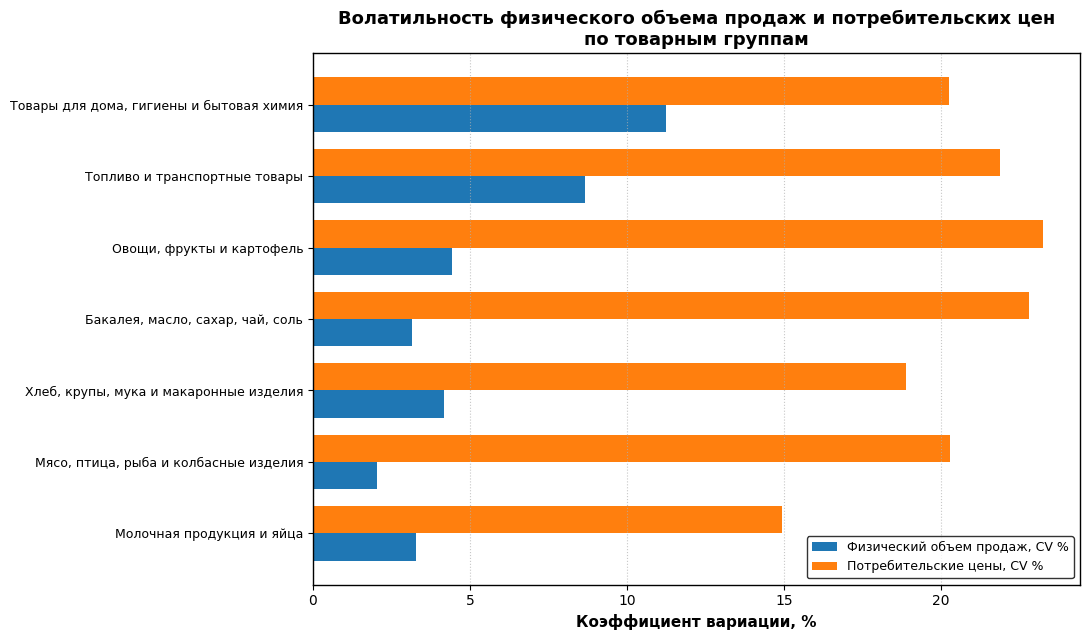

Диаграмма сохранена: /home/senya/projects/diplom/dataset/group_price_physical_volume_volatility_bar.png


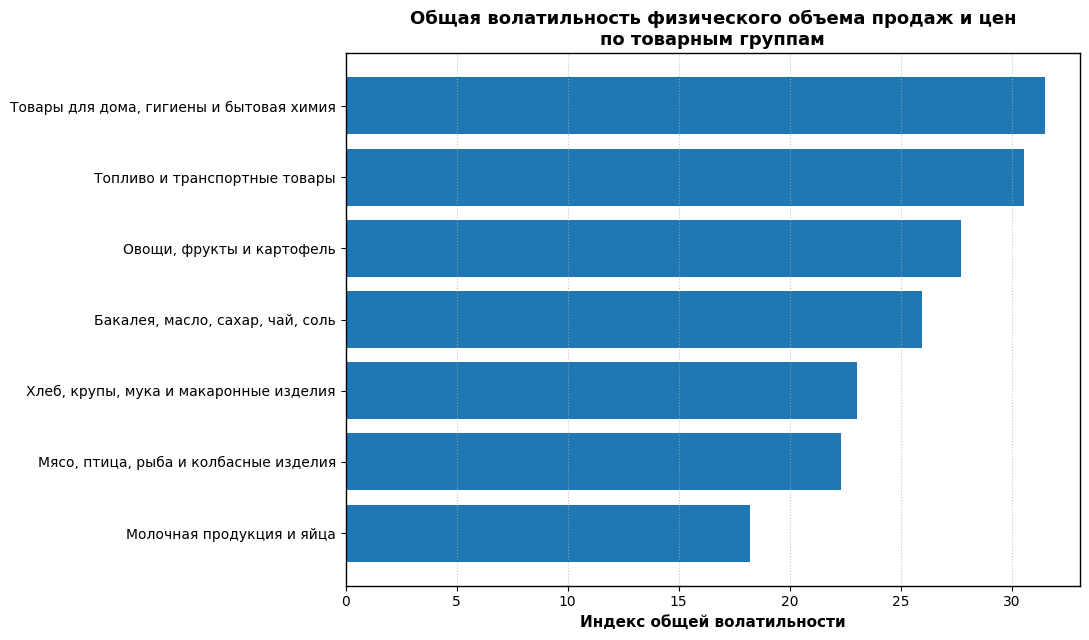

Диаграмма сохранена: /home/senya/projects/diplom/dataset/group_total_volatility_bar.png


In [38]:
# ============================================================
# Волатильность физического объема продаж и цен по товарным группам
# + столбчатая диаграмма
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH = DATASET_DIR / "demand_training_with_physical_volume.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

OUT_VOLATILITY = DATASET_DIR / "group_price_physical_volume_volatility.csv"
OUT_VOLATILITY_PLOT = DATASET_DIR / "group_price_physical_volume_volatility_bar.png"
OUT_TOTAL_VOLATILITY_PLOT = DATASET_DIR / "group_total_volatility_bar.png"

print("Используется файл:", DATA_PATH)


# ============================================================
# 2. Настройки
# ============================================================

EXCLUDE_ANOMALY_PRODUCTS = True

ANOMALY_PRODUCTS = [
    "Молочные напитки"
]

PRICE_COL = "consumer_price_index"
PHYSICAL_COL = "physical_volume_index"

START_PERIOD = "2017Q1"
END_PERIOD = None


# ============================================================
# 3. Загрузка
# ============================================================

df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
    "physical_volume_cumulative_yoy_index": "physical_volume_index",
})

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")

if "group_name" not in df.columns:
    raise ValueError("В датасете нет колонки group_name.")

if "group_code" not in df.columns:
    raise ValueError("В датасете нет колонки group_code.")

if PRICE_COL not in df.columns:
    raise ValueError(f"В датасете нет колонки {PRICE_COL}.")

if PHYSICAL_COL not in df.columns:
    raise ValueError(
        f"В датасете нет колонки {PHYSICAL_COL}. "
        "Сначала нужно добавить physical_volume_product_quarterly.csv в основной датасет."
    )


# ============================================================
# 4. Фильтрация периода и аномального товара
# ============================================================

if START_PERIOD is not None:
    df = df[df["period"] >= pd.Period(START_PERIOD, freq="Q")].copy()

if END_PERIOD is not None:
    df = df[df["period"] <= pd.Period(END_PERIOD, freq="Q")].copy()

if EXCLUDE_ANOMALY_PRODUCTS:
    df = df[~df["product_name"].isin(ANOMALY_PRODUCTS)].copy()


# ============================================================
# 5. Агрегация до группы и квартала
# ============================================================

group_period = (
    df
    .groupby(["group_code", "group_name", "period"], as_index=False)
    .agg(
        products_count=("product_name", "nunique"),
        physical_volume_index_mean=(PHYSICAL_COL, "mean"),
        consumer_price_index_mean=(PRICE_COL, "mean"),
    )
    .sort_values(["group_code", "period"])
)

group_period["physical_qoq_change_percent"] = (
    group_period
    .groupby(["group_code", "group_name"])["physical_volume_index_mean"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)

group_period["price_qoq_change_percent"] = (
    group_period
    .groupby(["group_code", "group_name"])["consumer_price_index_mean"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)


# ============================================================
# 6. Функции
# ============================================================

def coef_variation_percent(x):
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return np.nan

    mean_value = x.mean()

    if mean_value == 0:
        return np.nan

    return x.std(ddof=1) / abs(mean_value) * 100


def period_range_text(x):
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return ""

    return f"{x.min()} — {x.max()}"


# ============================================================
# 7. Сводная таблица волатильности
# ============================================================

volatility = (
    group_period
    .groupby(["group_code", "group_name"], as_index=False)
    .agg(
        period_range=("period", period_range_text),
        quarters_count=("period", "nunique"),
        products_count=("products_count", "max"),

        physical_mean=("physical_volume_index_mean", "mean"),
        physical_std=("physical_volume_index_mean", "std"),
        physical_cv_percent=("physical_volume_index_mean", coef_variation_percent),
        physical_mean_abs_qoq_change_percent=("physical_qoq_change_percent", lambda x: x.abs().mean()),
        physical_max_abs_qoq_change_percent=("physical_qoq_change_percent", lambda x: x.abs().max()),

        price_mean=("consumer_price_index_mean", "mean"),
        price_std=("consumer_price_index_mean", "std"),
        price_cv_percent=("consumer_price_index_mean", coef_variation_percent),
        price_mean_abs_qoq_change_percent=("price_qoq_change_percent", lambda x: x.abs().mean()),
        price_max_abs_qoq_change_percent=("price_qoq_change_percent", lambda x: x.abs().max()),
    )
)

volatility["total_volatility_index"] = (
    volatility["physical_cv_percent"].fillna(0)
    + volatility["price_cv_percent"].fillna(0)
)

volatility = volatility.sort_values(
    "total_volatility_index",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 8. Округление
# ============================================================

round_cols = [
    "physical_mean",
    "physical_std",
    "physical_cv_percent",
    "physical_mean_abs_qoq_change_percent",
    "physical_max_abs_qoq_change_percent",
    "price_mean",
    "price_std",
    "price_cv_percent",
    "price_mean_abs_qoq_change_percent",
    "price_max_abs_qoq_change_percent",
    "total_volatility_index",
]

for col in round_cols:
    volatility[col] = volatility[col].round(2)


# ============================================================
# 9. Сохранение таблицы
# ============================================================

volatility.to_csv(
    OUT_VOLATILITY,
    index=False,
    encoding="utf-8-sig"
)

display(volatility)

print("Таблица сохранена:", OUT_VOLATILITY)


# ============================================================
# 10. Столбчатая диаграмма: физический объем и цены
# ============================================================

plot_df = volatility.sort_values(
    "total_volatility_index",
    ascending=True
).copy()

y = np.arange(len(plot_df))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.barh(
    y - bar_height / 2,
    plot_df["physical_cv_percent"],
    height=bar_height,
    label="Физический объем продаж, CV %"
)

ax.barh(
    y + bar_height / 2,
    plot_df["price_cv_percent"],
    height=bar_height,
    label="Потребительские цены, CV %"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["group_name"], fontsize=9)

ax.set_xlabel("Коэффициент вариации, %", fontsize=11, fontweight="bold")
ax.set_title(
    "Волатильность физического объема продаж и потребительских цен\nпо товарным группам",
    fontsize=13,
    fontweight="bold"
)

ax.grid(True, axis="x", linestyle=":", linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.legend(
    fontsize=9,
    frameon=True,
    edgecolor="black",
    loc="best"
)

plt.tight_layout()

plt.savefig(
    OUT_VOLATILITY_PLOT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Диаграмма сохранена:", OUT_VOLATILITY_PLOT)


# ============================================================
# 11. Дополнительная диаграмма: общий индекс волатильности
# ============================================================

plot_total_df = volatility.sort_values(
    "total_volatility_index",
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.barh(
    plot_total_df["group_name"],
    plot_total_df["total_volatility_index"]
)

ax.set_xlabel("Индекс общей волатильности", fontsize=11, fontweight="bold")
ax.set_title(
    "Общая волатильность физического объема продаж и цен\nпо товарным группам",
    fontsize=13,
    fontweight="bold"
)

ax.grid(True, axis="x", linestyle=":", linewidth=0.8, alpha=0.7)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("black")

plt.tight_layout()

plt.savefig(
    OUT_TOTAL_VOLATILITY_PLOT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Диаграмма сохранена:", OUT_TOTAL_VOLATILITY_PLOT)

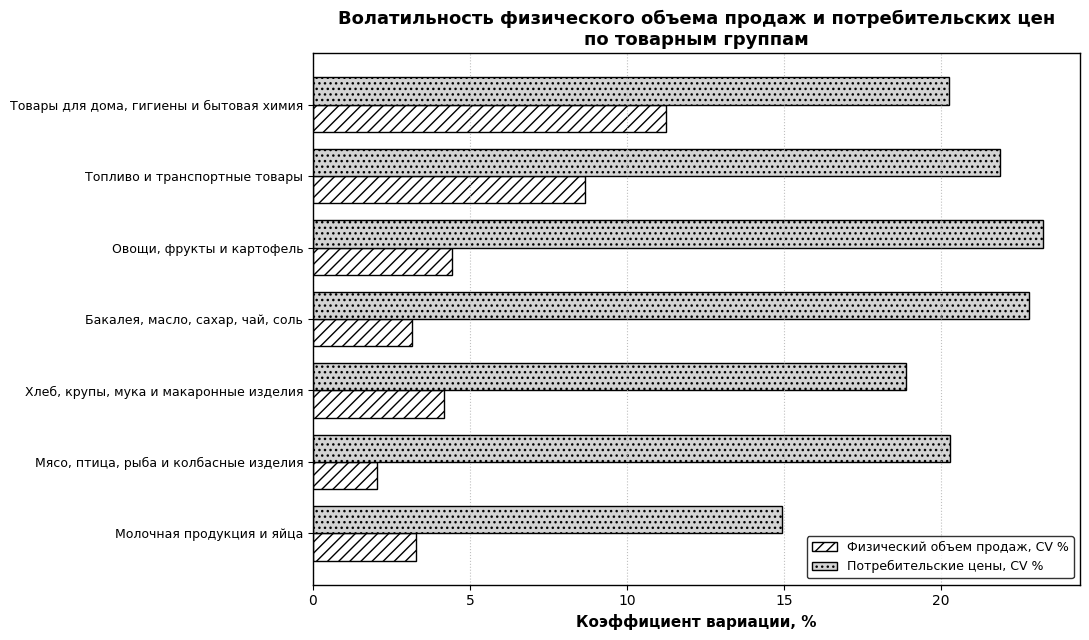

ЧБ-диаграмма сохранена: /home/senya/projects/diplom/dataset/group_price_physical_volume_volatility_bar.png


In [39]:
# ============================================================
# 10. ЧБ-диаграмма: физический объем и цены
# ============================================================

plot_df = volatility.sort_values(
    "total_volatility_index",
    ascending=True
).copy()

y = np.arange(len(plot_df))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(11, 6.5))

# Физический объем продаж
ax.barh(
    y - bar_height / 2,
    plot_df["physical_cv_percent"],
    height=bar_height,
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.0,
    label="Физический объем продаж, CV %"
)

# Потребительские цены
ax.barh(
    y + bar_height / 2,
    plot_df["price_cv_percent"],
    height=bar_height,
    facecolor="lightgray",
    edgecolor="black",
    hatch="...",
    linewidth=1.0,
    label="Потребительские цены, CV %"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["group_name"], fontsize=9)

ax.set_xlabel("Коэффициент вариации, %", fontsize=11, fontweight="bold")
ax.set_title(
    "Волатильность физического объема продаж и потребительских цен\nпо товарным группам",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    True,
    axis="x",
    linestyle=":",
    linewidth=0.8,
    alpha=0.8
)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.legend(
    fontsize=9,
    frameon=True,
    edgecolor="black",
    facecolor="white",
    loc="best"
)

plt.tight_layout()

plt.savefig(
    OUT_VOLATILITY_PLOT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("ЧБ-диаграмма сохранена:", OUT_VOLATILITY_PLOT)

,product_name,model,own_price_elasticity_like_coef,pvalue,r2,nobs,interpretation,giffen_candidate_flag
0,Свежий картофель,dln_demand ~ dln_price + controls + quarter_du...,-0.907447,0.000007,0.909552,35,"отрицательная связь, статистически выражена","нет, признак не подтверждается"


,other_product,dependent_variable,factor,cross_price_coef,pvalue,r2,nobs,corr_potato_demand_other_price,relation,interpretation
0,Мясо домашней птицы,спрос на свежий картофель,цена другого товара,0.944116,0.625735,0.874180,35,0.002540,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
1,Мясо животных,спрос на свежий картофель,цена другого товара,0.944116,0.625735,0.874180,35,0.002540,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
2,Автомобили легковые,спрос на свежий картофель,цена другого товара,0.536682,0.676191,0.873238,35,0.091804,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
3,"Лампы накаливания (включая галогенные, кроме л...",спрос на свежий картофель,цена другого товара,0.333850,0.800513,0.901704,31,0.142199,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
4,Дизельное топливо,спрос на свежий картофель,цена другого товара,0.240481,0.833855,0.911441,24,-0.281461,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
5,Газовое моторное топливо,спрос на свежий картофель,цена другого товара,0.240481,0.833855,0.911441,24,-0.281461,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
6,Бензины автомобильные,спрос на свежий картофель,цена другого товара,0.213464,0.883444,0.931977,20,-0.310149,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
7,Чай,спрос на свежий картофель,цена другого товара,0.044458,0.981501,0.872413,35,0.012900,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
8,Маргариновая продукция,спрос на свежий картофель,цена другого товара,0.044458,0.981501,0.872413,35,0.012900,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
9,Макаронные изделия,спрос на свежий картофель,цена другого товара,-0.018445,0.985460,0.872394,35,-0.048819,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"


,other_product,dependent_variable,factor,cross_price_coef,pvalue,r2,nobs,corr_other_demand_potato_price,relation,interpretation
0,Молочные напитки,спрос другого товара,цена свежего картофеля,1.345928,4.873843e-01,0.336277,31,0.240626,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
1,"Лампы накаливания (включая галогенные, кроме л...",спрос другого товара,цена свежего картофеля,0.095812,6.636804e-01,0.852632,31,-0.718440,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
2,Газовое моторное топливо,спрос другого товара,цена свежего картофеля,0.075986,7.817387e-01,0.709929,24,-0.433644,возможный заменитель картофеля,"положительная связь, статистически неустойчива"
3,Бензины автомобильные,спрос другого товара,цена свежего картофеля,-0.007512,9.664060e-01,0.724470,20,-0.278115,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"
4,Чай,спрос другого товара,цена свежего картофеля,-0.014100,8.772080e-01,0.961810,35,-0.315015,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"
5,"Консервы молочные, молочные составные сухие, с...",спрос другого товара,цена свежего картофеля,-0.030288,9.224390e-01,0.550053,35,-0.626695,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"
6,Мясо домашней птицы,спрос другого товара,цена свежего картофеля,-0.054020,6.670615e-01,0.961404,35,-0.345407,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"
7,Мясо животных,спрос другого товара,цена свежего картофеля,-0.062369,3.081256e-01,0.923124,35,-0.533424,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"
8,Маргариновая продукция,спрос другого товара,цена свежего картофеля,-0.073374,7.897436e-01,0.223599,35,-0.254939,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"
9,Макаронные изделия,спрос другого товара,цена свежего картофеля,-0.096285,4.139763e-01,0.875309,35,0.163130,возможное дополнение / общий спад,"отрицательная связь, статистически неустойчива"


,other_product,cross_price_coef_potato_demand,pvalue_potato_demand,interpretation_potato_demand,cross_price_coef_other_demand,pvalue_other_demand,interpretation_other_demand,pair_relation_class
11,Мясо домашней птицы,0.944116,0.625735,"положительная связь, статистически неустойчива",-0.054020,6.670615e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
12,Мясо животных,0.944116,0.625735,"положительная связь, статистически неустойчива",-0.062369,3.081256e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
0,Автомобили легковые,0.536682,0.676191,"положительная связь, статистически неустойчива",-0.132609,7.697651e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
3,Дизельное топливо,0.240481,0.833855,"положительная связь, статистически неустойчива",-0.251923,2.947979e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
1,Бензины автомобильные,0.213464,0.883444,"положительная связь, статистически неустойчива",-0.007512,9.664060e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
7,Маргариновая продукция,0.044458,0.981501,"положительная связь, статистически неустойчива",-0.073374,7.897436e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
16,Чай,0.044458,0.981501,"положительная связь, статистически неустойчива",-0.014100,8.772080e-01,"отрицательная связь, статистически неустойчива",смешанная или неустойчивая связь
9,Молочные напитки,-0.161392,0.832288,"отрицательная связь, статистически неустойчива",1.345928,4.873843e-01,"положительная связь, статистически неустойчива",смешанная или неустойчивая связь
6,Макаронные изделия,-0.018445,0.985460,"отрицательная связь, статистически неустойчива",-0.096285,4.139763e-01,"отрицательная связь, статистически неустойчива",устойчивые признаки дополнения / общего спада
10,Мука,-0.018445,0.985460,"отрицательная связь, статистически неустойчива",-0.127890,1.825812e-01,"отрицательная связь, статистически неустойчива",устойчивые признаки дополнения / общего спада


,group_name,product_name,quarter,demand_yoy_change_%,price_yoy_change_%,forecast_error,abs_forecast_error
122,"Овощи, фрукты и картофель",Свежий картофель,1,47.992758,24.508784,-14.381424,14.381424
125,"Овощи, фрукты и картофель",Свежий картофель,2,38.552054,32.692301,-40.691655,40.691655
167,Молочная продукция и яйца,сыры,4,18.443665,0.052092,-13.718068,13.718068
128,"Овощи, фрукты и картофель",Свежий картофель,3,17.206380,3.097814,-17.820958,17.820958
56,Молочная продукция и яйца,Молоко питьевое,3,11.860938,6.696733,-5.948525,5.948525
59,Молочная продукция и яйца,Молоко питьевое,4,10.425066,0.052092,1.450523,1.450523
164,Молочная продукция и яйца,сыры,3,9.900008,6.696733,-1.962372,1.962372
107,"Овощи, фрукты и картофель",Свежие овощи,4,8.635403,-6.099465,-12.220638,12.220638
50,Молочная продукция и яйца,Молоко питьевое,1,8.616699,10.106645,2.765889,2.765889
35,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,4,8.423845,4.689542,-5.654760,5.654760


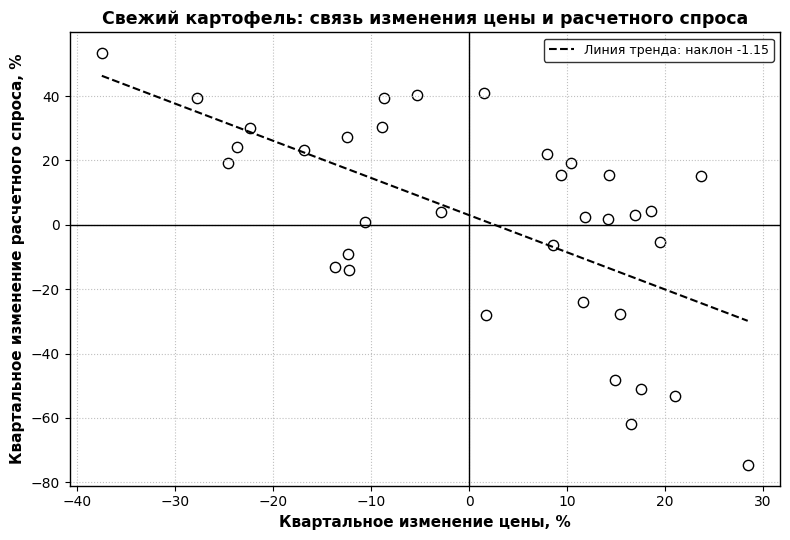

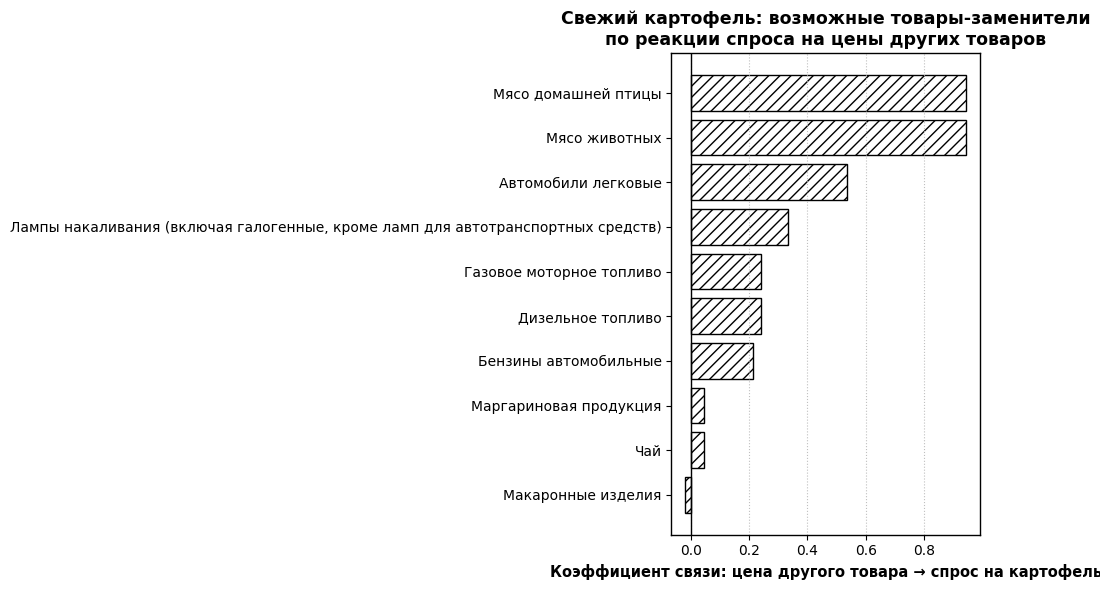

Сохранено:
/home/senya/projects/diplom/dataset/potato_substitution_giffen_diagnostics/potato_own_price_diagnostics.csv
/home/senya/projects/diplom/dataset/potato_substitution_giffen_diagnostics/potato_demand_vs_other_prices.csv
/home/senya/projects/diplom/dataset/potato_substitution_giffen_diagnostics/other_demand_vs_potato_price.csv
/home/senya/projects/diplom/dataset/potato_substitution_giffen_diagnostics/potato_relation_with_other_products.csv
/home/senya/projects/diplom/dataset/potato_substitution_giffen_diagnostics/potato_2025_shift_vs_other_goods.csv
/home/senya/projects/diplom/dataset/potato_substitution_giffen_diagnostics


In [41]:
# ============================================================
# Диагностика свежего картофеля:
# - признаки товара Гиффена
# - признаки товара-заменителя
# - связи с другими товарами
# - объяснение ошибки прогноза по категории
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ============================================================
# 1. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH = DATASET_DIR / "demand_training_with_physical_volume.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

FORECAST_PATH = DATASET_DIR / "sarimax_cv_forecasts_clean_no_anomaly.csv"

OUT_DIR = DATASET_DIR / "potato_substitution_giffen_diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_POTATO_OWN = OUT_DIR / "potato_own_price_diagnostics.csv"
OUT_CROSS_POTATO_DEMAND = OUT_DIR / "potato_demand_vs_other_prices.csv"
OUT_CROSS_OTHER_DEMAND = OUT_DIR / "other_demand_vs_potato_price.csv"
OUT_PRODUCT_RELATION = OUT_DIR / "potato_relation_with_other_products.csv"
OUT_2025_SHIFT = OUT_DIR / "potato_2025_shift_vs_other_goods.csv"

POTATO_NAME = "Свежий картофель"

TARGET_COL = "target_demand_index"
PRICE_COL = "consumer_price_index"
INCOME_COL = "income_index"


# ============================================================
# 2. Загрузка
# ============================================================

df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
    "physical_volume_cumulative_yoy_index": "physical_volume_index",
})

df["period_end"] = pd.to_datetime(df["period_end"])
df["period_q"] = df["period_end"].dt.to_period("Q")
df["period"] = df["period_q"].astype(str)
df["year"] = df["period_q"].dt.year
df["quarter"] = df["period_q"].dt.quarter

df = df.sort_values(["product_name", "period_q"]).copy()

required_cols = ["product_name", "period_q", TARGET_COL, PRICE_COL]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"В датасете нет нужной колонки: {col}")

if POTATO_NAME not in df["product_name"].unique():
    raise ValueError(f"Не найден товар: {POTATO_NAME}")


# ============================================================
# 3. Подготовка лог-изменений
# ============================================================

def safe_log(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.where(x > 0, np.log(x), np.nan)


work = df.copy()

work["ln_demand"] = safe_log(work[TARGET_COL])
work["ln_price"] = safe_log(work[PRICE_COL])

if INCOME_COL in work.columns:
    work["ln_income"] = safe_log(work[INCOME_COL])

if "stock_value_mean_thousand_rub" in work.columns:
    work["ln_stock_value"] = safe_log(work["stock_value_mean_thousand_rub"])

if "stock_days_mean" in work.columns:
    work["ln_stock_days"] = safe_log(work["stock_days_mean"])

# Изменения к предыдущему кварталу
work["dln_demand"] = (
    work.groupby("product_name")["ln_demand"].diff()
)

work["dln_price"] = (
    work.groupby("product_name")["ln_price"].diff()
)

if "ln_income" in work.columns:
    work["dln_income"] = (
        work.groupby("product_name")["ln_income"].diff()
    )

if "ln_stock_value" in work.columns:
    work["dln_stock_value"] = (
        work.groupby("product_name")["ln_stock_value"].diff()
    )

if "ln_stock_days" in work.columns:
    work["dln_stock_days"] = (
        work.groupby("product_name")["ln_stock_days"].diff()
    )

# Изменения к аналогичному кварталу прошлого года
work["dln_demand_yoy"] = (
    work.groupby("product_name")["ln_demand"].diff(4)
)

work["dln_price_yoy"] = (
    work.groupby("product_name")["ln_price"].diff(4)
)

# Проценты для читаемых таблиц
work["demand_qoq_%"] = work["dln_demand"] * 100
work["price_qoq_%"] = work["dln_price"] * 100
work["demand_yoy_%"] = work["dln_demand_yoy"] * 100
work["price_yoy_%"] = work["dln_price_yoy"] * 100


# ============================================================
# 4. Функции регрессий
# ============================================================

def run_ols(data, y_col, x_cols):
    temp = data[[y_col] + x_cols].replace([np.inf, -np.inf], np.nan).dropna()

    if len(temp) < max(10, len(x_cols) + 5):
        return None

    y = temp[y_col]
    X = sm.add_constant(temp[x_cols], has_constant="add")

    try:
        model = sm.OLS(y, X).fit(cov_type="HC3")
        return model
    except Exception:
        return None


def get_coef_result(model, feature):
    if model is None or feature not in model.params.index:
        return {
            "coef": np.nan,
            "pvalue": np.nan,
            "r2": np.nan,
            "nobs": np.nan,
        }

    return {
        "coef": model.params[feature],
        "pvalue": model.pvalues[feature],
        "r2": model.rsquared,
        "nobs": int(model.nobs),
    }


def relation_label(coef, pvalue=None):
    if pd.isna(coef):
        return "недостаточно данных"

    if coef > 0:
        base = "положительная связь"
    elif coef < 0:
        base = "отрицательная связь"
    else:
        base = "связь не выражена"

    if pvalue is not None and pd.notna(pvalue):
        if pvalue < 0.05:
            return base + ", статистически выражена"
        elif pvalue < 0.10:
            return base + ", слабая статистическая выраженность"
        else:
            return base + ", статистически неустойчива"

    return base


# ============================================================
# 5. Собственная цена картофеля:
#    проверка признаков товара Гиффена
# ============================================================

potato = work[work["product_name"] == POTATO_NAME].copy()

own_x_cols = ["dln_price"]

if "dln_income" in potato.columns:
    own_x_cols.append("dln_income")

if "dln_stock_value" in potato.columns:
    own_x_cols.append("dln_stock_value")

if "dln_stock_days" in potato.columns:
    own_x_cols.append("dln_stock_days")

# квартальные фиктивные переменные
potato_reg = potato.copy()
quarter_dummies = pd.get_dummies(
    potato_reg["quarter"].astype(str),
    prefix="q",
    drop_first=True,
    dtype=float
)

potato_reg = pd.concat([potato_reg, quarter_dummies], axis=1)
own_x_cols_with_q = own_x_cols + quarter_dummies.columns.tolist()

own_model = run_ols(
    potato_reg,
    y_col="dln_demand",
    x_cols=own_x_cols_with_q
)

own_res = get_coef_result(own_model, "dln_price")

potato_own_summary = pd.DataFrame([{
    "product_name": POTATO_NAME,
    "model": "dln_demand ~ dln_price + controls + quarter_dummies",
    "own_price_elasticity_like_coef": own_res["coef"],
    "pvalue": own_res["pvalue"],
    "r2": own_res["r2"],
    "nobs": own_res["nobs"],
    "interpretation": relation_label(own_res["coef"], own_res["pvalue"]),
    "giffen_candidate_flag": (
        "да, признак есть"
        if pd.notna(own_res["coef"]) and own_res["coef"] > 0
        else "нет, признак не подтверждается"
    )
}])

potato_own_summary.to_csv(
    OUT_POTATO_OWN,
    index=False,
    encoding="utf-8-sig"
)

display(potato_own_summary)


# ============================================================
# 6. Картофель как товар-заменитель:
#    спрос на картофель vs цены других товаров
# ============================================================
# Если цена другого товара растет, а спрос на картофель растет,
# это признак, что другой товар может быть заменителем картофеля.

potato_demand = (
    work[work["product_name"] == POTATO_NAME]
    [["period_q", "dln_demand", "dln_price", "quarter"]]
    .rename(columns={
        "dln_demand": "potato_dln_demand",
        "dln_price": "potato_dln_price",
    })
)

cross_rows = []

all_products = sorted([
    p for p in work["product_name"].dropna().unique()
    if p != POTATO_NAME
])

for other_product in all_products:

    other = (
        work[work["product_name"] == other_product]
        [["period_q", "product_name", "dln_price", "dln_demand"]]
        .rename(columns={
            "product_name": "other_product",
            "dln_price": "other_dln_price",
            "dln_demand": "other_dln_demand",
        })
    )

    temp = potato_demand.merge(
        other,
        on="period_q",
        how="inner"
    )

    # Регрессия: изменение спроса на картофель ~ изменение цены другого товара + собственная цена картофеля
    x_cols = ["other_dln_price", "potato_dln_price"]

    # квартальные дамми
    temp["quarter"] = temp["period_q"].dt.quarter
    q_dummies = pd.get_dummies(
        temp["quarter"].astype(str),
        prefix="q",
        drop_first=True,
        dtype=float
    )

    temp_reg = pd.concat([temp, q_dummies], axis=1)

    model = run_ols(
        temp_reg,
        y_col="potato_dln_demand",
        x_cols=x_cols + q_dummies.columns.tolist()
    )

    res = get_coef_result(model, "other_dln_price")

    corr = (
        temp[["potato_dln_demand", "other_dln_price"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .corr()
        .iloc[0, 1]
        if len(temp.dropna(subset=["potato_dln_demand", "other_dln_price"])) >= 5
        else np.nan
    )

    if pd.notna(res["coef"]):
        if res["coef"] > 0:
            economic_relation = "возможный заменитель картофеля"
        elif res["coef"] < 0:
            economic_relation = "возможное дополнение / общий спад"
        else:
            economic_relation = "связь не выражена"
    else:
        economic_relation = "недостаточно данных"

    cross_rows.append({
        "other_product": other_product,
        "dependent_variable": "спрос на свежий картофель",
        "factor": "цена другого товара",
        "cross_price_coef": res["coef"],
        "pvalue": res["pvalue"],
        "r2": res["r2"],
        "nobs": res["nobs"],
        "corr_potato_demand_other_price": corr,
        "relation": economic_relation,
        "interpretation": relation_label(res["coef"], res["pvalue"]),
    })

potato_demand_vs_other_prices = (
    pd.DataFrame(cross_rows)
    .sort_values("cross_price_coef", ascending=False)
    .reset_index(drop=True)
)

potato_demand_vs_other_prices.to_csv(
    OUT_CROSS_POTATO_DEMAND,
    index=False,
    encoding="utf-8-sig"
)

display(potato_demand_vs_other_prices.head(20))


# ============================================================
# 7. Обратная связь:
#    спрос других товаров vs цена картофеля
# ============================================================
# Если цена картофеля растет, а спрос на другой товар растет,
# то другой товар может быть заменителем картофеля.

potato_price = (
    work[work["product_name"] == POTATO_NAME]
    [["period_q", "dln_price", "dln_demand"]]
    .rename(columns={
        "dln_price": "potato_dln_price",
        "dln_demand": "potato_dln_demand",
    })
)

reverse_rows = []

for other_product in all_products:

    other = (
        work[work["product_name"] == other_product]
        [["period_q", "product_name", "dln_demand", "dln_price"]]
        .rename(columns={
            "product_name": "other_product",
            "dln_demand": "other_dln_demand",
            "dln_price": "other_dln_price",
        })
    )

    temp = other.merge(
        potato_price,
        on="period_q",
        how="inner"
    )

    x_cols = ["potato_dln_price", "other_dln_price"]

    temp["quarter"] = temp["period_q"].dt.quarter
    q_dummies = pd.get_dummies(
        temp["quarter"].astype(str),
        prefix="q",
        drop_first=True,
        dtype=float
    )

    temp_reg = pd.concat([temp, q_dummies], axis=1)

    model = run_ols(
        temp_reg,
        y_col="other_dln_demand",
        x_cols=x_cols + q_dummies.columns.tolist()
    )

    res = get_coef_result(model, "potato_dln_price")

    corr = (
        temp[["other_dln_demand", "potato_dln_price"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .corr()
        .iloc[0, 1]
        if len(temp.dropna(subset=["other_dln_demand", "potato_dln_price"])) >= 5
        else np.nan
    )

    if pd.notna(res["coef"]):
        if res["coef"] > 0:
            economic_relation = "возможный заменитель картофеля"
        elif res["coef"] < 0:
            economic_relation = "возможное дополнение / общий спад"
        else:
            economic_relation = "связь не выражена"
    else:
        economic_relation = "недостаточно данных"

    reverse_rows.append({
        "other_product": other_product,
        "dependent_variable": "спрос другого товара",
        "factor": "цена свежего картофеля",
        "cross_price_coef": res["coef"],
        "pvalue": res["pvalue"],
        "r2": res["r2"],
        "nobs": res["nobs"],
        "corr_other_demand_potato_price": corr,
        "relation": economic_relation,
        "interpretation": relation_label(res["coef"], res["pvalue"]),
    })

other_demand_vs_potato_price = (
    pd.DataFrame(reverse_rows)
    .sort_values("cross_price_coef", ascending=False)
    .reset_index(drop=True)
)

other_demand_vs_potato_price.to_csv(
    OUT_CROSS_OTHER_DEMAND,
    index=False,
    encoding="utf-8-sig"
)

display(other_demand_vs_potato_price.head(20))


# ============================================================
# 8. Сводная классификация связей с картофелем
# ============================================================

relation_summary = potato_demand_vs_other_prices.merge(
    other_demand_vs_potato_price,
    on="other_product",
    how="outer",
    suffixes=("_potato_demand", "_other_demand")
)

def classify_pair(row):
    a = row.get("cross_price_coef_potato_demand", np.nan)
    b = row.get("cross_price_coef_other_demand", np.nan)

    positive_count = int(pd.notna(a) and a > 0) + int(pd.notna(b) and b > 0)
    negative_count = int(pd.notna(a) and a < 0) + int(pd.notna(b) and b < 0)

    if positive_count == 2:
        return "устойчивые признаки замещения"
    elif positive_count == 1 and negative_count == 0:
        return "слабые признаки замещения"
    elif negative_count == 2:
        return "устойчивые признаки дополнения / общего спада"
    elif negative_count == 1 and positive_count == 0:
        return "слабые признаки дополнения / общего спада"
    else:
        return "смешанная или неустойчивая связь"

relation_summary["pair_relation_class"] = relation_summary.apply(
    classify_pair,
    axis=1
)

relation_summary = relation_summary[
    [
        "other_product",

        "cross_price_coef_potato_demand",
        "pvalue_potato_demand",
        "interpretation_potato_demand",

        "cross_price_coef_other_demand",
        "pvalue_other_demand",
        "interpretation_other_demand",

        "pair_relation_class",
    ]
].sort_values(
    ["pair_relation_class", "cross_price_coef_potato_demand"],
    ascending=[True, False]
)

relation_summary.to_csv(
    OUT_PRODUCT_RELATION,
    index=False,
    encoding="utf-8-sig"
)

display(relation_summary.head(30))


# ============================================================
# 9. Отдельно исследуем 2025 год:
#    почему была высокая ошибка по свежему картофелю
# ============================================================

shift_2025 = work[
    work["year"].isin([2024, 2025])
].copy()

# Таблица 2025 к 2024 по каждому товару и кварталу
base_2024 = shift_2025[shift_2025["year"] == 2024][
    ["product_name", "quarter", TARGET_COL, PRICE_COL]
].rename(columns={
    TARGET_COL: "demand_2024",
    PRICE_COL: "price_2024",
})

test_2025 = shift_2025[shift_2025["year"] == 2025][
    ["product_name", "group_code", "group_name", "quarter", TARGET_COL, PRICE_COL]
].rename(columns={
    TARGET_COL: "demand_2025",
    PRICE_COL: "price_2025",
})

shift = test_2025.merge(
    base_2024,
    on=["product_name", "quarter"],
    how="left"
)

shift["demand_yoy_change_%"] = (
    (shift["demand_2025"] - shift["demand_2024"])
    / shift["demand_2024"].abs()
    * 100
)

shift["price_yoy_change_%"] = (
    (shift["price_2025"] - shift["price_2024"])
    / shift["price_2024"].abs()
    * 100
)

# Добавим ошибку прогноза, если файл прогноза есть
if FORECAST_PATH.exists():
    fc = pd.read_csv(FORECAST_PATH)
    fc["period_end"] = pd.to_datetime(fc["period_end"])
    fc["period_q"] = fc["period_end"].dt.to_period("Q")
    fc["year"] = fc["period_q"].dt.year
    fc["quarter"] = fc["period_q"].dt.quarter

    fc_small = fc[
        ["product_name", "year", "quarter", "actual_target_demand_index", "forecast_target_demand_index"]
    ].copy()

    fc_small["forecast_error"] = (
        fc_small["forecast_target_demand_index"]
        - fc_small["actual_target_demand_index"]
    )

    fc_small["abs_forecast_error"] = fc_small["forecast_error"].abs()

    shift = shift.merge(
        fc_small,
        left_on=["product_name", "quarter"],
        right_on=["product_name", "quarter"],
        how="left"
    )

shift_2025_summary = shift[
    shift["year"] == 2025
].copy() if "year" in shift.columns else shift.copy()

# Если после merge возник year_x/year_y
year_cols = [col for col in shift_2025_summary.columns if col.startswith("year")]
if len(year_cols) > 0:
    shift_2025_summary = shift_2025_summary.drop(columns=year_cols, errors="ignore")

shift_2025_summary = shift_2025_summary.sort_values(
    "demand_yoy_change_%",
    ascending=False
)

shift_2025_summary.to_csv(
    OUT_2025_SHIFT,
    index=False,
    encoding="utf-8-sig"
)

display(
    shift_2025_summary[
        [
            "group_name",
            "product_name",
            "quarter",
            "demand_yoy_change_%",
            "price_yoy_change_%",
        ] + (
            ["forecast_error", "abs_forecast_error"]
            if "forecast_error" in shift_2025_summary.columns
            else []
        )
    ].head(50)
)


# ============================================================
# 10. ЧБ-графики
# ============================================================

# 10.1. Свежий картофель: изменение цены и спроса
potato_plot = potato.dropna(subset=["demand_qoq_%", "price_qoq_%"]).copy()

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(
    potato_plot["price_qoq_%"],
    potato_plot["demand_qoq_%"],
    facecolor="white",
    edgecolor="black",
    s=55,
    linewidth=1.0
)

# линия регрессии
if len(potato_plot) >= 5:
    x = potato_plot["price_qoq_%"].values
    y = potato_plot["demand_qoq_%"].values

    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_line = coef[0] * x_line + coef[1]

    ax.plot(
        x_line,
        y_line,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Линия тренда: наклон {coef[0]:.2f}"
    )

ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(0, color="black", linewidth=1.0)

ax.set_title(
    "Свежий картофель: связь изменения цены и расчетного спроса",
    fontsize=12.5,
    fontweight="bold"
)
ax.set_xlabel("Квартальное изменение цены, %", fontsize=11, fontweight="bold")
ax.set_ylabel("Квартальное изменение расчетного спроса, %", fontsize=11, fontweight="bold")

ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=9)

plt.tight_layout()
plt.savefig(
    OUT_DIR / "potato_price_demand_scatter_bw.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


# 10.2. Топ товаров-заменителей по связи цены другого товара со спросом картофеля
top_cross = potato_demand_vs_other_prices.dropna(
    subset=["cross_price_coef"]
).head(10).sort_values("cross_price_coef")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_cross["other_product"],
    top_cross["cross_price_coef"],
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.0
)

ax.axvline(0, color="black", linewidth=1.0)

ax.set_title(
    "Свежий картофель: возможные товары-заменители\nпо реакции спроса на цены других товаров",
    fontsize=12.5,
    fontweight="bold"
)
ax.set_xlabel("Коэффициент связи: цена другого товара → спрос на картофель", fontsize=10.5, fontweight="bold")

ax.grid(True, axis="x", linestyle=":", linewidth=0.8, alpha=0.8)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig(
    OUT_DIR / "potato_possible_substitutes_bw.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


print("Сохранено:")
print(OUT_POTATO_OWN)
print(OUT_CROSS_POTATO_DEMAND)
print(OUT_CROSS_OTHER_DEMAND)
print(OUT_PRODUCT_RELATION)
print(OUT_2025_SHIFT)
print(OUT_DIR)

In [42]:
# ============================================================
# Таблица 1. Проверка признаков товара Гиффена
# ============================================================

giffen_doc = potato_own_summary[
    [
        "product_name",
        "own_price_elasticity_like_coef",
        "pvalue",
        "r2",
        "nobs",
        "interpretation",
        "giffen_candidate_flag",
    ]
].rename(columns={
    "product_name": "Товар",
    "own_price_elasticity_like_coef": "Коэффициент связи цены и спроса",
    "pvalue": "p-value",
    "r2": "R²",
    "nobs": "Кол-во наблюдений",
    "interpretation": "Интерпретация",
    "giffen_candidate_flag": "Признак товара Гиффена",
})

for col in ["Коэффициент связи цены и спроса", "p-value", "R²"]:
    giffen_doc[col] = giffen_doc[col].round(4)

print(
    giffen_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Товар	Коэффициент связи цены и спроса	p-value	R²	Кол-во наблюдений	Интерпретация	Признак товара Гиффена
Свежий картофель	-0,9074	0,0	0,9096	35	отрицательная связь, статистически выражена	нет, признак не подтверждается



In [43]:
# ============================================================
# Таблица 2. Возможные заменители картофеля
# ============================================================

substitutes_doc = potato_demand_vs_other_prices[
    [
        "other_product",
        "cross_price_coef",
        "pvalue",
        "nobs",
        "relation",
        "interpretation",
    ]
].head(15).rename(columns={
    "other_product": "Другой товар",
    "cross_price_coef": "Связь: цена другого товара → спрос на картофель",
    "pvalue": "p-value",
    "nobs": "Кол-во наблюдений",
    "relation": "Экономическая интерпретация",
    "interpretation": "Статистическая интерпретация",
})

for col in ["Связь: цена другого товара → спрос на картофель", "p-value"]:
    substitutes_doc[col] = substitutes_doc[col].round(4)

print(
    substitutes_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Другой товар	Связь: цена другого товара → спрос на картофель	p-value	Кол-во наблюдений	Экономическая интерпретация	Статистическая интерпретация
Мясо домашней птицы	0,9441	0,6257	35	возможный заменитель картофеля	положительная связь, статистически неустойчива
Мясо животных	0,9441	0,6257	35	возможный заменитель картофеля	положительная связь, статистически неустойчива
Автомобили легковые	0,5367	0,6762	35	возможный заменитель картофеля	положительная связь, статистически неустойчива
Лампы накаливания (включая галогенные, кроме ламп для автотранспортных средств)	0,3338	0,8005	31	возможный заменитель картофеля	положительная связь, статистически неустойчива
Дизельное топливо	0,2405	0,8339	24	возможный заменитель картофеля	положительная связь, статистически неустойчива
Газовое моторное топливо	0,2405	0,8339	24	возможный заменитель картофеля	положительная связь, статистически неустойчива
Бензины автомобильные	0,2135	0,8834	20	возможный заменитель картофеля	положительная связь, статистически неус

In [44]:
# ============================================================
# Таблица 3. 2025 год: изменение спроса и цен относительно 2024
# ============================================================

shift_doc_cols = [
    "group_name",
    "product_name",
    "quarter",
    "demand_yoy_change_%",
    "price_yoy_change_%",
]

if "forecast_error" in shift_2025_summary.columns:
    shift_doc_cols += ["forecast_error", "abs_forecast_error"]

shift_doc = shift_2025_summary[shift_doc_cols].rename(columns={
    "group_name": "Группа товаров",
    "product_name": "Товар",
    "quarter": "Квартал",
    "demand_yoy_change_%": "Изменение спроса к 2024, %",
    "price_yoy_change_%": "Изменение цены к 2024, %",
    "forecast_error": "Ошибка прогноза",
    "abs_forecast_error": "Абс. ошибка прогноза",
})

for col in shift_doc.columns:
    if pd.api.types.is_numeric_dtype(shift_doc[col]):
        shift_doc[col] = shift_doc[col].round(2)

print(
    shift_doc.to_csv(
        sep="\t",
        index=False,
        decimal=","
    )
)

Группа товаров	Товар	Квартал	Изменение спроса к 2024, %	Изменение цены к 2024, %	Ошибка прогноза	Абс. ошибка прогноза
Овощи, фрукты и картофель	Свежий картофель	1	47,99	24,51	-14,38	14,38
Овощи, фрукты и картофель	Свежий картофель	2	38,55	32,69	-40,69	40,69
Молочная продукция и яйца	сыры	4	18,44	0,05	-13,72	13,72
Овощи, фрукты и картофель	Свежий картофель	3	17,21	3,1	-17,82	17,82
Молочная продукция и яйца	Молоко питьевое	3	11,86	6,7	-5,95	5,95
Молочная продукция и яйца	Молоко питьевое	4	10,43	0,05	1,45	1,45
Молочная продукция и яйца	сыры	3	9,9	6,7	-1,96	1,96
Овощи, фрукты и картофель	Свежие овощи	4	8,64	-6,1	-12,22	12,22
Молочная продукция и яйца	Молоко питьевое	1	8,62	10,11	2,77	2,77
Хлеб, крупы, мука и макаронные изделия	Макаронные изделия	4	8,42	4,69	-5,65	5,65
Молочная продукция и яйца	сыры	2	8,03	8,96	10,14	10,14
Молочная продукция и яйца	Молоко питьевое	2	7,12	8,96	3,97	3,97
Топливо и транспортные товары	Автомобили легковые	4	5,0	9,44	-33,94	33,94
Молочная продукция и яйца	сыры	1